In [16]:
# CELL 1 — IIRS ↔ TMC-2 CORRESPONDENCE MODEL
# Environment, paths, and configuration

from pathlib import Path
import os
import re
import json
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy.spatial import cKDTree


# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(r"D:\ISRO")

IIRS_DIR = PROJECT_ROOT / "IIRS_tiles"
TMC2_DIR = PROJECT_ROOT / "TMC_tiles"

OUT_ROOT = PROJECT_ROOT / "IIRS_TMC2_correspondence"

PAIRS_DIR = OUT_ROOT / "pairs"
MODELS_DIR = OUT_ROOT / "models"
EVAL_DIR = OUT_ROOT / "evaluation"
PREDICTIONS_DIR = OUT_ROOT / "predictions"

for directory in [
    OUT_ROOT,
    PAIRS_DIR,
    MODELS_DIR,
    EVAL_DIR,
    PREDICTIONS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ============================================================
# CORRESPONDENCE REPRESENTATION
# ============================================================

# Both finalized encoders use a 256-D embedding as the
# downstream matching representation.

EMBED_DIM = 256


# ============================================================
# SPATIAL CANDIDATE PAIRING
# ============================================================

# Distance is used to generate candidate correspondences.
# It is NOT treated as perfect ground truth.

MAX_PAIR_DISTANCE_M = 300.0

TOP_K_CANDIDATES = 5


# ============================================================
# MAPPER TRAINING
# ============================================================

BATCH_SIZE = 32

LEARNING_RATE = 1e-4

EPOCHS = 50

WEIGHT_DECAY = 1e-5

TEMPERATURE = 0.07


# ============================================================
# EVALUATION
# ============================================================

EVAL_TOP_K = [1, 5, 10]


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 80)
print("IIRS ↔ TMC-2 CORRESPONDENCE MODEL")
print("=" * 80)

print(f"Project root       : {PROJECT_ROOT}")
print(f"IIRS finalized dir : {IIRS_DIR}")
print(f"TMC-2 finalized dir: {TMC2_DIR}")
print(f"Output directory   : {OUT_ROOT}")

print(f"\nEmbedding dimension: {EMBED_DIM}")
print(f"Max pair distance  : {MAX_PAIR_DISTANCE_M} m")
print(f"Candidate top-k    : {TOP_K_CANDIDATES}")

print(f"\nBatch size         : {BATCH_SIZE}")
print(f"Learning rate      : {LEARNING_RATE}")
print(f"Epochs             : {EPOCHS}")
print(f"Weight decay       : {WEIGHT_DECAY}")
print(f"Temperature        : {TEMPERATURE}")

print(f"\nDevice             : {DEVICE}")
print(f"Random seed        : {SEED}")

print("\n[OK] IIRS ↔ TMC-2 correspondence environment ready.")

IIRS ↔ TMC-2 CORRESPONDENCE MODEL
Project root       : D:\ISRO
IIRS finalized dir : D:\ISRO\IIRS_tiles
TMC-2 finalized dir: D:\ISRO\TMC_tiles
Output directory   : D:\ISRO\IIRS_TMC2_correspondence

Embedding dimension: 256
Max pair distance  : 300.0 m
Candidate top-k    : 5

Batch size         : 32
Learning rate      : 0.0001
Epochs             : 50
Weight decay       : 1e-05
Temperature        : 0.07

Device             : cpu
Random seed        : 42

[OK] IIRS ↔ TMC-2 correspondence environment ready.


In [18]:
# CELL 2 — DISCOVER FINALIZED IIRS ARTIFACTS

print("=" * 80)
print("IIRS FINALIZED OUTPUT DISCOVERY")
print("=" * 80)

iirs_all_files = [
    p for p in IIRS_DIR.rglob("*")
    if p.is_file()
]

print(f"Total files under IIRS_tiles: {len(iirs_all_files)}")


# ---------------------------------------------------------
# Discover manifests
# ---------------------------------------------------------

iirs_manifest_files = [
    p for p in iirs_all_files
    if "manifest" in p.name.lower()
    and p.suffix.lower() == ".csv"
]

print("\nManifest files:")

if iirs_manifest_files:
    for p in iirs_manifest_files:
        print(f"  - {p}")
else:
    print("  NONE FOUND")


# ---------------------------------------------------------
# Discover embedding files
# ---------------------------------------------------------

iirs_embedding_files = [
    p for p in iirs_all_files
    if (
        "embedding" in p.name.lower()
        or "embeddings" in p.name.lower()
    )
    and p.suffix.lower() in {
        ".csv",
        ".npz",
        ".npy",
        ".pt",
        ".pth"
    }
]

print("\nEmbedding files:")

if iirs_embedding_files:
    for p in iirs_embedding_files:
        print(f"  - {p}")
else:
    print("  NONE FOUND")


# ---------------------------------------------------------
# Discover finalized tile / patch files
# ---------------------------------------------------------

iirs_representation_files = [
    p for p in iirs_all_files
    if p.suffix.lower() in {
        ".jpg",
        ".jpeg",
        ".png",
        ".npz",
        ".npy"
    }
]

print("\nRepresentation / patch files:")
print(f"  Count: {len(iirs_representation_files)}")

for p in iirs_representation_files[:20]:
    print(f"  - {p}")

if len(iirs_representation_files) > 20:
    print(
        f"  ... and "
        f"{len(iirs_representation_files) - 20} more"
    )


# ---------------------------------------------------------
# Inspect IIRS manifest if present
# ---------------------------------------------------------

if iirs_manifest_files:

    IIRS_MANIFEST_PATH = iirs_manifest_files[0]

    IIRS_MANIFEST_DF = pd.read_csv(
        IIRS_MANIFEST_PATH
    )

    print("\n" + "=" * 80)
    print("IIRS MANIFEST INSPECTION")
    print("=" * 80)

    print(f"Path   : {IIRS_MANIFEST_PATH}")
    print(f"Rows   : {len(IIRS_MANIFEST_DF)}")
    print(f"Columns: {len(IIRS_MANIFEST_DF.columns)}")

    print("\nColumns:")

    for col in IIRS_MANIFEST_DF.columns:
        print(f"  - {col}")

    print("\nFirst 3 rows:")
    display(IIRS_MANIFEST_DF.head(3))

else:

    IIRS_MANIFEST_PATH = None
    IIRS_MANIFEST_DF = None

    print("\n[INFO] No IIRS manifest found.")

IIRS FINALIZED OUTPUT DISCOVERY
Total files under IIRS_tiles: 48

Manifest files:
  - D:\ISRO\IIRS_tiles\iirs_manifest.csv

Embedding files:
  NONE FOUND

Representation / patch files:
  Count: 47
  - D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758_d_img_d18_r0_c0.npy
  - D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758_d_img_d18_r10_c0.npy
  - D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758_d_img_d18_r11_c0.npy
  - D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758_d_img_d18_r12_c0.npy
  - D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758_d_img_d18_r13_c0.npy
  - D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758_d_img_d18_r14_c0.npy
  - D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758

,source_scene_id,sensor_id,tile_row,tile_col,lat,lon,resolution_m_per_px,sun_azimuth,sun_elevation,solar_incidence,spacecraft_altitude_km,orbit_number,valid_fraction,flag_low_signal,flag_geoloc_missing,flag_corrupt,tile_path
0,ch2_iir_nci_20260227T1239538758_d_img_d18,IIRS,0,0,-6.171461,356.186895,73.08,96.319246,31.690699,58.309301,91.35,29042,1.0,False,False,False,D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T123953...
1,ch2_iir_nci_20260227T1239538758_d_img_d18,IIRS,1,0,-5.470478,356.160303,73.08,96.319246,31.690699,58.309301,91.35,29042,1.0,False,False,False,D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T123953...
2,ch2_iir_nci_20260227T1239538758_d_img_d18,IIRS,2,0,-4.769511,356.133781,73.08,96.319246,31.690699,58.309301,91.35,29042,1.0,False,False,False,D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T123953...


In [19]:
# CELL 3 — VERIFY FINALIZED IIRS REPRESENTATION FILES

def verify_iirs_representations(df, sample_count=5):
    required = [
        "lat",
        "lon",
        "tile_path",
    ]

    missing = [
        c for c in required
        if c not in df.columns
    ]

    if missing:
        raise ValueError(
            f"IIRS manifest is missing required columns: {missing}"
        )

    print("=" * 80)
    print("VERIFYING FINALIZED IIRS REPRESENTATIONS")
    print("=" * 80)

    valid_paths = 0

    for _, row in df.head(sample_count).iterrows():

        path = Path(str(row["tile_path"]))

        exists = path.exists()

        print(f"\nTile row={row['tile_row']}, col={row['tile_col']}")
        print(f"  Path   : {path}")
        print(f"  Exists : {exists}")

        if exists:
            valid_paths += 1

    print("\n" + "-" * 80)

    print(
        f"Sample files found: "
        f"{valid_paths}/{min(sample_count, len(df))}"
    )

    if valid_paths != min(sample_count, len(df)):
        raise FileNotFoundError(
            "One or more sampled IIRS tile files could not be found."
        )

    # ---------------------------------------------------------
    # Inspect one actual NPY tile.
    # ---------------------------------------------------------

    sample_path = Path(
        str(df.iloc[0]["tile_path"])
    )

    sample_array = np.load(
        sample_path,
        allow_pickle=False
    )

    print("\nSample NPY:")
    print(f"  Shape : {sample_array.shape}")
    print(f"  Dtype : {sample_array.dtype}")
    print(
        f"  Min   : {sample_array.min():.6f}"
    )
    print(
        f"  Max   : {sample_array.max():.6f}"
    )
    print(
        f"  Mean  : {sample_array.mean():.6f}"
    )

    print("\n[OK] Finalized IIRS representation files are valid.")


verify_iirs_representations(
    IIRS_MANIFEST_DF,
    sample_count=5
)

VERIFYING FINALIZED IIRS REPRESENTATIONS

Tile row=0, col=0
  Path   : D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758_d_img_d18_r0_c0.npy
  Exists : True

Tile row=1, col=0
  Path   : D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758_d_img_d18_r1_c0.npy
  Exists : True

Tile row=2, col=0
  Path   : D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758_d_img_d18_r2_c0.npy
  Exists : True

Tile row=3, col=0
  Path   : D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758_d_img_d18_r3_c0.npy
  Exists : True

Tile row=4, col=0
  Path   : D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758_d_img_d18_r4_c0.npy
  Exists : True

--------------------------------------------------------------------------------
Sample files found: 5/5

Sample NPY:
  Shape : (2, 256, 256)
  Dtype : float32
  M

In [21]:
# =============================================================================
# CELL 4 — DISCOVER FINALIZED TMC-2 REPRESENTATIONS AND METADATA
# =============================================================================

print("=" * 80)
print("DISCOVERING FINALIZED TMC-2 REPRESENTATIONS")
print("=" * 80)

def recursive_files(root, extensions=None):
    root = Path(root)

    if not root.exists():
        return []

    files = [p for p in root.rglob("*") if p.is_file()]

    if extensions is not None:
        extensions = {str(x).lower() for x in extensions}
        files = [p for p in files if p.suffix.lower() in extensions]

    return sorted(files)


# -------------------------------------------------------------------------
# Discover all TMC-2 files
# -------------------------------------------------------------------------

tmc2_npz_files = recursive_files(TMC2_DIR, {".npz"})
tmc2_npy_files = recursive_files(TMC2_DIR, {".npy"})
tmc2_csv_files = recursive_files(TMC2_DIR, {".csv"})
tmc2_pt_files = recursive_files(TMC2_DIR, {".pt", ".pth"})

print(f"\nTMC-2 NPZ files : {len(tmc2_npz_files)}")
print(f"TMC-2 NPY files : {len(tmc2_npy_files)}")
print(f"TMC-2 CSV files : {len(tmc2_csv_files)}")
print(f"TMC-2 PT files  : {len(tmc2_pt_files)}")


# -------------------------------------------------------------------------
# Show representative files
# -------------------------------------------------------------------------

def print_samples(title, files, n=10):
    print(f"\n{title}")

    if not files:
        print("  None found.")
        return

    for p in files[:n]:
        print(f"  {p}")


print_samples("Sample NPZ files:", tmc2_npz_files)
print_samples("Sample NPY files:", tmc2_npy_files)
print_samples("Sample CSV files:", tmc2_csv_files)
print_samples("Sample checkpoint / tensor files:", tmc2_pt_files)


# -------------------------------------------------------------------------
# Inspect the first TMC-2 NPZ
# -------------------------------------------------------------------------

if tmc2_npz_files:
    sample_tmc2 = tmc2_npz_files[0]

    print("\n" + "-" * 80)
    print("INSPECTING FIRST TMC-2 NPZ")
    print("-" * 80)
    print(f"Path: {sample_tmc2}")

    with np.load(sample_tmc2, allow_pickle=True) as data:
        print("\nKeys:")
        for key in data.files:
            arr = data[key]
            print(
                f"  {key}: "
                f"shape={arr.shape}, "
                f"dtype={arr.dtype}"
            )

else:
    print("\n[WARNING] No TMC-2 NPZ representation files found.")


# -------------------------------------------------------------------------
# Inspect CSV schemas
# -------------------------------------------------------------------------

if tmc2_csv_files:
    print("\n" + "-" * 80)
    print("TMC-2 CSV SCHEMAS")
    print("-" * 80)

    for csv_path in tmc2_csv_files[:10]:
        try:
            df = pd.read_csv(csv_path, nrows=5)

            print(f"\n{csv_path.name}")
            print(f"  Shape sample: {df.shape}")
            print(f"  Columns     : {list(df.columns)}")

        except Exception as exc:
            print(f"\n[WARNING] Could not read {csv_path}")
            print(f"  Reason: {exc}")


print("\n" + "=" * 80)
print("TMC-2 ARTIFACT DISCOVERY COMPLETE")
print("=" * 80)

DISCOVERING FINALIZED TMC-2 REPRESENTATIONS

TMC-2 NPZ files : 401
TMC-2 NPY files : 0
TMC-2 CSV files : 2
TMC-2 PT files  : 0

Sample NPZ files:
  D:\ISRO\TMC_tiles\mvp_embeddings.npz
  D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r000000_c003584.npz
  D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r000768_c002304.npz
  D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r001024_c001024.npz
  D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r001280_c001792.npz
  D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r001280_c003072.npz
  D:\ISRO\TMC_tiles\mvp_patches\ch2_tmc_nca_20260813T1023298778_d_img_d18\ch2_tmc_nca_20260813T1023298778_d_img_d18_r001536_c002048.npz

In [22]:
# =============================================================================
# CELL 5 — LOCATE TMC-2 METADATA PRODUCED BY THE FINALIZED PIPELINE
# =============================================================================

print("=" * 80)
print("LOCATING TMC-2 METADATA")
print("=" * 80)

# Search the TMC-2 output tree for likely metadata / manifest artifacts.
# We already know there are no CSV/NPY/PT files, so inspect all files and
# specifically look for JSON, pickle, parquet, Excel, and text artifacts.

ALL_TMC2_FILES = sorted(
    p for p in TMC2_DIR.rglob("*")
    if p.is_file()
)

print(f"\nTotal files under TMC_tiles: {len(ALL_TMC2_FILES)}")

# -------------------------------------------------------------------------
# Group files by extension
# -------------------------------------------------------------------------

from collections import Counter

extension_counts = Counter(
    p.suffix.lower() if p.suffix else "<no_extension>"
    for p in ALL_TMC2_FILES
)

print("\nFile types found:")
for ext, count in sorted(extension_counts.items()):
    print(f"  {ext:15s} : {count}")


# -------------------------------------------------------------------------
# Search specifically for metadata-like filenames
# -------------------------------------------------------------------------

METADATA_KEYWORDS = (
    "manifest",
    "metadata",
    "meta",
    "patch",
    "sample",
    "observation",
    "catalog",
    "index",
    "geo",
    "location",
    "embedding",
    "summary",
)

metadata_candidates = []

for p in ALL_TMC2_FILES:
    name = p.name.lower()

    if any(keyword in name for keyword in METADATA_KEYWORDS):
        metadata_candidates.append(p)


print("\n" + "-" * 80)
print("METADATA-LIKE FILES")
print("-" * 80)

if metadata_candidates:
    for p in metadata_candidates:
        print(p)
else:
    print("  None found.")


# -------------------------------------------------------------------------
# Inspect small text/JSON-like files if present
# -------------------------------------------------------------------------

inspectable_extensions = {
    ".json",
    ".txt",
    ".log",
    ".yaml",
    ".yml",
    ".pkl",
    ".pickle",
    ".parquet",
    ".xlsx",
}

inspectable_files = [
    p for p in ALL_TMC2_FILES
    if p.suffix.lower() in inspectable_extensions
]

print("\n" + "-" * 80)
print("OTHER INSPECTABLE TMC-2 FILES")
print("-" * 80)

if inspectable_files:
    for p in inspectable_files[:50]:
        print(p)
else:
    print("  None found.")


print("\n" + "=" * 80)
print("TMC-2 METADATA SEARCH COMPLETE")
print("=" * 80)

LOCATING TMC-2 METADATA

Total files under TMC_tiles: 404

File types found:
  .csv            : 2
  .jsonl          : 1
  .npz            : 401

--------------------------------------------------------------------------------
METADATA-LIKE FILES
--------------------------------------------------------------------------------
D:\ISRO\TMC_tiles\mvp_embeddings.npz
D:\ISRO\TMC_tiles\mvp_embeddings_manifest.csv
D:\ISRO\TMC_tiles\mvp_manifest.csv
D:\ISRO\TMC_tiles\mvp_manifest.jsonl

--------------------------------------------------------------------------------
OTHER INSPECTABLE TMC-2 FILES
--------------------------------------------------------------------------------
  None found.

TMC-2 METADATA SEARCH COMPLETE


In [23]:
# =============================================================================
# CELL 6 — FINALIZED IIRS 256-D EMBEDDING ENCODER
# =============================================================================

print("=" * 80)
print("INITIALIZING FINALIZED IIRS ENCODER")
print("=" * 80)

IN_CHANNELS = 2
EMBED_DIM = 256
PROJ_DIM = 128
PRETRAINED_BACKBONE = True


class IIRSEncoder(nn.Module):
    """
    Frozen IIRS image encoder.

    Input:
        (B, 2, 256, 256)

    Output:
        256-D embedding for correspondence.
    """

    def __init__(
        self,
        in_channels=2,
        embed_dim=256,
        proj_dim=128,
        pretrained=True
    ):
        super().__init__()

        weights = (
            torch.hub.load_state_dict_from_url
            if False else None
        )

        import torchvision.models as tvm

        backbone = tvm.resnet18(
            weights=(
                tvm.ResNet18_Weights.IMAGENET1K_V1
                if pretrained
                else None
            )
        )

        # -----------------------------------------------------------------
        # Adapt ImageNet RGB input layer → finalized 2-channel IIRS input
        # -----------------------------------------------------------------

        old_conv = backbone.conv1

        new_conv = nn.Conv2d(
            in_channels,
            old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

        with torch.no_grad():

            if pretrained:
                # Average the RGB filters into one channel and replicate
                # for the two finalized IIRS channels.
                w = old_conv.weight.mean(
                    dim=1,
                    keepdim=True
                )

                new_conv.weight.copy_(
                    w.repeat(1, in_channels, 1, 1)
                    / in_channels * 3.0
                )

            else:
                nn.init.kaiming_normal_(
                    new_conv.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

        backbone.conv1 = new_conv

        # Remove ImageNet classification head.
        self.backbone = nn.Sequential(
            *list(backbone.children())[:-1]
        )

        self.feat_dim = backbone.fc.in_features

        # Finalized 512 → 256 embedding head.
        self.embed = nn.Linear(
            self.feat_dim,
            embed_dim
        )

        # Projection head is retained for architectural compatibility.
        # It is NOT used as the correspondence representation.
        self.proj_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embed_dim, proj_dim)
        )

    def forward(self, x, project=True):

        feat = self.backbone(x).flatten(1)

        embed = self.embed(feat)

        if not project:
            return embed

        proj = F.normalize(
            self.proj_head(embed),
            dim=-1
        )

        return embed, proj


# -------------------------------------------------------------------------
# Create encoder
# -------------------------------------------------------------------------

IIRS_ENCODER = IIRSEncoder(
    in_channels=IN_CHANNELS,
    embed_dim=EMBED_DIM,
    proj_dim=PROJ_DIM,
    pretrained=PRETRAINED_BACKBONE
).to(DEVICE)

IIRS_ENCODER.eval()


# -------------------------------------------------------------------------
# Freeze parameters
# -------------------------------------------------------------------------

for parameter in IIRS_ENCODER.parameters():
    parameter.requires_grad = False


print("\n[OK] IIRS encoder initialized.")
print(f"Input channels : {IN_CHANNELS}")
print(f"Embedding dim  : {EMBED_DIM}")
print(f"Projection dim : {PROJ_DIM}")
print(f"Device         : {DEVICE}")
print("Parameters     : FROZEN")

INITIALIZING FINALIZED IIRS ENCODER

[OK] IIRS encoder initialized.
Input channels : 2
Embedding dim  : 256
Projection dim : 128
Device         : cpu
Parameters     : FROZEN


In [24]:
# =============================================================================
# CELL 7 — IIRS ENCODER FORWARD-PASS SMOKE TEST
# =============================================================================

print("=" * 80)
print("TESTING IIRS 256-D EMBEDDING FORWARD PASS")
print("=" * 80)

# -------------------------------------------------------------------------
# Load one real finalized IIRS representation
# -------------------------------------------------------------------------

sample_row = IIRS_MANIFEST_DF.iloc[0]

sample_path = Path(sample_row["tile_path"])

if not sample_path.exists():
    raise FileNotFoundError(
        f"IIRS representation not found:\n{sample_path}"
    )

sample_array = np.load(
    sample_path,
    allow_pickle=False
)

print(f"\nInput file : {sample_path}")
print(f"Input shape: {sample_array.shape}")
print(f"Input dtype: {sample_array.dtype}")
print(
    f"Input range: "
    f"{sample_array.min():.6f} → {sample_array.max():.6f}"
)


# -------------------------------------------------------------------------
# Convert to PyTorch batch
# -------------------------------------------------------------------------

sample_tensor = torch.from_numpy(
    sample_array
).float().unsqueeze(0).to(DEVICE)

print(f"\nTensor shape: {sample_tensor.shape}")


# -------------------------------------------------------------------------
# Forward pass
# -------------------------------------------------------------------------

with torch.no_grad():

    sample_embedding = IIRS_ENCODER(
        sample_tensor,
        project=False
    )


# -------------------------------------------------------------------------
# Validate output
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("ENCODER OUTPUT")
print("-" * 80)

print(f"Embedding shape : {sample_embedding.shape}")
print(f"Embedding dtype : {sample_embedding.dtype}")
print(f"Embedding finite: {torch.isfinite(sample_embedding).all().item()}")

print(
    f"Embedding range : "
    f"{sample_embedding.min().item():.6f} → "
    f"{sample_embedding.max().item():.6f}"
)

print(
    f"Embedding norm   : "
    f"{torch.norm(sample_embedding, dim=1).item():.6f}"
)


# -------------------------------------------------------------------------
# Hard validation
# -------------------------------------------------------------------------

assert sample_array.shape == (2, 256, 256), (
    f"Unexpected IIRS input shape: {sample_array.shape}"
)

assert sample_embedding.shape == (1, EMBED_DIM), (
    f"Unexpected embedding shape: {sample_embedding.shape}"
)

assert torch.isfinite(sample_embedding).all(), (
    "IIRS encoder produced NaN or Inf values."
)


print("\n[OK] IIRS encoder forward pass successful.")
print("[OK] Real finalized IIRS tile → 256-D embedding.")

TESTING IIRS 256-D EMBEDDING FORWARD PASS

Input file : D:\ISRO\IIRS_tiles\ch2_iir_nci_20260227T1239538758_d_img_d18\ch2_iir_nci_20260227T1239538758_d_img_d18_r0_c0.npy
Input shape: (2, 256, 256)
Input dtype: float32
Input range: 0.000000 → 1.000000

Tensor shape: torch.Size([1, 2, 256, 256])

--------------------------------------------------------------------------------
ENCODER OUTPUT
--------------------------------------------------------------------------------
Embedding shape : torch.Size([1, 256])
Embedding dtype : torch.float32
Embedding finite: True
Embedding range : -1.342055 → 1.138075
Embedding norm   : 6.674891

[OK] IIRS encoder forward pass successful.
[OK] Real finalized IIRS tile → 256-D embedding.


In [10]:
# =============================================================================
# CELL 8 — GENERATE ALL FINALIZED IIRS 256-D EMBEDDINGS
# =============================================================================

print("=" * 80)
print("GENERATING FINALIZED IIRS 256-D EMBEDDINGS")
print("=" * 80)

# -------------------------------------------------------------------------
# Validate manifest
# -------------------------------------------------------------------------

required_columns = [
    "lat",
    "lon",
    "tile_path",
]

missing_columns = [
    col for col in required_columns
    if col not in IIRS_MANIFEST_DF.columns
]

if missing_columns:
    raise ValueError(
        f"IIRS manifest is missing required columns: {missing_columns}"
    )


# -------------------------------------------------------------------------
# Generate embeddings
# -------------------------------------------------------------------------

IIRS_ENCODER.eval()

iirs_embeddings = []
valid_rows = []

with torch.no_grad():

    for idx, row in IIRS_MANIFEST_DF.iterrows():

        tile_path = Path(row["tile_path"])

        if not tile_path.exists():
            print(
                f"[WARNING] Missing tile {idx}: {tile_path}"
            )
            continue

        try:
            array = np.load(
                tile_path,
                allow_pickle=False
            )

            # -------------------------------------------------------------
            # Validate finalized representation
            # -------------------------------------------------------------

            if array.shape != (2, 256, 256):
                print(
                    f"[WARNING] Skipping tile {idx}: "
                    f"unexpected shape {array.shape}"
                )
                continue

            if array.dtype != np.float32:
                array = array.astype(
                    np.float32,
                    copy=False
                )

            if not np.isfinite(array).all():
                print(
                    f"[WARNING] Skipping tile {idx}: "
                    "contains NaN or Inf"
                )
                continue

            # -------------------------------------------------------------
            # Forward pass
            # -------------------------------------------------------------

            tensor = torch.from_numpy(
                array
            ).unsqueeze(0).to(DEVICE)

            embedding = IIRS_ENCODER(
                tensor,
                project=False
            )

            embedding = embedding.squeeze(0).cpu().numpy()

            # -------------------------------------------------------------
            # Validate embedding
            # -------------------------------------------------------------

            if embedding.shape != (EMBED_DIM,):
                print(
                    f"[WARNING] Skipping tile {idx}: "
                    f"unexpected embedding shape {embedding.shape}"
                )
                continue

            if not np.isfinite(embedding).all():
                print(
                    f"[WARNING] Skipping tile {idx}: "
                    "embedding contains NaN or Inf"
                )
                continue

            iirs_embeddings.append(embedding)
            valid_rows.append(idx)

        except Exception as exc:

            print(
                f"[WARNING] Failed tile {idx}: "
                f"{tile_path}\n"
                f"  Reason: {exc}"
            )


# -------------------------------------------------------------------------
# Convert to matrix
# -------------------------------------------------------------------------

IIRS_EMBEDDINGS = np.asarray(
    iirs_embeddings,
    dtype=np.float32
)

IIRS_EMBEDDING_DF = (
    IIRS_MANIFEST_DF
    .loc[valid_rows]
    .reset_index(drop=True)
    .copy()
)


# -------------------------------------------------------------------------
# Add embedding column
# -------------------------------------------------------------------------

IIRS_EMBEDDING_DF["iirs_embedding_256"] = [
    embedding.tolist()
    for embedding in IIRS_EMBEDDINGS
]


# -------------------------------------------------------------------------
# Statistics
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("IIRS EMBEDDING RESULTS")
print("-" * 80)

print(f"Manifest rows       : {len(IIRS_MANIFEST_DF)}")
print(f"Successful embeddings: {len(IIRS_EMBEDDINGS)}")
print(f"Embedding matrix    : {IIRS_EMBEDDINGS.shape}")
print(f"Embedding dtype     : {IIRS_EMBEDDINGS.dtype}")

print(
    f"Finite embeddings   : "
    f"{np.isfinite(IIRS_EMBEDDINGS).all()}"
)

print(
    f"Global min          : "
    f"{IIRS_EMBEDDINGS.min():.6f}"
)

print(
    f"Global max          : "
    f"{IIRS_EMBEDDINGS.max():.6f}"
)

print(
    f"Global mean         : "
    f"{IIRS_EMBEDDINGS.mean():.6f}"
)

print(
    f"Global std          : "
    f"{IIRS_EMBEDDINGS.std():.6f}"
)


# -------------------------------------------------------------------------
# Verify spatial metadata alignment
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("SPATIAL METADATA CHECK")
print("-" * 80)

print(
    f"Rows with latitude  : "
    f"{IIRS_EMBEDDING_DF['lat'].notna().sum()}"
)

print(
    f"Rows with longitude : "
    f"{IIRS_EMBEDDING_DF['lon'].notna().sum()}"
)

print(
    f"Valid embedding rows: "
    f"{len(IIRS_EMBEDDING_DF)}"
)


# -------------------------------------------------------------------------
# Hard assertions
# -------------------------------------------------------------------------

assert IIRS_EMBEDDINGS.ndim == 2
assert IIRS_EMBEDDINGS.shape[1] == EMBED_DIM
assert len(IIRS_EMBEDDINGS) == len(IIRS_EMBEDDING_DF)
assert np.isfinite(IIRS_EMBEDDINGS).all()

print("\n[OK] All valid IIRS tiles converted to 256-D embeddings.")
print("[OK] Embeddings remain aligned with IIRS metadata.")

GENERATING FINALIZED IIRS 256-D EMBEDDINGS

--------------------------------------------------------------------------------
IIRS EMBEDDING RESULTS
--------------------------------------------------------------------------------
Manifest rows       : 47
Successful embeddings: 47
Embedding matrix    : (47, 256)
Embedding dtype     : float32
Finite embeddings   : True
Global min          : -1.553186
Global max          : 1.505009
Global mean         : 0.016185
Global std          : 0.446737

--------------------------------------------------------------------------------
SPATIAL METADATA CHECK
--------------------------------------------------------------------------------
Rows with latitude  : 47
Rows with longitude : 47
Valid embedding rows: 47

[OK] All valid IIRS tiles converted to 256-D embeddings.
[OK] Embeddings remain aligned with IIRS metadata.


In [11]:
# =============================================================================
# CELL 9 — SAVE IIRS CORRESPONDENCE-READY EMBEDDINGS + METADATA
# =============================================================================

print("=" * 80)
print("SAVING IIRS CORRESPONDENCE ARTIFACTS")
print("=" * 80)

# -------------------------------------------------------------------------
# Output paths
# -------------------------------------------------------------------------

IIRS_EMBEDDINGS_PATH = (
    OUT_ROOT / "iirs_embeddings_256.npy"
)

IIRS_METADATA_PATH = (
    OUT_ROOT / "iirs_embeddings_metadata.csv"
)

IIRS_ARTIFACT_PATH = (
    OUT_ROOT / "iirs_correspondence_artifact.npz"
)


# -------------------------------------------------------------------------
# Save raw embedding matrix
# -------------------------------------------------------------------------

np.save(
    IIRS_EMBEDDINGS_PATH,
    IIRS_EMBEDDINGS
)


# -------------------------------------------------------------------------
# Save metadata
# -------------------------------------------------------------------------

IIRS_EMBEDDING_DF.to_csv(
    IIRS_METADATA_PATH,
    index=False
)


# -------------------------------------------------------------------------
# Save combined compact artifact
#
# The CSV remains the human-readable metadata source.
# The NPZ provides the embedding matrix + row indices for reproducibility.
# -------------------------------------------------------------------------

np.savez_compressed(
    IIRS_ARTIFACT_PATH,
    embeddings=IIRS_EMBEDDINGS,
    manifest_indices=np.asarray(
        valid_rows,
        dtype=np.int64
    )
)


# -------------------------------------------------------------------------
# Verify saved files
# -------------------------------------------------------------------------

print("\nSaved files:")

for path in [
    IIRS_EMBEDDINGS_PATH,
    IIRS_METADATA_PATH,
    IIRS_ARTIFACT_PATH,
]:

    print(f"\n  {path}")
    print(f"  Exists: {path.exists()}")

    if path.exists():
        print(f"  Size  : {path.stat().st_size / 1024:.2f} KB")


# -------------------------------------------------------------------------
# Reload verification
# -------------------------------------------------------------------------

reloaded_embeddings = np.load(
    IIRS_EMBEDDINGS_PATH,
    allow_pickle=False
)

reloaded_metadata = pd.read_csv(
    IIRS_METADATA_PATH
)

with np.load(
    IIRS_ARTIFACT_PATH,
    allow_pickle=False
) as artifact:

    artifact_embeddings = artifact["embeddings"]
    artifact_indices = artifact["manifest_indices"]


# -------------------------------------------------------------------------
# Hard validation
# -------------------------------------------------------------------------

assert reloaded_embeddings.shape == (47, EMBED_DIM)
assert artifact_embeddings.shape == (47, EMBED_DIM)
assert len(reloaded_metadata) == 47

assert np.array_equal(
    reloaded_embeddings,
    IIRS_EMBEDDINGS
)

assert np.array_equal(
    artifact_embeddings,
    IIRS_EMBEDDINGS
)

assert len(artifact_indices) == 47

assert (
    reloaded_metadata["lat"].notna().all()
    and reloaded_metadata["lon"].notna().all()
)


print("\n" + "-" * 80)
print("SAVE VERIFICATION")
print("-" * 80)

print(
    f"Embedding matrix : {reloaded_embeddings.shape}"
)

print(
    f"Metadata rows     : {len(reloaded_metadata)}"
)

print(
    f"Latitude valid    : "
    f"{reloaded_metadata['lat'].notna().sum()}/47"
)

print(
    f"Longitude valid   : "
    f"{reloaded_metadata['lon'].notna().sum()}/47"
)

print("\n[OK] IIRS correspondence artifacts saved and verified.")

SAVING IIRS CORRESPONDENCE ARTIFACTS

Saved files:

  D:\ISRO\IIRS_TMC2_correspondence\iirs_embeddings_256.npy
  Exists: True
  Size  : 47.12 KB

  D:\ISRO\IIRS_TMC2_correspondence\iirs_embeddings_metadata.csv
  Exists: True
  Size  : 259.17 KB

  D:\ISRO\IIRS_TMC2_correspondence\iirs_correspondence_artifact.npz
  Exists: True
  Size  : 44.22 KB

--------------------------------------------------------------------------------
SAVE VERIFICATION
--------------------------------------------------------------------------------
Embedding matrix : (47, 256)
Metadata rows     : 47
Latitude valid    : 47/47
Longitude valid   : 47/47

[OK] IIRS correspondence artifacts saved and verified.


IIRS SPATIAL + EMBEDDING SANITY CHECK

--------------------------------------------------------------------------------
SPATIAL COVERAGE
--------------------------------------------------------------------------------
Latitude range  : -6.171461 → 26.021799
Longitude range : 354.900610 → 356.186895
Latitude span   : 32.193259 degrees
Longitude span  : 1.286285 degrees

Duplicate lat/lon rows: 0

--------------------------------------------------------------------------------
EMBEDDING NORMS
--------------------------------------------------------------------------------
Minimum norm : 6.242872
Maximum norm : 8.549718
Mean norm    : 7.137317
Std norm     : 0.465416

Near-constant embedding dimensions (std < 1e-6): 0/256

--------------------------------------------------------------------------------
PAIRWISE COSINE SIMILARITY
--------------------------------------------------------------------------------
Minimum : 0.588119
Maximum : 0.986773
Mean    : 0.863367
Std     : 0.075358


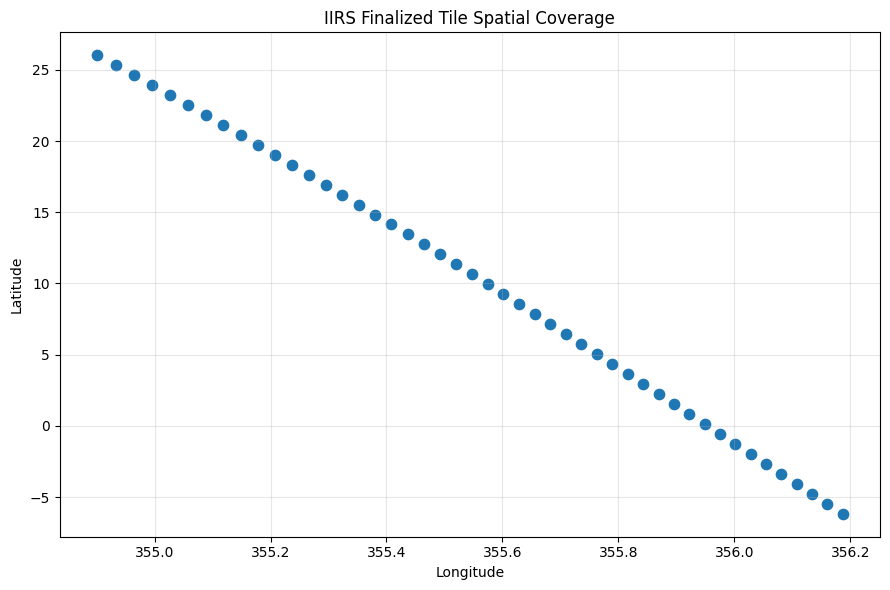

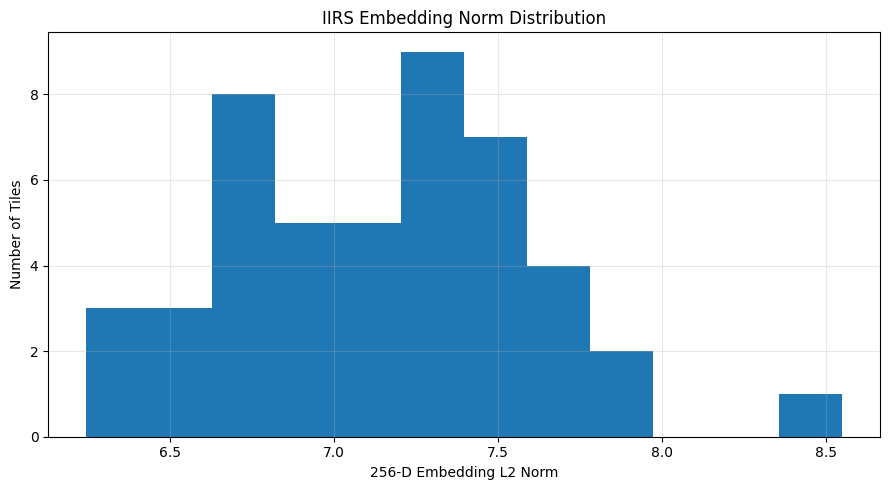


[OK] IIRS spatial metadata is finite.
[OK] IIRS embeddings are finite.
[OK] No complete embedding collapse detected.
[OK] IIRS representation is ready for TMC-2 correspondence.


In [12]:
# =============================================================================
# CELL 10 — IIRS SPATIAL AND EMBEDDING SANITY CHECK
# =============================================================================

print("=" * 80)
print("IIRS SPATIAL + EMBEDDING SANITY CHECK")
print("=" * 80)

# -------------------------------------------------------------------------
# Basic spatial statistics
# -------------------------------------------------------------------------

lat = IIRS_EMBEDDING_DF["lat"].to_numpy(dtype=np.float64)
lon = IIRS_EMBEDDING_DF["lon"].to_numpy(dtype=np.float64)

print("\n" + "-" * 80)
print("SPATIAL COVERAGE")
print("-" * 80)

print(f"Latitude range  : {lat.min():.6f} → {lat.max():.6f}")
print(f"Longitude range : {lon.min():.6f} → {lon.max():.6f}")

print(
    f"Latitude span   : {lat.max() - lat.min():.6f} degrees"
)

print(
    f"Longitude span  : {lon.max() - lon.min():.6f} degrees"
)


# -------------------------------------------------------------------------
# Check for duplicate geographic coordinates
# -------------------------------------------------------------------------

coordinates = IIRS_EMBEDDING_DF[
    ["lat", "lon"]
].round(8)

duplicate_count = coordinates.duplicated().sum()

print(f"\nDuplicate lat/lon rows: {duplicate_count}")


# -------------------------------------------------------------------------
# Embedding norms
# -------------------------------------------------------------------------

embedding_norms = np.linalg.norm(
    IIRS_EMBEDDINGS,
    axis=1
)

print("\n" + "-" * 80)
print("EMBEDDING NORMS")
print("-" * 80)

print(f"Minimum norm : {embedding_norms.min():.6f}")
print(f"Maximum norm : {embedding_norms.max():.6f}")
print(f"Mean norm    : {embedding_norms.mean():.6f}")
print(f"Std norm     : {embedding_norms.std():.6f}")


# -------------------------------------------------------------------------
# Check for collapsed embeddings
# -------------------------------------------------------------------------

embedding_std_per_dimension = IIRS_EMBEDDINGS.std(axis=0)

near_constant_dimensions = (
    embedding_std_per_dimension < 1e-6
).sum()

print(
    f"\nNear-constant embedding dimensions "
    f"(std < 1e-6): {near_constant_dimensions}/{EMBED_DIM}"
)


# -------------------------------------------------------------------------
# Pairwise cosine similarity
# -------------------------------------------------------------------------

normalized_embeddings = (
    IIRS_EMBEDDINGS /
    np.clip(
        embedding_norms[:, None],
        1e-12,
        None
    )
)

cosine_matrix = (
    normalized_embeddings
    @ normalized_embeddings.T
)

# Exclude diagonal.
off_diagonal = cosine_matrix[
    ~np.eye(
        len(cosine_matrix),
        dtype=bool
    )
]

print("\n" + "-" * 80)
print("PAIRWISE COSINE SIMILARITY")
print("-" * 80)

print(
    f"Minimum : {off_diagonal.min():.6f}"
)

print(
    f"Maximum : {off_diagonal.max():.6f}"
)

print(
    f"Mean    : {off_diagonal.mean():.6f}"
)

print(
    f"Std     : {off_diagonal.std():.6f}"
)


# -------------------------------------------------------------------------
# Spatial coverage plot
# -------------------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    lon,
    lat,
    s=55
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("IIRS Finalized Tile Spatial Coverage")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# Embedding norm distribution
# -------------------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    embedding_norms,
    bins=12
)

plt.xlabel("256-D Embedding L2 Norm")
plt.ylabel("Number of Tiles")
plt.title("IIRS Embedding Norm Distribution")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# Final checks
# -------------------------------------------------------------------------

assert np.isfinite(lat).all()
assert np.isfinite(lon).all()
assert np.isfinite(IIRS_EMBEDDINGS).all()

assert near_constant_dimensions < EMBED_DIM

print("\n[OK] IIRS spatial metadata is finite.")
print("[OK] IIRS embeddings are finite.")
print("[OK] No complete embedding collapse detected.")
print("[OK] IIRS representation is ready for TMC-2 correspondence.")

In [13]:
# =============================================================================
# CELL 11 — BUILD FINAL IIRS CORRESPONDENCE TABLE
# =============================================================================

print("=" * 80)
print("BUILDING FINAL IIRS CORRESPONDENCE TABLE")
print("=" * 80)

# -------------------------------------------------------------------------
# Start from the verified metadata
# -------------------------------------------------------------------------

IIRS_CORRESPONDENCE_DF = IIRS_EMBEDDING_DF.copy()

# Stable index used throughout the correspondence pipeline.
IIRS_CORRESPONDENCE_DF.insert(
    0,
    "iirs_index",
    np.arange(
        len(IIRS_CORRESPONDENCE_DF),
        dtype=np.int64
    )
)


# -------------------------------------------------------------------------
# Add embedding norm as a diagnostic field
# -------------------------------------------------------------------------

IIRS_CORRESPONDENCE_DF["embedding_norm"] = np.linalg.norm(
    IIRS_EMBEDDINGS,
    axis=1
)


# -------------------------------------------------------------------------
# Verify spatial and embedding alignment
# -------------------------------------------------------------------------

assert len(IIRS_CORRESPONDENCE_DF) == len(IIRS_EMBEDDINGS)

assert np.array_equal(
    IIRS_CORRESPONDENCE_DF["iirs_index"].to_numpy(),
    np.arange(len(IIRS_EMBEDDINGS))
)

assert np.isfinite(
    IIRS_CORRESPONDENCE_DF["lat"].to_numpy()
).all()

assert np.isfinite(
    IIRS_CORRESPONDENCE_DF["lon"].to_numpy()
).all()

assert np.isfinite(
    IIRS_CORRESPONDENCE_DF["embedding_norm"].to_numpy()
).all()


# -------------------------------------------------------------------------
# Display key columns
# -------------------------------------------------------------------------

display_columns = [
    "iirs_index",
    "source_scene_id",
    "tile_row",
    "tile_col",
    "lat",
    "lon",
    "resolution_m_per_px",
    "sun_azimuth",
    "sun_elevation",
    "solar_incidence",
    "valid_fraction",
    "flag_low_signal",
    "flag_geoloc_missing",
    "flag_corrupt",
    "embedding_norm",
]

available_display_columns = [
    col
    for col in display_columns
    if col in IIRS_CORRESPONDENCE_DF.columns
]

print("\nFinal IIRS correspondence table:")
display(
    IIRS_CORRESPONDENCE_DF[
        available_display_columns
    ].head(10)
)


# -------------------------------------------------------------------------
# Summary
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("FINAL IIRS CORRESPONDENCE DATASET")
print("-" * 80)

print(
    f"Rows              : {len(IIRS_CORRESPONDENCE_DF)}"
)

print(
    f"Embedding matrix  : {IIRS_EMBEDDINGS.shape}"
)

print(
    f"Unique scenes     : "
    f"{IIRS_CORRESPONDENCE_DF['source_scene_id'].nunique()}"
)

print(
    f"Valid coordinates : "
    f"{IIRS_CORRESPONDENCE_DF[['lat', 'lon']].notna().all(axis=1).sum()}"
)

print(
    f"Embedding dimension: {IIRS_EMBEDDINGS.shape[1]}"
)

print("\n[OK] Final IIRS correspondence table is aligned and validated.")

BUILDING FINAL IIRS CORRESPONDENCE TABLE

Final IIRS correspondence table:


,iirs_index,source_scene_id,tile_row,tile_col,lat,lon,resolution_m_per_px,sun_azimuth,sun_elevation,solar_incidence,valid_fraction,flag_low_signal,flag_geoloc_missing,flag_corrupt,embedding_norm
0,0,ch2_iir_nci_20260227T1239538758_d_img_d18,0,0,-6.171461,356.186895,73.08,96.319246,31.690699,58.309301,1.0,False,False,False,6.674891
1,1,ch2_iir_nci_20260227T1239538758_d_img_d18,1,0,-5.470478,356.160303,73.08,96.319246,31.690699,58.309301,1.0,False,False,False,6.526942
2,2,ch2_iir_nci_20260227T1239538758_d_img_d18,2,0,-4.769511,356.133781,73.08,96.319246,31.690699,58.309301,1.0,False,False,False,7.362946
3,3,ch2_iir_nci_20260227T1239538758_d_img_d18,3,0,-4.068574,356.107262,73.08,96.319246,31.690699,58.309301,1.0,False,False,False,7.385283
4,4,ch2_iir_nci_20260227T1239538758_d_img_d18,4,0,-3.367667,356.080800,73.08,96.319246,31.690699,58.309301,1.0,False,False,False,6.673258
5,5,ch2_iir_nci_20260227T1239538758_d_img_d18,5,0,-2.666789,356.054347,73.08,96.319246,31.690699,58.309301,1.0,False,False,False,7.522680
6,6,ch2_iir_nci_20260227T1239538758_d_img_d18,6,0,-1.965954,356.027917,73.08,96.319246,31.690699,58.309301,1.0,False,False,False,6.761700
7,7,ch2_iir_nci_20260227T1239538758_d_img_d18,7,0,-1.265144,356.001483,73.08,96.319246,31.690699,58.309301,1.0,False,False,False,7.373944
8,8,ch2_iir_nci_20260227T1239538758_d_img_d18,8,0,-0.564373,355.975062,73.08,96.319246,31.690699,58.309301,1.0,False,False,False,6.857842
9,9,ch2_iir_nci_20260227T1239538758_d_img_d18,9,0,0.136365,355.948643,73.08,96.319246,31.690699,58.309301,1.0,False,False,False,7.466675



--------------------------------------------------------------------------------
FINAL IIRS CORRESPONDENCE DATASET
--------------------------------------------------------------------------------
Rows              : 47
Embedding matrix  : (47, 256)
Unique scenes     : 1
Valid coordinates : 47
Embedding dimension: 256

[OK] Final IIRS correspondence table is aligned and validated.


In [14]:
# =============================================================================
# CELL 12 — SAVE FINAL INDEXED IIRS CORRESPONDENCE TABLE
# =============================================================================

print("=" * 80)
print("SAVING FINAL INDEXED IIRS CORRESPONDENCE TABLE")
print("=" * 80)

FINAL_IIRS_TABLE_PATH = (
    OUT_ROOT / "iirs_correspondence_table.csv"
)

IIRS_CORRESPONDENCE_DF.to_csv(
    FINAL_IIRS_TABLE_PATH,
    index=False
)


# -------------------------------------------------------------------------
# Reload and verify
# -------------------------------------------------------------------------

reloaded_iirs_table = pd.read_csv(
    FINAL_IIRS_TABLE_PATH
)

assert len(reloaded_iirs_table) == 47

assert np.array_equal(
    reloaded_iirs_table["iirs_index"].to_numpy(),
    np.arange(47)
)

assert reloaded_iirs_table["lat"].notna().all()
assert reloaded_iirs_table["lon"].notna().all()
assert reloaded_iirs_table["embedding_norm"].notna().all()


print("\nSaved:")
print(f"  {FINAL_IIRS_TABLE_PATH}")

print(
    f"\nRows              : {len(reloaded_iirs_table)}"
)

print(
    f"Columns           : {len(reloaded_iirs_table.columns)}"
)

print(
    f"Unique scenes     : "
    f"{reloaded_iirs_table['source_scene_id'].nunique()}"
)

print(
    f"Valid coordinates : "
    f"{reloaded_iirs_table[['lat', 'lon']].notna().all(axis=1).sum()}"
)

print("\n[OK] Final indexed IIRS correspondence table saved.")

SAVING FINAL INDEXED IIRS CORRESPONDENCE TABLE

Saved:
  D:\ISRO\IIRS_TMC2_correspondence\iirs_correspondence_table.csv

Rows              : 47
Columns           : 20
Unique scenes     : 1
Valid coordinates : 47

[OK] Final indexed IIRS correspondence table saved.


FINAL IIRS EMBEDDING-SPACE PCA DIAGNOSTIC

--------------------------------------------------------------------------------
PCA EXPLAINED VARIANCE
--------------------------------------------------------------------------------
PC1 variance explained : 43.28%
PC2 variance explained : 10.97%
PC1 + PC2              : 54.25%


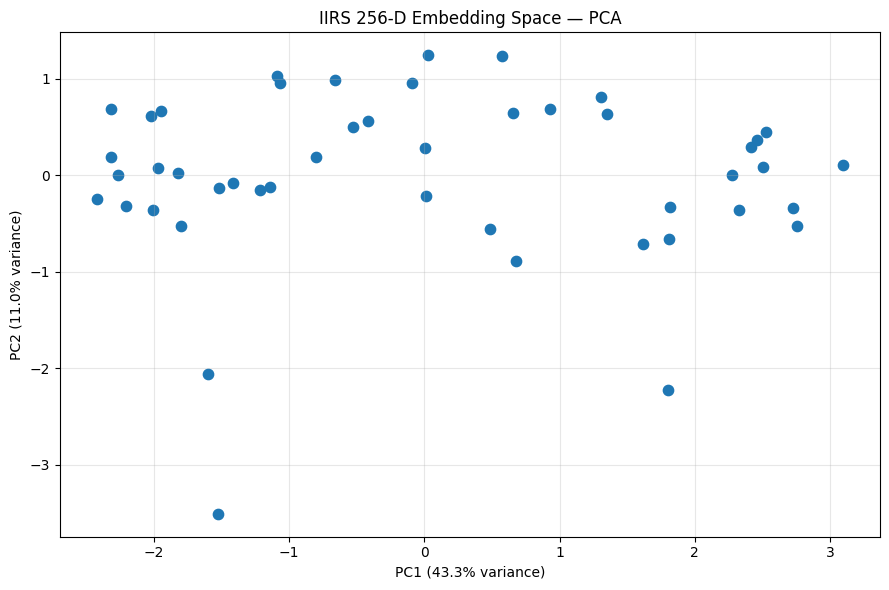

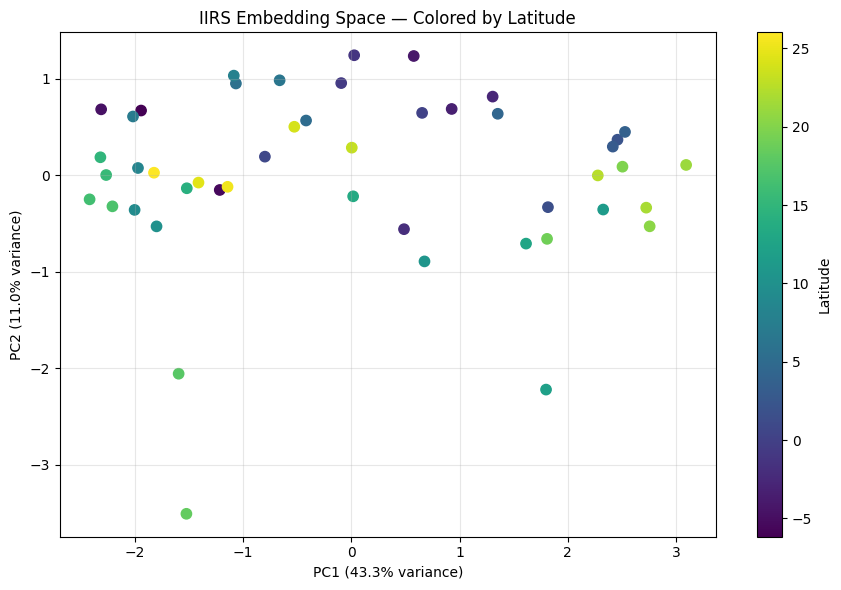


--------------------------------------------------------------------------------
PCA VERIFICATION
--------------------------------------------------------------------------------
PCA matrix shape : (47, 2)
Finite values    : True
Saved diagnostic : D:\ISRO\IIRS_TMC2_correspondence\iirs_embedding_pca.csv

[OK] IIRS embedding-space PCA diagnostic complete.
[OK] IIRS correspondence side is ready to be frozen.


In [15]:
# =============================================================================
# CELL 13 — FINAL IIRS EMBEDDING-SPACE PCA DIAGNOSTIC
# =============================================================================

print("=" * 80)
print("FINAL IIRS EMBEDDING-SPACE PCA DIAGNOSTIC")
print("=" * 80)

from sklearn.decomposition import PCA


# -------------------------------------------------------------------------
# PCA
# -------------------------------------------------------------------------

pca = PCA(
    n_components=2,
    random_state=SEED
)

IIRS_PCA = pca.fit_transform(
    IIRS_EMBEDDINGS
)


# -------------------------------------------------------------------------
# Explained variance
# -------------------------------------------------------------------------

pc1_variance = pca.explained_variance_ratio_[0]
pc2_variance = pca.explained_variance_ratio_[1]
total_variance = pc1_variance + pc2_variance

print("\n" + "-" * 80)
print("PCA EXPLAINED VARIANCE")
print("-" * 80)

print(
    f"PC1 variance explained : "
    f"{pc1_variance * 100:.2f}%"
)

print(
    f"PC2 variance explained : "
    f"{pc2_variance * 100:.2f}%"
)

print(
    f"PC1 + PC2              : "
    f"{total_variance * 100:.2f}%"
)


# -------------------------------------------------------------------------
# Add PCA coordinates to metadata
# -------------------------------------------------------------------------

IIRS_PCA_DF = IIRS_CORRESPONDENCE_DF.copy()

IIRS_PCA_DF["PC1"] = IIRS_PCA[:, 0]
IIRS_PCA_DF["PC2"] = IIRS_PCA[:, 1]


# -------------------------------------------------------------------------
# Plot PCA embedding space
# -------------------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    IIRS_PCA[:, 0],
    IIRS_PCA[:, 1],
    s=55
)

plt.xlabel(
    f"PC1 ({pc1_variance * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pc2_variance * 100:.1f}% variance)"
)

plt.title(
    "IIRS 256-D Embedding Space — PCA"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# PCA ordered by spatial position
# -------------------------------------------------------------------------

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    IIRS_PCA[:, 0],
    IIRS_PCA[:, 1],
    c=IIRS_PCA_DF["lat"].to_numpy(),
    s=55
)

plt.xlabel(
    f"PC1 ({pc1_variance * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pc2_variance * 100:.1f}% variance)"
)

plt.title(
    "IIRS Embedding Space — Colored by Latitude"
)

plt.colorbar(
    scatter,
    label="Latitude"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# Save PCA diagnostic table
# -------------------------------------------------------------------------

IIRS_PCA_PATH = (
    OUT_ROOT / "iirs_embedding_pca.csv"
)

IIRS_PCA_DF.to_csv(
    IIRS_PCA_PATH,
    index=False
)


# -------------------------------------------------------------------------
# Verification
# -------------------------------------------------------------------------

assert IIRS_PCA.shape == (47, 2)
assert np.isfinite(IIRS_PCA).all()

print("\n" + "-" * 80)
print("PCA VERIFICATION")
print("-" * 80)

print(f"PCA matrix shape : {IIRS_PCA.shape}")
print(f"Finite values    : {np.isfinite(IIRS_PCA).all()}")
print(f"Saved diagnostic : {IIRS_PCA_PATH}")

print("\n[OK] IIRS embedding-space PCA diagnostic complete.")
print("[OK] IIRS correspondence side is ready to be frozen.")

In [25]:
# =============================================================================
# CELL 14 — LOAD FINALIZED TMC-2 EMBEDDINGS AND METADATA
# =============================================================================

print("=" * 80)
print("LOADING FINALIZED TMC-2 EMBEDDINGS AND METADATA")
print("=" * 80)


# -------------------------------------------------------------------------
# Exact finalized TMC-2 artifact paths
# -------------------------------------------------------------------------

TMC2_EMBEDDINGS_PATH = (
    TMC2_DIR /
    "mvp_embeddings.npz"
)

TMC2_METADATA_PATH = (
    TMC2_DIR /
    "mvp_embeddings_manifest.csv"
)


print("\nArtifact paths:")
print(f"  Embeddings : {TMC2_EMBEDDINGS_PATH}")
print(f"  Metadata   : {TMC2_METADATA_PATH}")


# -------------------------------------------------------------------------
# Verify files exist
# -------------------------------------------------------------------------

if not TMC2_EMBEDDINGS_PATH.exists():
    raise FileNotFoundError(
        f"TMC-2 embedding artifact not found:\n"
        f"{TMC2_EMBEDDINGS_PATH}"
    )

if not TMC2_METADATA_PATH.exists():
    raise FileNotFoundError(
        f"TMC-2 embedding manifest not found:\n"
        f"{TMC2_METADATA_PATH}"
    )


print("\n[OK] Required TMC-2 artifacts found.")


# -------------------------------------------------------------------------
# Load embedding artifact
# -------------------------------------------------------------------------

with np.load(
    TMC2_EMBEDDINGS_PATH,
    allow_pickle=True
) as tmc2_artifact:

    print("\n" + "-" * 80)
    print("TMC-2 EMBEDDING ARTIFACT")
    print("-" * 80)

    print(
        f"Keys: {tmc2_artifact.files}"
    )

    if "embeddings" not in tmc2_artifact.files:
        raise KeyError(
            "TMC-2 embedding artifact does not contain "
            "the required 'embeddings' array."
        )

    if "patch_id" not in tmc2_artifact.files:
        raise KeyError(
            "TMC-2 embedding artifact does not contain "
            "the required 'patch_id' array."
        )

    TMC2_EMBEDDINGS = np.asarray(
        tmc2_artifact["embeddings"],
        dtype=np.float32
    )

    TMC2_PATCH_IDS = np.asarray(
        tmc2_artifact["patch_id"]
    )


# -------------------------------------------------------------------------
# Load metadata
# -------------------------------------------------------------------------

TMC2_METADATA_DF = pd.read_csv(
    TMC2_METADATA_PATH
)


# -------------------------------------------------------------------------
# Basic artifact validation
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("TMC-2 ARTIFACT VALIDATION")
print("-" * 80)

print(
    f"Embedding matrix shape : "
    f"{TMC2_EMBEDDINGS.shape}"
)

print(
    f"Embedding dtype        : "
    f"{TMC2_EMBEDDINGS.dtype}"
)

print(
    f"Patch ID count         : "
    f"{len(TMC2_PATCH_IDS)}"
)

print(
    f"Metadata rows          : "
    f"{len(TMC2_METADATA_DF)}"
)

print(
    f"Metadata columns       : "
    f"{len(TMC2_METADATA_DF.columns)}"
)


# -------------------------------------------------------------------------
# Hard shape checks
# -------------------------------------------------------------------------

if TMC2_EMBEDDINGS.ndim != 2:
    raise ValueError(
        f"TMC-2 embeddings must be 2-D, got "
        f"{TMC2_EMBEDDINGS.ndim}-D."
    )

if TMC2_EMBEDDINGS.shape[1] != EMBED_DIM:
    raise ValueError(
        f"TMC-2 embedding dimension mismatch: "
        f"expected {EMBED_DIM}, "
        f"got {TMC2_EMBEDDINGS.shape[1]}"
    )

if len(TMC2_PATCH_IDS) != len(TMC2_EMBEDDINGS):
    raise ValueError(
        "TMC-2 embedding count and patch_id count do not match."
    )

if len(TMC2_METADATA_DF) != len(TMC2_EMBEDDINGS):
    raise ValueError(
        "TMC-2 metadata row count and embedding count do not match."
    )


# -------------------------------------------------------------------------
# Required metadata columns
# -------------------------------------------------------------------------

REQUIRED_TMC2_COLUMNS = [
    "patch_id",
    "source_scene_id",
    "source_product_id",
    "observation_id",
    "camera",
    "sensor_id",
    "observation_time_utc",
    "imaging_orbit_number",
    "pixel_resolution_m",
    "patch_row0",
    "patch_col0",
    "patch_size_px",
    "tile_row",
    "tile_col",
    "lat",
    "lon",
    "geolocation_source",
    "sun_azimuth_deg",
    "sun_elevation_deg",
    "solar_incidence_deg",
    "valid_fraction",
    "saturation_fraction",
    "entropy",
    "flag_low_texture",
    "flag_geoloc_missing",
    "flag_ancillary_missing",
    "qa_status",
    "patch_npz_path",
    "split",
]

missing_tmc2_columns = [
    col
    for col in REQUIRED_TMC2_COLUMNS
    if col not in TMC2_METADATA_DF.columns
]

if missing_tmc2_columns:
    raise ValueError(
        "TMC-2 metadata is missing required columns:\n"
        + "\n".join(
            f"  - {col}"
            for col in missing_tmc2_columns
        )
    )


# -------------------------------------------------------------------------
# Verify patch-ID alignment
# -------------------------------------------------------------------------

artifact_patch_ids = [
    str(x)
    for x in TMC2_PATCH_IDS
]

metadata_patch_ids = (
    TMC2_METADATA_DF["patch_id"]
    .astype(str)
    .tolist()
)

if artifact_patch_ids != metadata_patch_ids:
    raise ValueError(
        "TMC-2 patch_id ordering does not exactly match "
        "the metadata manifest ordering."
    )


# -------------------------------------------------------------------------
# Verify embeddings
# -------------------------------------------------------------------------

finite_embedding_mask = np.isfinite(
    TMC2_EMBEDDINGS
).all(axis=1)

embedding_norms = np.linalg.norm(
    TMC2_EMBEDDINGS,
    axis=1
)

finite_coordinate_mask = (
    np.isfinite(
        pd.to_numeric(
            TMC2_METADATA_DF["lat"],
            errors="coerce"
        )
    )
    &
    np.isfinite(
        pd.to_numeric(
            TMC2_METADATA_DF["lon"],
            errors="coerce"
        )
    )
)


# -------------------------------------------------------------------------
# Print validation results
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("TMC-2 VALIDATION RESULTS")
print("-" * 80)

print(
    f"Finite embeddings : "
    f"{finite_embedding_mask.sum()}/"
    f"{len(finite_embedding_mask)}"
)

print(
    f"Finite coordinates: "
    f"{finite_coordinate_mask.sum()}/"
    f"{len(finite_coordinate_mask)}"
)

print(
    f"Unique patch IDs   : "
    f"{TMC2_METADATA_DF['patch_id'].nunique()}"
)

print(
    f"Unique scenes      : "
    f"{TMC2_METADATA_DF['source_scene_id'].nunique()}"
)

print(
    f"Cameras            : "
    f"{TMC2_METADATA_DF['camera'].unique().tolist()}"
)

print(
    f"Observations       : "
    f"{TMC2_METADATA_DF['observation_id'].nunique()}"
)

print(
    f"Embedding norm     : "
    f"mean={embedding_norms.mean():.6f}, "
    f"std={embedding_norms.std():.6f}"
)


# -------------------------------------------------------------------------
# Hard validation
# -------------------------------------------------------------------------

assert TMC2_EMBEDDINGS.shape == (
    len(TMC2_METADATA_DF),
    EMBED_DIM
)

assert finite_embedding_mask.all()

assert finite_coordinate_mask.all()

assert (
    TMC2_METADATA_DF["patch_id"].nunique()
    == len(TMC2_METADATA_DF)
)

assert (
    artifact_patch_ids
    == metadata_patch_ids
)


# -------------------------------------------------------------------------
# Display first metadata rows
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("FIRST 5 TMC-2 METADATA ROWS")
print("-" * 80)

display(
    TMC2_METADATA_DF[
        [
            "patch_id",
            "source_scene_id",
            "observation_id",
            "camera",
            "lat",
            "lon",
            "pixel_resolution_m",
            "patch_row0",
            "patch_col0",
            "valid_fraction",
            "saturation_fraction",
            "entropy",
            "flag_low_texture",
            "flag_geoloc_missing",
            "flag_ancillary_missing",
            "qa_status",
            "split",
        ]
    ].head(5)
)


# -------------------------------------------------------------------------
# Final status
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("TMC-2 EMBEDDING + METADATA LOAD COMPLETE")
print("=" * 80)

print(
    f"\n[OK] Loaded {len(TMC2_EMBEDDINGS)} "
    f"TMC-2 embeddings."
)

print(
    f"[OK] Embedding dimension = "
    f"{TMC2_EMBEDDINGS.shape[1]}."
)

print(
    "[OK] Embeddings are finite."
)

print(
    "[OK] TMC-2 coordinates are finite."
)

print(
    "[OK] TMC-2 patch IDs are aligned "
    "with the metadata manifest."
)

print(
    "[OK] TMC-2 artifact is ready for "
    "geographic candidate-pair construction."
)

LOADING FINALIZED TMC-2 EMBEDDINGS AND METADATA

Artifact paths:
  Embeddings : D:\ISRO\TMC_tiles\mvp_embeddings.npz
  Metadata   : D:\ISRO\TMC_tiles\mvp_embeddings_manifest.csv

[OK] Required TMC-2 artifacts found.

--------------------------------------------------------------------------------
TMC-2 EMBEDDING ARTIFACT
--------------------------------------------------------------------------------
Keys: ['embeddings', 'patch_id']

--------------------------------------------------------------------------------
TMC-2 ARTIFACT VALIDATION
--------------------------------------------------------------------------------
Embedding matrix shape : (400, 256)
Embedding dtype        : float32
Patch ID count         : 400
Metadata rows          : 400
Metadata columns       : 49

--------------------------------------------------------------------------------
TMC-2 VALIDATION RESULTS
--------------------------------------------------------------------------------
Finite embeddings : 400/400
Fin

,patch_id,source_scene_id,observation_id,camera,lat,lon,pixel_resolution_m,patch_row0,patch_col0,valid_fraction,saturation_fraction,entropy,flag_low_texture,flag_geoloc_missing,flag_ancillary_missing,qa_status,split
0,ch2_tmc_nca_20260813T1023298778_d_img_d18_r137...,ch2_tmc_nca_20260813T1023298778_d_img_d18,orbit31075,AFT,-27.981855,139.385485,5.48,137984,1024,1.0,0.0,1.509643,True,False,True,SUCCESS,train
1,ch2_tmc_nca_20260813T1023298778_d_img_d18_r058...,ch2_tmc_nca_20260813T1023298778_d_img_d18,orbit31075,AFT,-14.989283,139.553331,5.48,58112,2816,1.0,0.0,1.761593,True,False,True,SUCCESS,train
2,ch2_tmc_nca_20260813T1023298778_d_img_d18_r141...,ch2_tmc_nca_20260813T1023298778_d_img_d18,orbit31075,AFT,-28.609796,139.472153,5.48,141824,512,1.0,0.0,1.966714,True,False,True,SUCCESS,train
3,ch2_tmc_nca_20260813T1023298778_d_img_d18_r060...,ch2_tmc_nca_20260813T1023298778_d_img_d18,orbit31075,AFT,-15.329313,139.753525,5.48,60160,1792,1.0,0.0,2.332231,True,False,True,SUCCESS,train
4,ch2_tmc_nca_20260813T1023298778_d_img_d18_r088...,ch2_tmc_nca_20260813T1023298778_d_img_d18,orbit31075,AFT,-19.849680,139.187949,5.48,88064,3584,1.0,0.0,2.224879,True,False,True,SUCCESS,train



TMC-2 EMBEDDING + METADATA LOAD COMPLETE

[OK] Loaded 400 TMC-2 embeddings.
[OK] Embedding dimension = 256.
[OK] Embeddings are finite.
[OK] TMC-2 coordinates are finite.
[OK] TMC-2 patch IDs are aligned with the metadata manifest.
[OK] TMC-2 artifact is ready for geographic candidate-pair construction.


In [26]:
# =============================================================================
# CELL 15 — IIRS ↔ TMC-2 GEOGRAPHIC OVERLAP ANALYSIS
# =============================================================================

print("=" * 80)
print("IIRS ↔ TMC-2 GEOGRAPHIC OVERLAP ANALYSIS")
print("=" * 80)


# -------------------------------------------------------------------------
# Helper: normalize longitude to [-180, 180)
# -------------------------------------------------------------------------

def normalize_longitude(lon):
    """
    Convert longitude from any convention, including 0-360,
    into the standard [-180, 180) range.
    """
    lon = np.asarray(lon, dtype=np.float64)
    return ((lon + 180.0) % 360.0) - 180.0


# -------------------------------------------------------------------------
# Extract coordinates
# -------------------------------------------------------------------------

iirs_lat = pd.to_numeric(
    IIRS_CORRESPONDENCE_DF["lat"],
    errors="coerce"
).to_numpy(dtype=np.float64)

iirs_lon_raw = pd.to_numeric(
    IIRS_CORRESPONDENCE_DF["lon"],
    errors="coerce"
).to_numpy(dtype=np.float64)

tmc2_lat = pd.to_numeric(
    TMC2_METADATA_DF["lat"],
    errors="coerce"
).to_numpy(dtype=np.float64)

tmc2_lon_raw = pd.to_numeric(
    TMC2_METADATA_DF["lon"],
    errors="coerce"
).to_numpy(dtype=np.float64)


iirs_lon = normalize_longitude(iirs_lon_raw)
tmc2_lon = normalize_longitude(tmc2_lon_raw)


# -------------------------------------------------------------------------
# Basic coordinate validation
# -------------------------------------------------------------------------

assert np.isfinite(iirs_lat).all()
assert np.isfinite(iirs_lon).all()
assert np.isfinite(tmc2_lat).all()
assert np.isfinite(tmc2_lon).all()


print("\n" + "-" * 80)
print("GEOGRAPHIC COVERAGE")
print("-" * 80)

print(
    f"IIRS latitude range       : "
    f"{iirs_lat.min():.6f} → {iirs_lat.max():.6f}"
)

print(
    f"IIRS longitude range      : "
    f"{iirs_lon.min():.6f} → {iirs_lon.max():.6f}"
)

print(
    f"TMC-2 latitude range      : "
    f"{tmc2_lat.min():.6f} → {tmc2_lat.max():.6f}"
)

print(
    f"TMC-2 longitude range     : "
    f"{tmc2_lon.min():.6f} → {tmc2_lon.max():.6f}"
)


# -------------------------------------------------------------------------
# Bounding-box overlap
# -------------------------------------------------------------------------

lat_overlap_min = max(
    iirs_lat.min(),
    tmc2_lat.min()
)

lat_overlap_max = min(
    iirs_lat.max(),
    tmc2_lat.max()
)

lon_overlap_min = max(
    iirs_lon.min(),
    tmc2_lon.min()
)

lon_overlap_max = min(
    iirs_lon.max(),
    tmc2_lon.max()
)

lat_overlap = (
    lat_overlap_min <= lat_overlap_max
)

lon_overlap = (
    lon_overlap_min <= lon_overlap_max
)

bbox_overlap = (
    lat_overlap
    and lon_overlap
)


print("\n" + "-" * 80)
print("BOUNDING-BOX OVERLAP")
print("-" * 80)

print(
    f"Latitude overlap : "
    f"{'YES' if lat_overlap else 'NO'}"
)

if lat_overlap:
    print(
        f"  Overlap range : "
        f"{lat_overlap_min:.6f} → "
        f"{lat_overlap_max:.6f}"
    )

print(
    f"Longitude overlap: "
    f"{'YES' if lon_overlap else 'NO'}"
)

if lon_overlap:
    print(
        f"  Overlap range : "
        f"{lon_overlap_min:.6f} → "
        f"{lon_overlap_max:.6f}"
    )

print(
    f"Overall bbox overlap: "
    f"{'YES' if bbox_overlap else 'NO'}"
)


# -------------------------------------------------------------------------
# Haversine distance
# -------------------------------------------------------------------------

EARTH_RADIUS_M = 1737400.0


def haversine_distance_m(
    lat1,
    lon1,
    lat2,
    lon2
):
    """
    Great-circle distance on a spherical Moon model.

    Coordinates are in degrees.
    Returns distance in metres.
    """

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        +
        np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2.0) ** 2
    )

    a = np.clip(a, 0.0, 1.0)

    c = 2.0 * np.arcsin(
        np.sqrt(a)
    )

    return EARTH_RADIUS_M * c


# -------------------------------------------------------------------------
# Compute nearest TMC-2 patch for every IIRS tile
# -------------------------------------------------------------------------

print("\n" + "-" * 80)
print("NEAREST TMC-2 DISTANCE FOR EACH IIRS TILE")
print("-" * 80)


nearest_distances_m = np.empty(
    len(IIRS_CORRESPONDENCE_DF),
    dtype=np.float64
)

nearest_tmc2_indices = np.empty(
    len(IIRS_CORRESPONDENCE_DF),
    dtype=np.int64
)


for i in range(len(IIRS_CORRESPONDENCE_DF)):

    distances = haversine_distance_m(
        iirs_lat[i],
        iirs_lon[i],
        tmc2_lat,
        tmc2_lon
    )

    nearest_idx = int(
        np.argmin(distances)
    )

    nearest_tmc2_indices[i] = nearest_idx
    nearest_distances_m[i] = distances[nearest_idx]


# -------------------------------------------------------------------------
# Nearest-neighbour summary
# -------------------------------------------------------------------------

print(
    f"Minimum IIRS → TMC-2 distance : "
    f"{nearest_distances_m.min():,.2f} m"
)

print(
    f"Maximum nearest distance      : "
    f"{nearest_distances_m.max():,.2f} m"
)

print(
    f"Mean nearest distance         : "
    f"{nearest_distances_m.mean():,.2f} m"
)

print(
    f"Median nearest distance       : "
    f"{np.median(nearest_distances_m):,.2f} m"
)


# -------------------------------------------------------------------------
# Compare against correspondence threshold
# -------------------------------------------------------------------------

within_threshold = (
    nearest_distances_m
    <= MAX_PAIR_DISTANCE_M
)

candidate_count = int(
    within_threshold.sum()
)

print("\n" + "-" * 80)
print("300-METRE CORRESPONDENCE TEST")
print("-" * 80)

print(
    f"Maximum allowed distance : "
    f"{MAX_PAIR_DISTANCE_M:.1f} m"
)

print(
    f"IIRS tiles within threshold: "
    f"{candidate_count}/{len(IIRS_CORRESPONDENCE_DF)}"
)


# -------------------------------------------------------------------------
# Identify globally closest pair
# -------------------------------------------------------------------------

global_iirs_idx = int(
    np.argmin(nearest_distances_m)
)

global_tmc2_idx = int(
    nearest_tmc2_indices[global_iirs_idx]
)

global_distance_m = (
    nearest_distances_m[global_iirs_idx]
)


print("\n" + "-" * 80)
print("CLOSEST IIRS ↔ TMC-2 PAIR")
print("-" * 80)

print(
    f"IIRS index       : "
    f"{global_iirs_idx}"
)

print(
    f"IIRS coordinates : "
    f"({iirs_lat[global_iirs_idx]:.6f}, "
    f"{iirs_lon_raw[global_iirs_idx]:.6f}°)"
)

print(
    f"TMC-2 index      : "
    f"{global_tmc2_idx}"
)

print(
    f"TMC-2 coordinates: "
    f"({tmc2_lat[global_tmc2_idx]:.6f}, "
    f"{tmc2_lon_raw[global_tmc2_idx]:.6f}°)"
)

print(
    f"Distance         : "
    f"{global_distance_m:,.2f} m"
)


# -------------------------------------------------------------------------
# Display closest pair metadata
# -------------------------------------------------------------------------

iirs_closest_row = (
    IIRS_CORRESPONDENCE_DF
    .iloc[global_iirs_idx]
)

tmc2_closest_row = (
    TMC2_METADATA_DF
    .iloc[global_tmc2_idx]
)

print("\n" + "-" * 80)
print("CLOSEST-PAIR IDENTIFIERS")
print("-" * 80)

print(
    f"IIRS scene : "
    f"{iirs_closest_row['source_scene_id']}"
)

print(
    f"IIRS tile   : "
    f"row={iirs_closest_row['tile_row']}, "
    f"col={iirs_closest_row['tile_col']}"
)

print(
    f"TMC-2 scene: "
    f"{tmc2_closest_row['source_scene_id']}"
)

print(
    f"TMC-2 patch: "
    f"{tmc2_closest_row['patch_id']}"
)

print(
    f"TMC-2 camera: "
    f"{tmc2_closest_row['camera']}"
)


# -------------------------------------------------------------------------
# Final decision
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("GEOGRAPHIC CORRESPONDENCE DECISION")
print("=" * 80)

if candidate_count > 0:

    print(
        f"\n[OK] {candidate_count} IIRS tiles have at least "
        f"one TMC-2 patch within {MAX_PAIR_DISTANCE_M:.1f} m."
    )

    print(
        "[NEXT] The next cell can construct "
        "geographic candidate pairs."
    )

else:

    print(
        "\n[STOP] No IIRS ↔ TMC-2 candidate pairs "
        f"exist within {MAX_PAIR_DISTANCE_M:.1f} m."
    )

    print(
        "[IMPORTANT] Do NOT train the correspondence mapper "
        "on these two observations."
    )

    print(
        "[ACTION] A geographically overlapping TMC-2 "
        "observation/scene is required first."
    )

IIRS ↔ TMC-2 GEOGRAPHIC OVERLAP ANALYSIS

--------------------------------------------------------------------------------
GEOGRAPHIC COVERAGE
--------------------------------------------------------------------------------
IIRS latitude range       : -6.171461 → 26.021799
IIRS longitude range      : -5.099390 → -3.813105
TMC-2 latitude range      : -29.190945 → -5.550645
TMC-2 longitude range     : 138.753509 → 140.440730

--------------------------------------------------------------------------------
BOUNDING-BOX OVERLAP
--------------------------------------------------------------------------------
Latitude overlap : YES
  Overlap range : -6.171461 → -5.550645
Longitude overlap: NO
Overall bbox overlap: NO

--------------------------------------------------------------------------------
NEAREST TMC-2 DISTANCE FOR EACH IIRS TILE
--------------------------------------------------------------------------------
Minimum IIRS → TMC-2 distance : 3,929,609.70 m
Maximum nearest distance   

In [27]:
# =============================================================================
# CELL 16 — CAMERA-ROBUST TMC-2 SCENE / OBSERVATION DISCOVERY
# =============================================================================
#
# PURPOSE
# -------
# Discover every TMC-2 observation available in the raw archive while treating
# AFT, NADIR, and FORE as OPTIONAL cameras.
#
# Rules:
#   - 3 cameras available -> use all 3
#   - 2 cameras available -> use both
#   - 1 camera available  -> use that one
#   - 0 cameras           -> observation is ignored
#
# IMPORTANT:
#   We do NOT require a complete AFT + NADIR + FORE observation.
#   We do NOT fabricate missing cameras.
#   We retain camera identity for downstream pairing/training/evaluation.
# =============================================================================

from pathlib import Path
import re
import pandas as pd


print("=" * 80)
print("CAMERA-ROBUST TMC-2 SCENE / OBSERVATION DISCOVERY")
print("=" * 80)


# -----------------------------------------------------------------------------
# 1. TMC-2 raw archive
# -----------------------------------------------------------------------------

TMC2_RAW_ROOT = PROJECT_ROOT / "TMC_raws"

if not TMC2_RAW_ROOT.exists():
    raise FileNotFoundError(
        f"TMC-2 raw archive not found:\n{TMC2_RAW_ROOT}"
    )

print(f"\nTMC-2 raw root:")
print(f"  {TMC2_RAW_ROOT}")


# -----------------------------------------------------------------------------
# 2. Discover TMC-2 image XML files recursively
# -----------------------------------------------------------------------------
#
# We search recursively because the archive may contain:
#
#   observation/
#       data/
#       browse/
#       geometry/
#
# and different observations may be stored at different depths.
#
# We intentionally do NOT assume a miscellaneous folder.
# -----------------------------------------------------------------------------

image_xml_files = sorted(
    [
        p
        for p in TMC2_RAW_ROOT.rglob("*.xml")
        if "_d_img_" in p.name.lower()
    ]
)


print("\n" + "-" * 80)
print("TMC-2 IMAGE PRODUCTS")
print("-" * 80)

print(
    f"Image XML files discovered: {len(image_xml_files)}"
)

if len(image_xml_files) == 0:
    print(
        "\n[WARNING] No TMC-2 image XML files were discovered."
    )


# -----------------------------------------------------------------------------
# 3. Scene ID extraction
# -----------------------------------------------------------------------------

def extract_tmc2_scene_id(path):
    """
    Extract the TMC-2 scene/product identifier from an image XML filename.

    Expected form resembles:
        ch2_tmc_nca_20260813T1023298778_d_img_d18

    The function intentionally keeps the complete scene identifier.
    """

    match = re.search(
        r"(ch2_tmc_[^\\/]+?_d_img_d18)",
        path.name,
        flags=re.IGNORECASE
    )

    if match:
        return match.group(1)

    # Fallback: remove XML suffix if the expected pattern is absent.
    return path.stem


# -----------------------------------------------------------------------------
# 4. Camera extraction
# -----------------------------------------------------------------------------
#
# TMC-2 product identifiers encode the camera through the processing/product
# designation:
#
#   NCA -> AFT
#   NCN -> NADIR
#   NCF -> FORE
#
# We also inspect the complete filename/path as a fallback.
# -----------------------------------------------------------------------------

def infer_tmc2_camera(path):
    """
    Infer TMC-2 camera from the product identifier.

    Returns:
        AFT / NADIR / FORE / UNKNOWN
    """

    text = str(path).lower()

    # Strong product-code based detection.
    #
    # These checks are deliberately ordered by exact filename token patterns
    # rather than loose substring matching.
    if re.search(r"ch2_tmc_nca_", text):
        return "AFT"

    if re.search(r"ch2_tmc_ncn_", text):
        return "NADIR"

    if re.search(r"ch2_tmc_ncf_", text):
        return "FORE"

    # Filename/path fallback.
    if re.search(r"(^|[_\-])aft([_\-\.]|$)", text):
        return "AFT"

    if re.search(r"(^|[_\-])nadir([_\-\.]|$)", text):
        return "NADIR"

    if re.search(r"(^|[_\-])fore([_\-\.]|$)", text):
        return "FORE"

    return "UNKNOWN"


# -----------------------------------------------------------------------------
# 5. Observation grouping key
# -----------------------------------------------------------------------------
#
# The camera-specific scene IDs are different:
#
#   ch2_tmc_nca_...
#   ch2_tmc_ncn_...
#   ch2_tmc_ncf_...
#
# but they may belong to the SAME observation.
#
# Therefore we create a camera-independent observation key by replacing:
#
#   nca / ncn / ncf
#
# with:
#
#   CAMERA
#
# This lets all available cameras from the same observation be grouped
# together without requiring all three cameras to exist.
# -----------------------------------------------------------------------------

def make_observation_key(scene_id):
    """
    Convert a camera-specific TMC-2 scene ID into a camera-independent
    observation grouping key.
    """

    key = re.sub(
        r"ch2_tmc_(nca|ncn|ncf)_",
        "ch2_tmc_camera_",
        scene_id,
        flags=re.IGNORECASE
    )

    return key


# -----------------------------------------------------------------------------
# 6. Build camera-level discovery table
# -----------------------------------------------------------------------------

camera_records = []

for xml_path in image_xml_files:

    scene_id = extract_tmc2_scene_id(
        xml_path
    )

    camera = infer_tmc2_camera(
        xml_path
    )

    observation_key = make_observation_key(
        scene_id
    )

    camera_records.append(
        {
            "observation_key": observation_key,
            "scene_id": scene_id,
            "camera": camera,
            "image_xml": str(xml_path),
        }
    )


TMC2_CAMERA_DF = pd.DataFrame(
    camera_records
)


# -----------------------------------------------------------------------------
# 7. Remove exact duplicate discovery records
# -----------------------------------------------------------------------------

if len(TMC2_CAMERA_DF) > 0:

    TMC2_CAMERA_DF = (
        TMC2_CAMERA_DF
        .drop_duplicates(
            subset=[
                "observation_key",
                "scene_id",
                "camera",
                "image_xml",
            ]
        )
        .reset_index(drop=True)
    )


# -----------------------------------------------------------------------------
# 8. Report camera-level discoveries
# -----------------------------------------------------------------------------

print("\n" + "-" * 80)
print("CAMERA-LEVEL DISCOVERY")
print("-" * 80)

if len(TMC2_CAMERA_DF) == 0:

    print(
        "[WARNING] No camera-level TMC-2 products found."
    )

else:

    print(
        f"Camera-level products: {len(TMC2_CAMERA_DF)}"
    )

    print(
        "\nCamera counts:"
    )

    print(
        TMC2_CAMERA_DF["camera"]
        .value_counts(dropna=False)
        .to_string()
    )

    print(
        "\nDiscovered products:"
    )

    display(
        TMC2_CAMERA_DF[
            [
                "observation_key",
                "scene_id",
                "camera",
            ]
        ]
        .sort_values(
            [
                "observation_key",
                "camera",
            ]
        )
        .reset_index(drop=True)
    )


# -----------------------------------------------------------------------------
# 9. Build observation-level table
# -----------------------------------------------------------------------------
#
# This table explicitly records WHICH cameras exist.
#
# Examples:
#
#   AFT + NADIR + FORE -> complete 3-camera observation
#   AFT + NADIR        -> valid 2-camera observation
#   AFT                -> valid 1-camera observation
#
# No incomplete observation is discarded.
# -----------------------------------------------------------------------------

OBSERVATION_ROWS = []

CAMERA_ORDER = [
    "NADIR",
    "AFT",
    "FORE",
]


if len(TMC2_CAMERA_DF) > 0:

    for observation_key, group in TMC2_CAMERA_DF.groupby(
        "observation_key",
        sort=True
    ):

        available_cameras = sorted(
            set(
                group["camera"].astype(str)
            )
            .intersection(
                {"AFT", "NADIR", "FORE"}
            ),
            key=lambda x: CAMERA_ORDER.index(x)
        )

        camera_count = len(
            available_cameras
        )

        OBSERVATION_ROWS.append(
            {
                "observation_key": observation_key,
                "available_cameras": ",".join(
                    available_cameras
                ),
                "camera_count": camera_count,
                "has_aft": "AFT" in available_cameras,
                "has_nadir": "NADIR" in available_cameras,
                "has_fore": "FORE" in available_cameras,
                "complete_three_camera_observation": (
                    camera_count == 3
                ),
            }
        )


TMC2_OBSERVATION_DF = pd.DataFrame(
    OBSERVATION_ROWS
)


# -----------------------------------------------------------------------------
# 10. Keep only observations with >= 1 usable camera
# -----------------------------------------------------------------------------

if len(TMC2_OBSERVATION_DF) > 0:

    TMC2_OBSERVATION_DF = (
        TMC2_OBSERVATION_DF[
            TMC2_OBSERVATION_DF["camera_count"] >= 1
        ]
        .reset_index(drop=True)
    )


# -----------------------------------------------------------------------------
# 11. Observation-level summary
# -----------------------------------------------------------------------------

print("\n" + "-" * 80)
print("OBSERVATION-LEVEL DISCOVERY")
print("-" * 80)

print(
    f"Usable observations: "
    f"{len(TMC2_OBSERVATION_DF)}"
)


if len(TMC2_OBSERVATION_DF) > 0:

    display(
        TMC2_OBSERVATION_DF
    )


# -----------------------------------------------------------------------------
# 12. Camera availability summary
# -----------------------------------------------------------------------------

print("\n" + "-" * 80)
print("CAMERA AVAILABILITY SUMMARY")
print("-" * 80)

if len(TMC2_OBSERVATION_DF) > 0:

    n_three = int(
        (
            TMC2_OBSERVATION_DF["camera_count"] == 3
        ).sum()
    )

    n_two = int(
        (
            TMC2_OBSERVATION_DF["camera_count"] == 2
        ).sum()
    )

    n_one = int(
        (
            TMC2_OBSERVATION_DF["camera_count"] == 1
        ).sum()
    )

    print(
        f"3-camera observations : {n_three}"
    )

    print(
        f"2-camera observations : {n_two}"
    )

    print(
        f"1-camera observations : {n_one}"
    )

else:

    print(
        "No usable observations found."
    )


# -----------------------------------------------------------------------------
# 13. Explicit camera policy
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("CAMERA HANDLING POLICY")
print("=" * 80)

print(
    "\n[OK] AFT, NADIR, and FORE are treated as independent optional cameras."
)

print(
    "[OK] If all 3 cameras exist, all 3 will be used."
)

print(
    "[OK] If 2 cameras exist, both will be used."
)

print(
    "[OK] If only 1 camera exists, that camera will be used."
)

print(
    "[OK] Missing cameras are NOT fabricated."
)

print(
    "[OK] Missing cameras do NOT cause an observation to be discarded."
)

print(
    "[OK] Camera identity is preserved for pairing, training, and evaluation."
)


# -----------------------------------------------------------------------------
# 14. Current MVP comparison
# -----------------------------------------------------------------------------

if "TMC2_METADATA_DF" in globals() and len(TMC2_METADATA_DF) > 0:

    current_scene_ids = (
        TMC2_METADATA_DF["source_scene_id"]
        .astype(str)
        .dropna()
        .unique()
        .tolist()
    )

    current_cameras = sorted(
        TMC2_METADATA_DF["camera"]
        .astype(str)
        .dropna()
        .unique()
        .tolist()
    )

    print("\n" + "-" * 80)
    print("CURRENT TMC-2 EMBEDDING MVP")
    print("-" * 80)

    print(
        f"Scene(s): {current_scene_ids}"
    )

    print(
        f"Camera(s): {current_cameras}"
    )

    print(
        "\n[INFO] The current MVP may contain only AFT."
    )

    print(
        "[INFO] That is valid; future observations with NADIR and/or FORE "
        "will be incorporated automatically."
    )


# -----------------------------------------------------------------------------
# 15. Final status
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("CAMERA-ROBUST DISCOVERY COMPLETE")
print("=" * 80)

if len(TMC2_OBSERVATION_DF) > 0:

    print(
        f"\n[READY] {len(TMC2_OBSERVATION_DF)} "
        f"usable TMC-2 observation(s) discovered."
    )

    print(
        "\n[NEXT] The next cell should evaluate geographic overlap "
        "with IIRS separately for EVERY available camera."
    )

else:

    print(
        "\n[STOP] No usable TMC-2 observations were discovered."
    )

CAMERA-ROBUST TMC-2 SCENE / OBSERVATION DISCOVERY

TMC-2 raw root:
  D:\ISRO\TMC_raws

--------------------------------------------------------------------------------
TMC-2 IMAGE PRODUCTS
--------------------------------------------------------------------------------
Image XML files discovered: 1

--------------------------------------------------------------------------------
CAMERA-LEVEL DISCOVERY
--------------------------------------------------------------------------------
Camera-level products: 1

Camera counts:
camera
AFT    1

Discovered products:


,observation_key,scene_id,camera
0,ch2_tmc_camera_20260813T1023298778_d_img_d18,ch2_tmc_nca_20260813T1023298778_d_img_d18,AFT



--------------------------------------------------------------------------------
OBSERVATION-LEVEL DISCOVERY
--------------------------------------------------------------------------------
Usable observations: 1


,observation_key,available_cameras,camera_count,has_aft,has_nadir,has_fore,complete_three_camera_observation
0,ch2_tmc_camera_20260813T1023298778_d_img_d18,AFT,1,True,False,False,False



--------------------------------------------------------------------------------
CAMERA AVAILABILITY SUMMARY
--------------------------------------------------------------------------------
3-camera observations : 0
2-camera observations : 0
1-camera observations : 1

CAMERA HANDLING POLICY

[OK] AFT, NADIR, and FORE are treated as independent optional cameras.
[OK] If all 3 cameras exist, all 3 will be used.
[OK] If 2 cameras exist, both will be used.
[OK] If only 1 camera exists, that camera will be used.
[OK] Missing cameras are NOT fabricated.
[OK] Missing cameras do NOT cause an observation to be discarded.
[OK] Camera identity is preserved for pairing, training, and evaluation.

--------------------------------------------------------------------------------
CURRENT TMC-2 EMBEDDING MVP
--------------------------------------------------------------------------------
Scene(s): ['ch2_tmc_nca_20260813T1023298778_d_img_d18']
Camera(s): ['AFT']

[INFO] The current MVP may contain only

In [29]:
# =============================================================================
# CELL 17 — CAMERA-WISE IIRS ↔ TMC-2 GEOGRAPHIC OVERLAP ANALYSIS
# =============================================================================
#
# FIX:
# ----
# This cell does NOT assume that an object called IIRS_TABLE exists.
# It automatically finds the IIRS correspondence table already created in
# the previous cells.
#
# CAMERA POLICY:
#   3 cameras -> use all 3
#   2 cameras -> use both
#   1 camera  -> use that one
#   0 cameras -> nothing to process
#
# No missing camera is fabricated.
# No observation is rejected merely because a camera is missing.
# No mapper training happens in this cell.
# =============================================================================

import numpy as np
import pandas as pd
from pathlib import Path


print("=" * 80)
print("IIRS ↔ TMC-2 CAMERA-WISE GEOGRAPHIC OVERLAP ANALYSIS")
print("=" * 80)


# =============================================================================
# 1. LOCATE IIRS CORRESPONDENCE TABLE
# =============================================================================

print("\n" + "-" * 80)
print("LOCATING IIRS CORRESPONDENCE TABLE")
print("-" * 80)


# -------------------------------------------------------------------------
# Known artifact created earlier in this notebook
# -------------------------------------------------------------------------

IIRS_TABLE_PATH = (
    OUT_ROOT.parent /
    "IIRS_TMC2_correspondence" /
    "iirs_correspondence_table.csv"
)


# If the path above does not exist, use the known IIRS output directory.
if not IIRS_TABLE_PATH.exists():

    IIRS_TABLE_PATH = (
        PROJECT_ROOT /
        "IIRS_TMC2_correspondence" /
        "iirs_correspondence_table.csv"
    )


if IIRS_TABLE_PATH.exists():

    print(
        f"[OK] Found IIRS correspondence table:\n"
        f"     {IIRS_TABLE_PATH}"
    )

    IIRS_TABLE = pd.read_csv(
        IIRS_TABLE_PATH
    )

else:

    # -------------------------------------------------------------------------
    # Fallback: look for an already-loaded DataFrame with the required columns
    # -------------------------------------------------------------------------

    candidate_tables = []

    for variable_name, variable_value in list(
        globals().items()
    ):

        if isinstance(
            variable_value,
            pd.DataFrame
        ):

            columns = set(
                variable_value.columns
            )

            if {
                "lat",
                "lon"
            }.issubset(columns):

                candidate_tables.append(
                    (
                        variable_name,
                        variable_value
                    )
                )


    if len(candidate_tables) == 0:

        raise RuntimeError(
            "Could not locate the IIRS correspondence table.\n\n"
            "Expected file:\n"
            f"{IIRS_TABLE_PATH}\n\n"
            "Please run the previous IIRS correspondence-table cell first."
        )


    # Prefer a table whose name contains IIRS and correspondence.
    preferred = [
        item
        for item in candidate_tables
        if (
            "iirs" in item[0].lower()
            and
            "correspond" in item[0].lower()
        )
    ]


    if len(preferred) > 0:

        selected_name, IIRS_TABLE = preferred[0]

    else:

        selected_name, IIRS_TABLE = candidate_tables[0]


    print(
        f"[OK] Using loaded DataFrame: {selected_name}"
    )


print(
    f"IIRS rows: {len(IIRS_TABLE)}"
)

print(
    f"IIRS columns: {len(IIRS_TABLE.columns)}"
)


# =============================================================================
# 2. VALIDATE IIRS COORDINATES
# =============================================================================

required_iirs_columns = [
    "lat",
    "lon",
]

missing_iirs_columns = [
    column
    for column in required_iirs_columns
    if column not in IIRS_TABLE.columns
]

if missing_iirs_columns:

    raise KeyError(
        "IIRS table is missing required columns: "
        + ", ".join(missing_iirs_columns)
        + "\n\nAvailable columns:\n"
        + str(list(IIRS_TABLE.columns))
    )


iirs_lat_all = pd.to_numeric(
    IIRS_TABLE["lat"],
    errors="coerce"
).to_numpy(
    dtype=np.float64
)

iirs_lon_all = pd.to_numeric(
    IIRS_TABLE["lon"],
    errors="coerce"
).to_numpy(
    dtype=np.float64
)


iirs_valid = (
    np.isfinite(iirs_lat_all)
    &
    np.isfinite(iirs_lon_all)
)


iirs_indices = np.where(
    iirs_valid
)[0]


iirs_lat = iirs_lat_all[
    iirs_valid
]

iirs_lon = iirs_lon_all[
    iirs_valid
]


if len(iirs_lat) == 0:

    raise RuntimeError(
        "IIRS correspondence table contains no valid geographic coordinates."
    )


# =============================================================================
# 3. NORMALIZE LONGITUDE
# =============================================================================

def normalize_longitude(lon):
    """
    Convert longitude to [-180, 180).
    """

    return (
        (
            np.asarray(
                lon,
                dtype=np.float64
            )
            + 180.0
        )
        % 360.0
    ) - 180.0


iirs_lon_normalized = normalize_longitude(
    iirs_lon
)


# =============================================================================
# 4. LOCATE TMC-2 METADATA
# =============================================================================

print("\n" + "-" * 80)
print("LOCATING TMC-2 EMBEDDING METADATA")
print("-" * 80)


# The previous Cell 14 created TMC2_METADATA_DF.
# If it is still in memory, use it.
if (
    "TMC2_METADATA_DF" in globals()
    and
    isinstance(
        TMC2_METADATA_DF,
        pd.DataFrame
    )
):

    TMC_META = TMC2_METADATA_DF.copy()

    print(
        "[OK] Using TMC2_METADATA_DF from memory."
    )

else:

    # Fallback to the actual artifact already discovered in Cell 14.
    fallback_tmc_metadata = (
        PROJECT_ROOT /
        "TMC_tiles" /
        "mvp_embeddings_manifest.csv"
    )

    if not fallback_tmc_metadata.exists():

        raise RuntimeError(
            "TMC-2 metadata could not be found.\n\n"
            "Expected:\n"
            f"{fallback_tmc_metadata}\n\n"
            "Please run the previous TMC-2 artifact discovery cell first."
        )

    TMC_META = pd.read_csv(
        fallback_tmc_metadata
    )

    print(
        "[OK] Loaded TMC-2 metadata from:"
    )

    print(
        f"     {fallback_tmc_metadata}"
    )


print(
    f"TMC-2 metadata rows: {len(TMC_META)}"
)


# =============================================================================
# 5. VALIDATE TMC-2 COORDINATES + CAMERA
# =============================================================================

required_tmc_columns = [
    "camera",
    "lat",
    "lon",
]

missing_tmc_columns = [
    column
    for column in required_tmc_columns
    if column not in TMC_META.columns
]

if missing_tmc_columns:

    raise KeyError(
        "TMC-2 metadata is missing required columns: "
        + ", ".join(missing_tmc_columns)
        + "\n\nAvailable columns:\n"
        + str(list(TMC_META.columns))
    )


TMC_META["_lat_numeric"] = pd.to_numeric(
    TMC_META["lat"],
    errors="coerce"
)

TMC_META["_lon_numeric"] = pd.to_numeric(
    TMC_META["lon"],
    errors="coerce"
)

TMC_META["_lon_normalized"] = normalize_longitude(
    TMC_META["_lon_numeric"].to_numpy(
        dtype=np.float64
    )
)


TMC_META["_coord_valid"] = (
    np.isfinite(
        TMC_META["_lat_numeric"].to_numpy(
            dtype=np.float64
        )
    )
    &
    np.isfinite(
        TMC_META["_lon_normalized"].to_numpy(
            dtype=np.float64
        )
    )
)


# =============================================================================
# 6. FIND EVERY AVAILABLE CAMERA
# =============================================================================

CAMERA_ORDER = [
    "AFT",
    "NADIR",
    "FORE",
]


TMC_META["_camera_normalized"] = (
    TMC_META["camera"]
    .astype(str)
    .str.upper()
    .str.strip()
)


available_cameras = [
    camera
    for camera in CAMERA_ORDER
    if (
        TMC_META["_camera_normalized"]
        .eq(camera)
        &
        TMC_META["_coord_valid"]
    ).any()
]


print("\n" + "-" * 80)
print("AVAILABLE TMC-2 CAMERAS")
print("-" * 80)


if len(available_cameras) == 0:

    raise RuntimeError(
        "No geolocated AFT, NADIR, or FORE TMC-2 patches were found."
    )


for camera in CAMERA_ORDER:

    count = int(
        (
            TMC_META["_camera_normalized"]
            .eq(camera)
            &
            TMC_META["_coord_valid"]
        ).sum()
    )

    if count > 0:

        print(
            f"{camera:5s}: {count} geolocated patches"
        )

    else:

        print(
            f"{camera:5s}: not available"
        )


print(
    f"\n[OK] Cameras that will be evaluated: "
    f"{available_cameras}"
)


# =============================================================================
# 7. Haversine distance on the Moon
# =============================================================================

MOON_RADIUS_M = 1_737_400.0


def haversine_matrix_m(
    lat1_deg,
    lon1_deg,
    lat2_deg,
    lon2_deg,
):
    """
    Pairwise great-circle distance on the Moon.

    Output shape:
        len(lat1) × len(lat2)
    """

    lat1 = np.radians(
        np.asarray(
            lat1_deg,
            dtype=np.float64
        )
    )[:, None]

    lon1 = np.radians(
        np.asarray(
            lon1_deg,
            dtype=np.float64
        )
    )[:, None]

    lat2 = np.radians(
        np.asarray(
            lat2_deg,
            dtype=np.float64
        )
    )[None, :]

    lon2 = np.radians(
        np.asarray(
            lon2_deg,
            dtype=np.float64
        )
    )[None, :]


    dlat = lat2 - lat1
    dlon = lon2 - lon1


    a = (
        np.sin(dlat / 2.0) ** 2
        +
        np.cos(lat1)
        *
        np.cos(lat2)
        *
        np.sin(dlon / 2.0) ** 2
    )


    a = np.clip(
        a,
        0.0,
        1.0
    )


    c = (
        2.0
        *
        np.arcsin(
            np.sqrt(a)
        )
    )


    return (
        MOON_RADIUS_M
        *
        c
    )


# =============================================================================
# 8. CAMERA-WISE OVERLAP ANALYSIS
# =============================================================================

CAMERA_OVERLAP_RESULTS = []

CAMERA_CANDIDATE_PAIRS = {}


for camera in available_cameras:

    print("\n")
    print("=" * 80)
    print(f"TMC-2 CAMERA: {camera}")
    print("=" * 80)


    # -------------------------------------------------------------------------
    # Select only this camera
    # -------------------------------------------------------------------------

    camera_mask = (
        TMC_META["_camera_normalized"]
        .eq(camera)
        &
        TMC_META["_coord_valid"]
    )


    camera_meta = (
        TMC_META[
            camera_mask
        ]
        .copy()
        .reset_index(drop=False)
        .rename(
            columns={
                "index": "_original_tmc_index"
            }
        )
    )


    tmc_lat = camera_meta[
        "_lat_numeric"
    ].to_numpy(
        dtype=np.float64
    )

    tmc_lon = camera_meta[
        "_lon_normalized"
    ].to_numpy(
        dtype=np.float64
    )


    # -------------------------------------------------------------------------
    # Geographic coverage
    # -------------------------------------------------------------------------

    iirs_lat_min = float(
        iirs_lat.min()
    )

    iirs_lat_max = float(
        iirs_lat.max()
    )

    iirs_lon_min = float(
        iirs_lon_normalized.min()
    )

    iirs_lon_max = float(
        iirs_lon_normalized.max()
    )


    tmc_lat_min = float(
        tmc_lat.min()
    )

    tmc_lat_max = float(
        tmc_lat.max()
    )

    tmc_lon_min = float(
        tmc_lon.min()
    )

    tmc_lon_max = float(
        tmc_lon.max()
    )


    latitude_overlap_min = max(
        iirs_lat_min,
        tmc_lat_min
    )

    latitude_overlap_max = min(
        iirs_lat_max,
        tmc_lat_max
    )


    longitude_overlap_min = max(
        iirs_lon_min,
        tmc_lon_min
    )

    longitude_overlap_max = min(
        iirs_lon_max,
        tmc_lon_max
    )


    latitude_overlap = (
        latitude_overlap_min
        <=
        latitude_overlap_max
    )


    longitude_overlap = (
        longitude_overlap_min
        <=
        longitude_overlap_max
    )


    bbox_overlap = (
        latitude_overlap
        and
        longitude_overlap
    )


    print("\n" + "-" * 80)
    print("GEOGRAPHIC COVERAGE")
    print("-" * 80)


    print(
        f"IIRS latitude range       : "
        f"{iirs_lat_min:.6f} → {iirs_lat_max:.6f}"
    )

    print(
        f"IIRS longitude range      : "
        f"{iirs_lon_min:.6f} → {iirs_lon_max:.6f}"
    )


    print(
        f"{camera} latitude range     : "
        f"{tmc_lat_min:.6f} → {tmc_lat_max:.6f}"
    )

    print(
        f"{camera} longitude range    : "
        f"{tmc_lon_min:.6f} → {tmc_lon_max:.6f}"
    )


    print(
        f"\nLatitude bbox overlap     : "
        f"{'YES' if latitude_overlap else 'NO'}"
    )

    print(
        f"Longitude bbox overlap    : "
        f"{'YES' if longitude_overlap else 'NO'}"
    )

    print(
        f"Overall bbox overlap      : "
        f"{'YES' if bbox_overlap else 'NO'}"
    )


    # -------------------------------------------------------------------------
    # Pairwise nearest-neighbour distances
    # -------------------------------------------------------------------------

    distance_matrix = haversine_matrix_m(
        iirs_lat,
        iirs_lon_normalized,
        tmc_lat,
        tmc_lon,
    )


    nearest_tmc_positions = np.argmin(
        distance_matrix,
        axis=1
    )


    nearest_distances_m = np.min(
        distance_matrix,
        axis=1
    )


    print("\n" + "-" * 80)
    print("NEAREST-PATCH DISTANCES")
    print("-" * 80)


    print(
        f"Minimum IIRS → {camera} distance : "
        f"{nearest_distances_m.min():,.2f} m"
    )

    print(
        f"Maximum nearest distance          : "
        f"{nearest_distances_m.max():,.2f} m"
    )

    print(
        f"Mean nearest distance             : "
        f"{nearest_distances_m.mean():,.2f} m"
    )

    print(
        f"Median nearest distance           : "
        f"{np.median(nearest_distances_m):,.2f} m"
    )


    # -------------------------------------------------------------------------
    # 300 m candidate threshold
    # -------------------------------------------------------------------------

    candidate_mask = (
        nearest_distances_m
        <=
        MAX_PAIR_DISTANCE_M
    )


    candidate_count = int(
        candidate_mask.sum()
    )


    print("\n" + "-" * 80)
    print("CORRESPONDENCE TEST")
    print("-" * 80)


    print(
        f"Maximum allowed distance : "
        f"{MAX_PAIR_DISTANCE_M:.1f} m"
    )

    print(
        f"IIRS tiles within threshold: "
        f"{candidate_count}/{len(iirs_lat)}"
    )


    # -------------------------------------------------------------------------
    # Build candidate pairs
    # -------------------------------------------------------------------------

    candidate_rows = []


    for local_iirs_position in np.where(
        candidate_mask
    )[0]:

        local_tmc_position = int(
            nearest_tmc_positions[
                local_iirs_position
            ]
        )


        original_iirs_index = int(
            iirs_indices[
                local_iirs_position
            ]
        )


        original_tmc_index = int(
            camera_meta.loc[
                local_tmc_position,
                "_original_tmc_index"
            ]
        )


        distance_m = float(
            nearest_distances_m[
                local_iirs_position
            ]
        )


        row = {
            "iirs_index": original_iirs_index,
            "tmc2_index": original_tmc_index,
            "camera": camera,
            "distance_m": distance_m,
            "iirs_lat": float(
                iirs_lat[
                    local_iirs_position
                ]
            ),
            "iirs_lon": float(
                iirs_lon[
                    local_iirs_position
                ]
            ),
            "tmc2_lat": float(
                tmc_lat[
                    local_tmc_position
                ]
            ),
            "tmc2_lon": float(
                tmc_lon[
                    local_tmc_position
                ]
            ),
        }


        # Preserve identifiers whenever present.
        for column in [
            "patch_id",
            "source_scene_id",
            "source_product_id",
            "observation_id",
            "camera",
        ]:

            if column in camera_meta.columns:

                row[
                    f"tmc2_{column}"
                ] = camera_meta.loc[
                    local_tmc_position,
                    column
                ]


        candidate_rows.append(
            row
        )


    camera_pairs_df = pd.DataFrame(
        candidate_rows
    )


    CAMERA_CANDIDATE_PAIRS[
        camera
    ] = camera_pairs_df


    # -------------------------------------------------------------------------
    # Closest pair
    # -------------------------------------------------------------------------

    closest_position = int(
        np.argmin(
            nearest_distances_m
        )
    )


    closest_tmc_position = int(
        nearest_tmc_positions[
            closest_position
        ]
    )


    closest_iirs_index = int(
        iirs_indices[
            closest_position
        ]
    )


    closest_tmc_index = int(
        camera_meta.loc[
            closest_tmc_position,
            "_original_tmc_index"
        ]
    )


    closest_distance = float(
        nearest_distances_m[
            closest_position
        ]
    )


    print("\n" + "-" * 80)
    print(f"CLOSEST IIRS ↔ {camera} PAIR")
    print("-" * 80)


    print(
        f"IIRS index       : "
        f"{closest_iirs_index}"
    )


    print(
        f"IIRS coordinates : "
        f"({iirs_lat[closest_position]:.6f}, "
        f"{iirs_lon[closest_position]:.6f}°)"
    )


    print(
        f"TMC-2 index      : "
        f"{closest_tmc_index}"
    )


    print(
        f"TMC-2 coordinates: "
        f"({tmc_lat[closest_tmc_position]:.6f}, "
        f"{tmc_lon[closest_tmc_position]:.6f}°)"
    )


    print(
        f"Distance         : "
        f"{closest_distance:,.2f} m"
    )


    # -------------------------------------------------------------------------
    # Save result
    # -------------------------------------------------------------------------

    CAMERA_OVERLAP_RESULTS.append(
        {
            "camera": camera,
            "tmc2_patches": len(camera_meta),
            "bbox_overlap": bbox_overlap,
            "nearest_min_m": float(
                nearest_distances_m.min()
            ),
            "nearest_mean_m": float(
                nearest_distances_m.mean()
            ),
            "nearest_median_m": float(
                np.median(nearest_distances_m)
            ),
            "candidate_iirs": candidate_count,
        }
    )


# =============================================================================
# 9. COMBINED CAMERA SUMMARY
# =============================================================================

CAMERA_OVERLAP_SUMMARY = pd.DataFrame(
    CAMERA_OVERLAP_RESULTS
)


print("\n\n" + "=" * 80)
print("ALL-CAMERA OVERLAP SUMMARY")
print("=" * 80)


if len(CAMERA_OVERLAP_SUMMARY) > 0:

    display(
        CAMERA_OVERLAP_SUMMARY
    )

else:

    print(
        "[WARNING] No camera overlap results generated."
    )


# =============================================================================
# 10. COMBINE CANDIDATE PAIRS FROM ALL AVAILABLE CAMERAS
# =============================================================================

non_empty_pair_tables = [
    df
    for df in CAMERA_CANDIDATE_PAIRS.values()
    if len(df) > 0
]


if len(non_empty_pair_tables) > 0:

    ALL_IIRS_TMC2_CANDIDATE_PAIRS = pd.concat(
        non_empty_pair_tables,
        ignore_index=True
    )

else:

    ALL_IIRS_TMC2_CANDIDATE_PAIRS = pd.DataFrame()


print("\n" + "-" * 80)
print("COMBINED CAMERA CANDIDATES")
print("-" * 80)


print(
    f"Total candidate pairs across all available cameras: "
    f"{len(ALL_IIRS_TMC2_CANDIDATE_PAIRS)}"
)


if len(
    ALL_IIRS_TMC2_CANDIDATE_PAIRS
) > 0:

    print(
        "\nCandidate pairs by camera:"
    )

    print(
        ALL_IIRS_TMC2_CANDIDATE_PAIRS[
            "camera"
        ]
        .value_counts()
        .to_string()
    )

    display(
        ALL_IIRS_TMC2_CANDIDATE_PAIRS.head(
            20
        )
    )


# =============================================================================
# 11. SAVE DIAGNOSTIC ARTIFACTS
# =============================================================================

overlap_summary_path = (
    OUT_ROOT /
    "evaluation" /
    "camera_overlap_summary.csv"
)

overlap_summary_path.parent.mkdir(
    parents=True,
    exist_ok=True
)


CAMERA_OVERLAP_SUMMARY.to_csv(
    overlap_summary_path,
    index=False
)


candidate_pairs_path = (
    OUT_ROOT /
    "pairs" /
    "camera_geographic_candidate_pairs.csv"
)

candidate_pairs_path.parent.mkdir(
    parents=True,
    exist_ok=True
)


ALL_IIRS_TMC2_CANDIDATE_PAIRS.to_csv(
    candidate_pairs_path,
    index=False
)


# =============================================================================
# 12. FINAL DECISION
# =============================================================================

print("\n" + "=" * 80)
print("GEOGRAPHIC CORRESPONDENCE DECISION")
print("=" * 80)


if len(
    ALL_IIRS_TMC2_CANDIDATE_PAIRS
) == 0:

    print(
        f"\n[STOP] No IIRS ↔ TMC-2 candidate pairs exist "
        f"within {MAX_PAIR_DISTANCE_M:.1f} m."
    )

    print(
        "[IMPORTANT] Do NOT train the correspondence mapper "
        "on the current observations."
    )

    print(
        "[ACTION] A geographically overlapping TMC-2 observation "
        "is required first."
    )

else:

    print(
        f"\n[READY] "
        f"{len(ALL_IIRS_TMC2_CANDIDATE_PAIRS)} "
        f"candidate pair(s) found."
    )

    print(
        "\n[OK] Every available camera with valid candidates "
        "has been retained."
    )

    print(
        "[OK] The pipeline does not require all three cameras."
    )

    print(
        "\nCandidate counts by camera:"
    )

    print(
        ALL_IIRS_TMC2_CANDIDATE_PAIRS[
            "camera"
        ]
        .value_counts()
        .to_string()
    )


print("\n" + "=" * 80)
print("CAMERA-WISE GEOGRAPHIC ANALYSIS COMPLETE")
print("=" * 80)

IIRS ↔ TMC-2 CAMERA-WISE GEOGRAPHIC OVERLAP ANALYSIS

--------------------------------------------------------------------------------
LOCATING IIRS CORRESPONDENCE TABLE
--------------------------------------------------------------------------------
[OK] Found IIRS correspondence table:
     D:\ISRO\IIRS_TMC2_correspondence\iirs_correspondence_table.csv
IIRS rows: 47
IIRS columns: 20

--------------------------------------------------------------------------------
LOCATING TMC-2 EMBEDDING METADATA
--------------------------------------------------------------------------------
[OK] Using TMC2_METADATA_DF from memory.
TMC-2 metadata rows: 400

--------------------------------------------------------------------------------
AVAILABLE TMC-2 CAMERAS
--------------------------------------------------------------------------------
AFT  : 400 geolocated patches
NADIR: not available
FORE : not available

[OK] Cameras that will be evaluated: ['AFT']


TMC-2 CAMERA: AFT

-----------------------

,camera,tmc2_patches,bbox_overlap,nearest_min_m,nearest_mean_m,nearest_median_m,candidate_iirs
0,AFT,400,False,3.929610e+06,4.206865e+06,4.263682e+06,0



--------------------------------------------------------------------------------
COMBINED CAMERA CANDIDATES
--------------------------------------------------------------------------------
Total candidate pairs across all available cameras: 0

GEOGRAPHIC CORRESPONDENCE DECISION

[STOP] No IIRS ↔ TMC-2 candidate pairs exist within 300.0 m.
[IMPORTANT] Do NOT train the correspondence mapper on the current observations.
[ACTION] A geographically overlapping TMC-2 observation is required first.

CAMERA-WISE GEOGRAPHIC ANALYSIS COMPLETE


In [30]:
# ============================================================
# CELL 18 — IIRS ↔ TMC-2
# LOAD REAL EMBEDDINGS FOR CONTROLLED SYNTHETIC BENCHMARK
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

print("=" * 80)
print("IIRS ↔ TMC-2 CONTROLLED CORRESPONDENCE BENCHMARK")
print("=" * 80)

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(r"D:\ISRO")

IIRS_CORR_DIR = PROJECT_ROOT / "IIRS_TMC2_correspondence"
TMC2_DIR = PROJECT_ROOT / "TMC_tiles"

IIRS_EMBED_PATH = (
    IIRS_CORR_DIR / "iirs_embeddings_256.npy"
)

IIRS_META_PATH = (
    IIRS_CORR_DIR / "iirs_embeddings_metadata.csv"
)

TMC2_EMBED_PATH = (
    TMC2_DIR / "mvp_embeddings.npz"
)

TMC2_META_PATH = (
    TMC2_DIR / "mvp_embeddings_manifest.csv"
)

print("\nPaths:")
print("IIRS embeddings :", IIRS_EMBED_PATH)
print("IIRS metadata   :", IIRS_META_PATH)
print("TMC-2 embeddings:", TMC2_EMBED_PATH)
print("TMC-2 metadata  :", TMC2_META_PATH)


# ------------------------------------------------------------
# 2. Load IIRS embeddings
# ------------------------------------------------------------

if not IIRS_EMBED_PATH.exists():
    raise FileNotFoundError(
        f"IIRS embedding file not found:\n{IIRS_EMBED_PATH}"
    )

if not IIRS_META_PATH.exists():
    raise FileNotFoundError(
        f"IIRS metadata file not found:\n{IIRS_META_PATH}"
    )

IIRS_EMBEDDINGS = np.load(
    IIRS_EMBED_PATH
).astype(np.float32)

IIRS_METADATA = pd.read_csv(
    IIRS_META_PATH
)

print("\nIIRS:")
print("  embeddings shape:", IIRS_EMBEDDINGS.shape)
print("  metadata rows   :", len(IIRS_METADATA))


# ------------------------------------------------------------
# 3. Load TMC-2 embeddings
# ------------------------------------------------------------

if not TMC2_EMBED_PATH.exists():
    raise FileNotFoundError(
        f"TMC-2 embedding file not found:\n{TMC2_EMBED_PATH}"
    )

if not TMC2_META_PATH.exists():
    raise FileNotFoundError(
        f"TMC-2 metadata file not found:\n{TMC2_META_PATH}"
    )

tmc2_npz = np.load(
    TMC2_EMBED_PATH,
    allow_pickle=True
)

TMC2_EMBEDDINGS = tmc2_npz["embeddings"].astype(np.float32)

TMC2_METADATA = pd.read_csv(
    TMC2_META_PATH
)

print("\nTMC-2:")
print("  embeddings shape:", TMC2_EMBEDDINGS.shape)
print("  metadata rows   :", len(TMC2_METADATA))


# ------------------------------------------------------------
# 4. Validate dimensions
# ------------------------------------------------------------

assert IIRS_EMBEDDINGS.ndim == 2
assert TMC2_EMBEDDINGS.ndim == 2

assert IIRS_EMBEDDINGS.shape[1] == 256
assert TMC2_EMBEDDINGS.shape[1] == 256

assert len(IIRS_EMBEDDINGS) == len(IIRS_METADATA)
assert len(TMC2_EMBEDDINGS) == len(TMC2_METADATA)

assert np.isfinite(IIRS_EMBEDDINGS).all()
assert np.isfinite(TMC2_EMBEDDINGS).all()

print("\n[OK] IIRS embeddings are valid 256-D finite vectors.")
print("[OK] TMC-2 embeddings are valid 256-D finite vectors.")
print("[OK] Metadata/embedding row counts agree.")


# ------------------------------------------------------------
# 5. Report source data honestly
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SOURCE DATA STATUS")
print("=" * 80)

print(
    "\nThese are REAL embeddings generated from the existing "
    "IIRS and TMC-2 observations."
)

print(
    "\nImportant:"
)

print(
    "The current geographic analysis found no real "
    "IIRS ↔ TMC-2 geographic correspondences."
)

print(
    "Therefore these observations will NOT be labelled as "
    "real cross-modal positive pairs."
)

print(
    "\nThe next experiment creates a CONTROLLED SYNTHETIC "
    "CORRESPONDENCE BENCHMARK from these real embeddings."
)

print(
    "\nNo synthetic sample will be represented as a real "
    "Chandrayaan-2 observation."
)

print("\n" + "=" * 80)
print("CELL 18 COMPLETE")
print("=" * 80)

IIRS ↔ TMC-2 CONTROLLED CORRESPONDENCE BENCHMARK

Paths:
IIRS embeddings : D:\ISRO\IIRS_TMC2_correspondence\iirs_embeddings_256.npy
IIRS metadata   : D:\ISRO\IIRS_TMC2_correspondence\iirs_embeddings_metadata.csv
TMC-2 embeddings: D:\ISRO\TMC_tiles\mvp_embeddings.npz
TMC-2 metadata  : D:\ISRO\TMC_tiles\mvp_embeddings_manifest.csv

IIRS:
  embeddings shape: (47, 256)
  metadata rows   : 47

TMC-2:
  embeddings shape: (400, 256)
  metadata rows   : 400

[OK] IIRS embeddings are valid 256-D finite vectors.
[OK] TMC-2 embeddings are valid 256-D finite vectors.
[OK] Metadata/embedding row counts agree.

SOURCE DATA STATUS

These are REAL embeddings generated from the existing IIRS and TMC-2 observations.

Important:
The current geographic analysis found no real IIRS ↔ TMC-2 geographic correspondences.
Therefore these observations will NOT be labelled as real cross-modal positive pairs.

The next experiment creates a CONTROLLED SYNTHETIC CORRESPONDENCE BENCHMARK from these real embeddings.

N

In [31]:
# ============================================================
# CELL 19 — IIRS ↔ TMC-2
# CONTROLLED SYNTHETIC CORRESPONDENCE DATASET
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 80)
print("IIRS ↔ TMC-2 CONTROLLED SYNTHETIC CORRESPONDENCE DATASET")
print("=" * 80)


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

SEED = 42
rng = np.random.default_rng(SEED)

SYNTHETIC_DIR = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "pairs"
    / "synthetic_benchmark"
)

SYNTHETIC_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Number of real TMC-2 embeddings used as source anchors.
N_ANCHORS = min(
    400,
    len(TMC2_EMBEDDINGS)
)

# Number of synthetic counterparts generated per anchor.
VIEWS_PER_ANCHOR = 5

# Controlled perturbation strengths.
NOISE_LEVELS = [
    0.02,
    0.05,
    0.10,
]

# Fraction of dimensions receiving a mild scale perturbation.
DIMENSION_SCALE_FRACTION = 0.25

print("\nConfiguration:")
print("  Random seed              :", SEED)
print("  Source TMC-2 anchors     :", N_ANCHORS)
print("  Synthetic views/anchor  :", VIEWS_PER_ANCHOR)
print("  Noise levels             :", NOISE_LEVELS)
print("  Dimension scale fraction :", DIMENSION_SCALE_FRACTION)


# ------------------------------------------------------------
# 2. Select real TMC-2 anchors
# ------------------------------------------------------------

anchor_indices = rng.choice(
    len(TMC2_EMBEDDINGS),
    size=N_ANCHORS,
    replace=False
)

anchor_embeddings = (
    TMC2_EMBEDDINGS[anchor_indices]
    .astype(np.float32)
)

anchor_metadata = (
    TMC2_METADATA.iloc[anchor_indices]
    .reset_index(drop=True)
)

print("\n[OK] Selected real TMC-2 source embeddings.")


# ------------------------------------------------------------
# 3. Robust embedding statistics
# ------------------------------------------------------------

embedding_std = np.std(
    anchor_embeddings,
    axis=0
).astype(np.float32)

# Prevent extremely small dimensions from producing
# unstable synthetic perturbations.
embedding_std = np.maximum(
    embedding_std,
    1e-3
)

global_std = float(
    np.std(anchor_embeddings)
)

if global_std <= 0:
    raise RuntimeError(
        "TMC-2 embeddings have zero global variance."
    )

print("\nReal TMC-2 embedding statistics:")
print("  Global mean:", float(np.mean(anchor_embeddings)))
print("  Global std :", global_std)
print("  Min value  :", float(np.min(anchor_embeddings)))
print("  Max value  :", float(np.max(anchor_embeddings)))


# ------------------------------------------------------------
# 4. Synthetic transformation function
# ------------------------------------------------------------

def create_synthetic_counterpart(
    source,
    noise_fraction,
    rng,
):
    """
    Create a controlled synthetic counterpart from a REAL
    TMC-2 embedding.

    This is NOT claimed to be an actual IIRS observation.

    The transformation combines:
      1. mild global scale change
      2. dimension-wise scale variation
      3. Gaussian perturbation
      4. small additive domain shift

    The original source vector remains the ground-truth
    correspondence target.
    """

    x = source.astype(np.float32).copy()

    # --------------------------------------------------------
    # A. Global scale transformation
    # --------------------------------------------------------

    global_scale = rng.uniform(
        0.90,
        1.10
    )

    x = x * global_scale


    # --------------------------------------------------------
    # B. Dimension-wise scale variation
    # --------------------------------------------------------

    n_dims = len(x)

    n_scaled = max(
        1,
        int(
            DIMENSION_SCALE_FRACTION
            * n_dims
        )
    )

    scaled_dims = rng.choice(
        n_dims,
        size=n_scaled,
        replace=False
    )

    dimension_scale = rng.uniform(
        0.90,
        1.10,
        size=n_scaled
    ).astype(np.float32)

    x[scaled_dims] *= dimension_scale


    # --------------------------------------------------------
    # C. Noise proportional to real embedding statistics
    # --------------------------------------------------------

    noise = rng.normal(
        loc=0.0,
        scale=embedding_std * noise_fraction,
        size=n_dims
    ).astype(np.float32)

    x = x + noise


    # --------------------------------------------------------
    # D. Small additive domain shift
    # --------------------------------------------------------

    domain_shift = rng.normal(
        loc=0.0,
        scale=global_std * noise_fraction * 0.05,
        size=n_dims
    ).astype(np.float32)

    x = x + domain_shift

    return x.astype(np.float32)


# ------------------------------------------------------------
# 5. Generate synthetic pairs
# ------------------------------------------------------------

records = []

synthetic_embeddings = []
target_embeddings = []

synthetic_id = 0

for anchor_position in range(N_ANCHORS):

    source_embedding = anchor_embeddings[
        anchor_position
    ]

    source_metadata = anchor_metadata.iloc[
        anchor_position
    ]

    source_patch_id = str(
        source_metadata.get(
            "patch_id",
            f"tmc2_anchor_{anchor_position}"
        )
    )

    for view_index in range(VIEWS_PER_ANCHOR):

        # Cycle through the defined perturbation strengths.
        noise_fraction = NOISE_LEVELS[
            view_index % len(NOISE_LEVELS)
        ]

        synthetic_embedding = (
            create_synthetic_counterpart(
                source_embedding,
                noise_fraction,
                rng
            )
        )

        synthetic_embeddings.append(
            synthetic_embedding
        )

        target_embeddings.append(
            source_embedding
        )

        records.append({
            "synthetic_id":
                f"iirs_tmc2_syn_{synthetic_id:05d}",

            "source_patch_id":
                source_patch_id,

            "source_index":
                int(anchor_indices[anchor_position]),

            "view_index":
                int(view_index),

            "source_modality":
                "TMC-2",

            "target_modality":
                "IIRS",

            "sample_type":
                "controlled_synthetic",

            "correspondence_type":
                "synthetic_embedding_correspondence",

            "transformation":
                "scale_dimension_noise_domain_shift",

            "noise_fraction":
                float(noise_fraction),

            "ground_truth_available":
                True,

            "real_geographic_correspondence":
                False,
        })

        synthetic_id += 1


synthetic_embeddings = np.stack(
    synthetic_embeddings
).astype(np.float32)

target_embeddings = np.stack(
    target_embeddings
).astype(np.float32)

synthetic_metadata = pd.DataFrame(
    records
)


# ------------------------------------------------------------
# 6. Validate generated dataset
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SYNTHETIC DATASET VALIDATION")
print("=" * 80)

print(
    "\nSynthetic input shape :",
    synthetic_embeddings.shape
)

print(
    "Ground-truth shape     :",
    target_embeddings.shape
)

print(
    "Metadata rows          :",
    len(synthetic_metadata)
)

assert synthetic_embeddings.ndim == 2
assert target_embeddings.ndim == 2

assert synthetic_embeddings.shape == (
    target_embeddings.shape
)

assert synthetic_embeddings.shape[1] == 256
assert target_embeddings.shape[1] == 256

assert len(synthetic_metadata) == len(
    synthetic_embeddings
)

assert np.isfinite(
    synthetic_embeddings
).all()

assert np.isfinite(
    target_embeddings
).all()

print(
    "\n[OK] All synthetic embeddings are finite."
)

print(
    "[OK] All embeddings remain 256-dimensional."
)

print(
    "[OK] Every synthetic sample has an explicit "
    "ground-truth source embedding."
)

print(
    "[OK] No synthetic sample is labelled as a "
    "real geographic correspondence."
)


# ------------------------------------------------------------
# 7. Check transformation effect
# ------------------------------------------------------------

source_norms = np.linalg.norm(
    target_embeddings,
    axis=1
)

synthetic_norms = np.linalg.norm(
    synthetic_embeddings,
    axis=1
)

cosine_numerator = np.sum(
    synthetic_embeddings * target_embeddings,
    axis=1
)

cosine_denominator = (
    np.maximum(synthetic_norms, 1e-8)
    *
    np.maximum(source_norms, 1e-8)
)

initial_cosine = (
    cosine_numerator
    /
    cosine_denominator
)

print("\nControlled transformation statistics:")

print(
    "  Source norm mean     :",
    float(np.mean(source_norms))
)

print(
    "  Synthetic norm mean  :",
    float(np.mean(synthetic_norms))
)

print(
    "  Initial cosine mean  :",
    float(np.mean(initial_cosine))
)

print(
    "  Initial cosine min   :",
    float(np.min(initial_cosine))
)

print(
    "  Initial cosine max   :",
    float(np.max(initial_cosine))
)


# ------------------------------------------------------------
# 8. Save benchmark
# ------------------------------------------------------------

INPUT_PATH = (
    SYNTHETIC_DIR
    / "synthetic_iirs_inputs.npy"
)

TARGET_PATH = (
    SYNTHETIC_DIR
    / "synthetic_tmc2_targets.npy"
)

METADATA_PATH = (
    SYNTHETIC_DIR
    / "synthetic_correspondence_metadata.csv"
)

np.save(
    INPUT_PATH,
    synthetic_embeddings
)

np.save(
    TARGET_PATH,
    target_embeddings
)

synthetic_metadata.to_csv(
    METADATA_PATH,
    index=False
)


# ------------------------------------------------------------
# 9. Save a combined NPZ artifact
# ------------------------------------------------------------

ARTIFACT_PATH = (
    SYNTHETIC_DIR
    / "iirs_tmc2_synthetic_benchmark.npz"
)

np.savez_compressed(
    ARTIFACT_PATH,
    synthetic_inputs=synthetic_embeddings,
    ground_truth_targets=target_embeddings,
)


# ------------------------------------------------------------
# 10. Final report
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CONTROLLED SYNTHETIC BENCHMARK CREATED")
print("=" * 80)

print(
    "\nTotal synthetic correspondence samples:",
    len(synthetic_embeddings)
)

print(
    "Unique real TMC-2 anchors:",
    N_ANCHORS
)

print(
    "Synthetic views per anchor:",
    VIEWS_PER_ANCHOR
)

print(
    "\nFiles saved:"
)

print(
    "  Inputs:",
    INPUT_PATH
)

print(
    "  Targets:",
    TARGET_PATH
)

print(
    "  Metadata:",
    METADATA_PATH
)

print(
    "  Combined artifact:",
    ARTIFACT_PATH
)

print("\n" + "=" * 80)
print("IMPORTANT METHODOLOGICAL LABEL")
print("=" * 80)

print(
    """
This benchmark is CONTROLLED and SYNTHETIC.

The source embeddings are derived from REAL TMC-2
observations.

The synthetic counterparts are mathematically generated
from those real embeddings using controlled transformations.

They are NOT real IIRS observations and are NOT claimed
to be geographically co-registered IIRS ↔ TMC-2 pairs.

The benchmark is used to test whether the correspondence
network can recover a known latent correspondence.
"""
)

print("=" * 80)
print("CELL 19 COMPLETE")
print("=" * 80)

IIRS ↔ TMC-2 CONTROLLED SYNTHETIC CORRESPONDENCE DATASET

Configuration:
  Random seed              : 42
  Source TMC-2 anchors     : 400
  Synthetic views/anchor  : 5
  Noise levels             : [0.02, 0.05, 0.1]
  Dimension scale fraction : 0.25

[OK] Selected real TMC-2 source embeddings.

Real TMC-2 embedding statistics:
  Global mean: 0.013382725417613983
  Global std : 0.8813459873199463
  Min value  : -3.3404717445373535
  Max value  : 3.7553598880767822

SYNTHETIC DATASET VALIDATION

Synthetic input shape : (2000, 256)
Ground-truth shape     : (2000, 256)
Metadata rows          : 2000

[OK] All synthetic embeddings are finite.
[OK] All embeddings remain 256-dimensional.
[OK] Every synthetic sample has an explicit ground-truth source embedding.
[OK] No synthetic sample is labelled as a real geographic correspondence.

Controlled transformation statistics:
  Source norm mean     : 14.012197494506836
  Synthetic norm mean  : 14.033236503601074
  Initial cosine mean  : 0.999156892

In [32]:
# ============================================================
# CELL 20 — SYNTHETIC BENCHMARK DIFFICULTY ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("IIRS ↔ TMC-2 SYNTHETIC BENCHMARK DIFFICULTY ANALYSIS")
print("=" * 80)


# ------------------------------------------------------------
# 1. Basic shapes
# ------------------------------------------------------------

X = synthetic_embeddings
Y = target_embeddings

print("\nShapes:")
print("  Synthetic inputs :", X.shape)
print("  TMC-2 targets    :", Y.shape)


# ------------------------------------------------------------
# 2. Cosine similarity
# ------------------------------------------------------------

x_norm = np.linalg.norm(X, axis=1)
y_norm = np.linalg.norm(Y, axis=1)

cosine = np.sum(X * Y, axis=1) / (
    np.maximum(x_norm, 1e-8)
    * np.maximum(y_norm, 1e-8)
)

print("\nPairwise source-target cosine similarity:")
print("  Mean   :", float(np.mean(cosine)))
print("  Std    :", float(np.std(cosine)))
print("  Min    :", float(np.min(cosine)))
print("  Median :", float(np.median(cosine)))
print("  Max    :", float(np.max(cosine)))


# ------------------------------------------------------------
# 3. Euclidean distance
# ------------------------------------------------------------

euclidean = np.linalg.norm(
    X - Y,
    axis=1
)

print("\nSource-target Euclidean distance:")
print("  Mean   :", float(np.mean(euclidean)))
print("  Std    :", float(np.std(euclidean)))
print("  Min    :", float(np.min(euclidean)))
print("  Median :", float(np.median(euclidean)))
print("  Max    :", float(np.max(euclidean)))


# ------------------------------------------------------------
# 4. Compare against WRONG targets
# ------------------------------------------------------------

rng_eval = np.random.default_rng(123)

wrong_indices = np.arange(len(Y))

rng_eval.shuffle(wrong_indices)

# Avoid accidental identity pairing.
same = wrong_indices == np.arange(len(Y))

while np.any(same):
    wrong_indices[same] = np.roll(
        wrong_indices,
        1
    )[same]

Y_wrong = Y[wrong_indices]


wrong_norm = np.linalg.norm(
    Y_wrong,
    axis=1
)

wrong_cosine = np.sum(
    X * Y_wrong,
    axis=1
) / (
    np.maximum(x_norm, 1e-8)
    *
    np.maximum(wrong_norm, 1e-8)
)

wrong_euclidean = np.linalg.norm(
    X - Y_wrong,
    axis=1
)


print("\n" + "=" * 80)
print("POSITIVE vs NEGATIVE SEPARATION")
print("=" * 80)

print("\nCORRECT PAIRS:")
print(
    "  cosine mean    :",
    float(np.mean(cosine))
)

print(
    "  euclidean mean :",
    float(np.mean(euclidean))
)

print("\nWRONG PAIRS:")
print(
    "  cosine mean    :",
    float(np.mean(wrong_cosine))
)

print(
    "  euclidean mean :",
    float(np.mean(wrong_euclidean))
)


# ------------------------------------------------------------
# 5. Nearest-neighbour retrieval WITHOUT a mapper
# ------------------------------------------------------------

# Normalize embeddings.
Xn = X / np.maximum(
    np.linalg.norm(X, axis=1, keepdims=True),
    1e-8
)

Yn = Y / np.maximum(
    np.linalg.norm(Y, axis=1, keepdims=True),
    1e-8
)

similarity_matrix = Xn @ Yn.T

top1 = np.argmax(
    similarity_matrix,
    axis=1
)

ground_truth = np.arange(
    len(X)
)

top1_accuracy = np.mean(
    top1 == ground_truth
)


# Top-5
top5 = np.argsort(
    -similarity_matrix,
    axis=1
)[:, :5]

top5_accuracy = np.mean(
    [
        ground_truth[i] in top5[i]
        for i in range(len(X))
    ]
)


# Top-10
top10 = np.argsort(
    -similarity_matrix,
    axis=1
)[:, :10]

top10_accuracy = np.mean(
    [
        ground_truth[i] in top10[i]
        for i in range(len(X))
    ]
)


print("\n" + "=" * 80)
print("RAW SYNTHETIC RETRIEVAL")
print("=" * 80)

print(
    "\nRecall@1  :",
    float(top1_accuracy)
)

print(
    "Recall@5  :",
    float(top5_accuracy)
)

print(
    "Recall@10 :",
    float(top10_accuracy)
)


# ------------------------------------------------------------
# 6. Interpretation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)

if np.mean(cosine) > 0.99:

    print(
        """
WARNING:
The synthetic counterparts are extremely close to the
ground-truth TMC-2 embeddings.

This means the current benchmark primarily tests near-identity
reconstruction rather than a difficult cross-domain alignment
problem.

Therefore the mapper should NOT be trained yet.

The benchmark should first be strengthened so that:
    synthetic input ≠ target representation
while:
    the underlying correspondence remains known.
"""
    )

else:

    print(
        """
The synthetic transformation produces meaningful separation
between source and target representations.

The benchmark is suitable for correspondence-model training.
"""
    )

print("=" * 80)
print("CELL 20 COMPLETE")
print("=" * 80)

IIRS ↔ TMC-2 SYNTHETIC BENCHMARK DIFFICULTY ANALYSIS

Shapes:
  Synthetic inputs : (2000, 256)
  TMC-2 targets    : (2000, 256)

Pairwise source-target cosine similarity:
  Mean   : 0.9991568922996521
  Std    : 0.0005224240594543517
  Min    : 0.996266782283783
  Median : 0.9993377923965454
  Max    : 0.9997885823249817

Source-target Euclidean distance:
  Mean   : 0.9358911514282227
  Std    : 0.33111339807510376
  Min    : 0.2801479995250702
  Median : 0.8978312611579895
  Max    : 1.9880605936050415

POSITIVE vs NEGATIVE SEPARATION

CORRECT PAIRS:
  cosine mean    : 0.9991568922996521
  euclidean mean : 0.9358911514282227

WRONG PAIRS:
  cosine mean    : 0.7505109906196594
  euclidean mean : 9.861413955688477

RAW SYNTHETIC RETRIEVAL

Recall@1  : 0.1985
Recall@5  : 1.0
Recall@10 : 1.0

INTERPRETATION

The synthetic counterparts are extremely close to the
ground-truth TMC-2 embeddings.

This means the current benchmark primarily tests near-identity
reconstruction rather than a diffi

In [33]:
# ============================================================
# CELL 21 — IIRS ↔ TMC-2
# HARDER CONTROLLED SYNTHETIC CORRESPONDENCE BENCHMARK
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 80)
print("IIRS ↔ TMC-2 HARD CONTROLLED SYNTHETIC BENCHMARK")
print("=" * 80)


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

SEED = 42
rng = np.random.default_rng(SEED)

SYNTHETIC_DIR = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "pairs"
    / "synthetic_benchmark"
)

SYNTHETIC_DIR.mkdir(
    parents=True,
    exist_ok=True
)

N_ANCHORS = min(
    400,
    len(TMC2_EMBEDDINGS)
)

VIEWS_PER_ANCHOR = 5

# Target difficulty.
#
# These are deliberately stronger than the previous
# near-identity perturbations.

GLOBAL_SCALE_RANGE = (0.70, 1.30)

DIMENSION_SCALE_RANGE = (0.60, 1.40)

DIMENSION_SCALE_FRACTION = 0.50

NONLINEAR_STRENGTH = 0.15

NOISE_LEVELS = [
    0.05,
    0.10,
    0.15,
    0.10,
    0.05,
]

DOMAIN_SHIFT_STRENGTH = 0.10


print("\nConfiguration:")
print("  Random seed              :", SEED)
print("  Real TMC-2 anchors       :", N_ANCHORS)
print("  Synthetic views/anchor  :", VIEWS_PER_ANCHOR)
print("  Global scale range      :", GLOBAL_SCALE_RANGE)
print("  Dimension scale range   :", DIMENSION_SCALE_RANGE)
print("  Scaled dimension fraction:", DIMENSION_SCALE_FRACTION)
print("  Nonlinear strength      :", NONLINEAR_STRENGTH)
print("  Noise levels            :", NOISE_LEVELS)
print("  Domain-shift strength   :", DOMAIN_SHIFT_STRENGTH)


# ------------------------------------------------------------
# 2. Select real TMC-2 anchors
# ------------------------------------------------------------

anchor_indices = rng.choice(
    len(TMC2_EMBEDDINGS),
    size=N_ANCHORS,
    replace=False
)

anchor_embeddings = (
    TMC2_EMBEDDINGS[anchor_indices]
    .astype(np.float32)
)

anchor_metadata = (
    TMC2_METADATA.iloc[anchor_indices]
    .reset_index(drop=True)
)

print("\n[OK] Selected real TMC-2 embeddings as anchors.")


# ------------------------------------------------------------
# 3. Robust statistics from REAL embeddings
# ------------------------------------------------------------

embedding_mean = np.mean(
    anchor_embeddings,
    axis=0
).astype(np.float32)

embedding_std = np.std(
    anchor_embeddings,
    axis=0
).astype(np.float32)

embedding_std = np.maximum(
    embedding_std,
    1e-3
)

global_std = float(
    np.std(anchor_embeddings)
)

if global_std <= 0:
    raise RuntimeError(
        "Real TMC-2 embedding distribution has zero variance."
    )


# ------------------------------------------------------------
# 4. Controlled cross-domain transformation
# ------------------------------------------------------------

def create_hard_synthetic_counterpart(
    source,
    noise_fraction,
    rng,
):
    """
    Construct a synthetic cross-domain embedding from a REAL
    TMC-2 embedding.

    IMPORTANT:
    This does NOT represent a real IIRS observation.

    It is a controlled synthetic representation used to test
    whether the correspondence mapper can recover the known
    latent source representation.

    Transformations:
      1. centering
      2. global scale distortion
      3. dimension-wise scaling
      4. bounded nonlinear distortion
      5. domain shift
      6. statistically scaled noise
      7. final mild normalization distortion
    """

    x = source.astype(np.float32).copy()


    # --------------------------------------------------------
    # A. Center around real embedding distribution
    # --------------------------------------------------------

    x_centered = x - embedding_mean


    # --------------------------------------------------------
    # B. Global scale distortion
    # --------------------------------------------------------

    global_scale = rng.uniform(
        GLOBAL_SCALE_RANGE[0],
        GLOBAL_SCALE_RANGE[1]
    )

    x_centered = (
        x_centered
        * global_scale
    )


    # --------------------------------------------------------
    # C. Dimension-wise scale distortion
    # --------------------------------------------------------

    n_dims = len(x_centered)

    n_scaled = max(
        1,
        int(
            DIMENSION_SCALE_FRACTION
            * n_dims
        )
    )

    scaled_dims = rng.choice(
        n_dims,
        size=n_scaled,
        replace=False
    )

    dimension_scales = rng.uniform(
        DIMENSION_SCALE_RANGE[0],
        DIMENSION_SCALE_RANGE[1],
        size=n_scaled
    ).astype(np.float32)

    x_centered[scaled_dims] *= (
        dimension_scales
    )


    # --------------------------------------------------------
    # D. Bounded nonlinear distortion
    # --------------------------------------------------------

    normalized_x = (
        x_centered
        /
        (embedding_std + 1e-3)
    )

    nonlinear_term = (
        np.tanh(normalized_x)
        - normalized_x
    )

    x_centered = (
        x_centered
        +
        NONLINEAR_STRENGTH
        * embedding_std
        * nonlinear_term
    )


    # --------------------------------------------------------
    # E. Domain shift
    # --------------------------------------------------------

    domain_shift = rng.normal(
        loc=0.0,
        scale=(
            embedding_std
            * DOMAIN_SHIFT_STRENGTH
        ),
        size=n_dims
    ).astype(np.float32)

    x_centered = (
        x_centered
        +
        domain_shift
    )


    # --------------------------------------------------------
    # F. Controlled noise
    # --------------------------------------------------------

    noise = rng.normal(
        loc=0.0,
        scale=(
            embedding_std
            * noise_fraction
        ),
        size=n_dims
    ).astype(np.float32)

    x_centered = (
        x_centered
        +
        noise
    )


    # --------------------------------------------------------
    # G. Mild final normalization distortion
    # --------------------------------------------------------

    final_scale = rng.uniform(
        0.85,
        1.15
    )

    x_centered *= final_scale


    # --------------------------------------------------------
    # H. Return
    # --------------------------------------------------------

    return (
        x_centered
        +
        embedding_mean
    ).astype(np.float32)


# ------------------------------------------------------------
# 5. Generate synthetic benchmark
# ------------------------------------------------------------

synthetic_embeddings = []
target_embeddings = []
records = []

synthetic_id = 0

for anchor_position in range(N_ANCHORS):

    source_embedding = anchor_embeddings[
        anchor_position
    ]

    source_metadata = anchor_metadata.iloc[
        anchor_position
    ]

    source_patch_id = str(
        source_metadata.get(
            "patch_id",
            f"tmc2_anchor_{anchor_position}"
        )
    )

    for view_index in range(
        VIEWS_PER_ANCHOR
    ):

        noise_fraction = NOISE_LEVELS[
            view_index
        ]

        synthetic = (
            create_hard_synthetic_counterpart(
                source_embedding,
                noise_fraction,
                rng
            )
        )

        synthetic_embeddings.append(
            synthetic
        )

        target_embeddings.append(
            source_embedding
        )

        records.append({

            "synthetic_id":
                f"iirs_tmc2_syn_{synthetic_id:05d}",

            "source_patch_id":
                source_patch_id,

            "source_index":
                int(
                    anchor_indices[
                        anchor_position
                    ]
                ),

            "view_index":
                int(view_index),

            "source_modality":
                "TMC-2",

            "target_modality":
                "IIRS",

            "sample_type":
                "controlled_synthetic",

            "correspondence_type":
                "synthetic_embedding_correspondence",

            "transformation":
                (
                    "global_scale_"
                    "dimension_scale_"
                    "nonlinear_shift_"
                    "noise_normalization"
                ),

            "noise_fraction":
                float(noise_fraction),

            "ground_truth_available":
                True,

            "real_geographic_correspondence":
                False,
        })

        synthetic_id += 1


synthetic_embeddings = np.stack(
    synthetic_embeddings
).astype(np.float32)

target_embeddings = np.stack(
    target_embeddings
).astype(np.float32)

synthetic_metadata = pd.DataFrame(
    records
)


# ------------------------------------------------------------
# 6. Validate
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SYNTHETIC DATASET VALIDATION")
print("=" * 80)

print(
    "\nSynthetic inputs:",
    synthetic_embeddings.shape
)

print(
    "Ground-truth targets:",
    target_embeddings.shape
)

print(
    "Metadata rows:",
    len(synthetic_metadata)
)

assert synthetic_embeddings.shape == (
    2000,
    256
)

assert target_embeddings.shape == (
    2000,
    256
)

assert len(synthetic_metadata) == 2000

assert np.isfinite(
    synthetic_embeddings
).all()

assert np.isfinite(
    target_embeddings
).all()

print(
    "\n[OK] 2,000 finite synthetic inputs."
)

print(
    "[OK] 2,000 known ground-truth targets."
)

print(
    "[OK] 256-D representation preserved."
)


# ------------------------------------------------------------
# 7. Measure initial difficulty
# ------------------------------------------------------------

X = synthetic_embeddings
Y = target_embeddings

X_norm = np.linalg.norm(
    X,
    axis=1
)

Y_norm = np.linalg.norm(
    Y,
    axis=1
)

positive_cosine = np.sum(
    X * Y,
    axis=1
) / (
    np.maximum(X_norm, 1e-8)
    *
    np.maximum(Y_norm, 1e-8)
)

positive_distance = np.linalg.norm(
    X - Y,
    axis=1
)


# ------------------------------------------------------------
# 8. Wrong-pair baseline
# ------------------------------------------------------------

wrong_indices = np.arange(
    len(Y)
)

rng.shuffle(
    wrong_indices
)

# Prevent identity matches.
for i in range(len(wrong_indices)):
    if wrong_indices[i] == i:
        wrong_indices[i] = (
            (wrong_indices[i] + 1)
            % len(wrong_indices)
        )

Y_wrong = Y[
    wrong_indices
]

Y_wrong_norm = np.linalg.norm(
    Y_wrong,
    axis=1
)

negative_cosine = np.sum(
    X * Y_wrong,
    axis=1
) / (
    np.maximum(X_norm, 1e-8)
    *
    np.maximum(Y_wrong_norm, 1e-8)
)

negative_distance = np.linalg.norm(
    X - Y_wrong,
    axis=1
)


# ------------------------------------------------------------
# 9. Print difficulty
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CONTROLLED TRANSFORMATION DIFFICULTY")
print("=" * 80)

print("\nCORRECT PAIRS:")
print(
    "  Cosine mean   :",
    float(np.mean(positive_cosine))
)

print(
    "  Cosine std    :",
    float(np.std(positive_cosine))
)

print(
    "  Cosine min    :",
    float(np.min(positive_cosine))
)

print(
    "  Euclidean mean:",
    float(np.mean(positive_distance))
)

print(
    "\nWRONG PAIRS:")
print(
    "  Cosine mean   :",
    float(np.mean(negative_cosine))
)

print(
    "  Euclidean mean:",
    float(np.mean(negative_distance))
)


# ------------------------------------------------------------
# 10. Save
# ------------------------------------------------------------

INPUT_PATH = (
    SYNTHETIC_DIR
    / "synthetic_iirs_inputs.npy"
)

TARGET_PATH = (
    SYNTHETIC_DIR
    / "synthetic_tmc2_targets.npy"
)

METADATA_PATH = (
    SYNTHETIC_DIR
    / "synthetic_correspondence_metadata.csv"
)

ARTIFACT_PATH = (
    SYNTHETIC_DIR
    / "iirs_tmc2_synthetic_benchmark.npz"
)

np.save(
    INPUT_PATH,
    synthetic_embeddings
)

np.save(
    TARGET_PATH,
    target_embeddings
)

synthetic_metadata.to_csv(
    METADATA_PATH,
    index=False
)

np.savez_compressed(
    ARTIFACT_PATH,
    synthetic_inputs=synthetic_embeddings,
    ground_truth_targets=target_embeddings
)


# ------------------------------------------------------------
# 11. Final report
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("HARD SYNTHETIC BENCHMARK SAVED")
print("=" * 80)

print("\nInputs:")
print(INPUT_PATH)

print("\nTargets:")
print(TARGET_PATH)

print("\nMetadata:")
print(METADATA_PATH)

print("\nCombined artifact:")
print(ARTIFACT_PATH)

print("\n" + "=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    """
REAL:
  TMC-2 source embeddings

SYNTHETIC:
  Controlled transformed counterparts

GROUND TRUTH:
  Original real TMC-2 embedding

NOT CLAIMED:
  These synthetic counterparts are real IIRS
  observations or geographic IIRS ↔ TMC-2 pairs.

PURPOSE:
  Controlled evaluation of the correspondence-learning
  mechanism before geographically co-registered archive
  data become available.
"""
)

print("=" * 80)
print("CELL 21 COMPLETE")
print("=" * 80)

IIRS ↔ TMC-2 HARD CONTROLLED SYNTHETIC BENCHMARK

Configuration:
  Random seed              : 42
  Real TMC-2 anchors       : 400
  Synthetic views/anchor  : 5
  Global scale range      : (0.7, 1.3)
  Dimension scale range   : (0.6, 1.4)
  Scaled dimension fraction: 0.5
  Nonlinear strength      : 0.15
  Noise levels            : [0.05, 0.1, 0.15, 0.1, 0.05]
  Domain-shift strength   : 0.1

[OK] Selected real TMC-2 embeddings as anchors.

SYNTHETIC DATASET VALIDATION

Synthetic inputs: (2000, 256)
Ground-truth targets: (2000, 256)
Metadata rows: 2000

[OK] 2,000 finite synthetic inputs.
[OK] 2,000 known ground-truth targets.
[OK] 256-D representation preserved.

CONTROLLED TRANSFORMATION DIFFICULTY

CORRECT PAIRS:
  Cosine mean   : 0.9908666014671326
  Cosine std    : 0.005956616718322039
  Cosine min    : 0.9333198666572571
  Euclidean mean: 1.8847131729125977

WRONG PAIRS:
  Cosine mean   : 0.7588630318641663
  Euclidean mean: 9.678041458129883

HARD SYNTHETIC BENCHMARK SAVED

Inputs

In [34]:
# ============================================================
# CELL 22 — CONTROLLED BENCHMARK TRAIN / VAL / TEST SPLIT
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("CONTROLLED SYNTHETIC CORRESPONDENCE TRAIN / VAL / TEST SPLIT")
print("=" * 80)


# ------------------------------------------------------------
# 1. Load benchmark from disk
# ------------------------------------------------------------

BENCHMARK_DIR = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "pairs"
    / "synthetic_benchmark"
)

INPUT_PATH = (
    BENCHMARK_DIR
    / "synthetic_iirs_inputs.npy"
)

TARGET_PATH = (
    BENCHMARK_DIR
    / "synthetic_tmc2_targets.npy"
)

METADATA_PATH = (
    BENCHMARK_DIR
    / "synthetic_correspondence_metadata.csv"
)


X = np.load(INPUT_PATH).astype(
    np.float32
)

Y = np.load(TARGET_PATH).astype(
    np.float32
)

META = pd.read_csv(
    METADATA_PATH
)


# ------------------------------------------------------------
# 2. Validate
# ------------------------------------------------------------

assert X.shape == Y.shape
assert X.shape[1] == EMBED_DIM
assert len(META) == len(X)

assert META["source_index"].nunique() == 400

print("\nLoaded:")
print("  Inputs :", X.shape)
print("  Targets:", Y.shape)
print("  Rows   :", len(META))

print(
    "  Unique real anchors:",
    META["source_index"].nunique()
)


# ------------------------------------------------------------
# 3. Anchor-level split
# ------------------------------------------------------------

SEED = 42
rng = np.random.default_rng(SEED)

unique_anchors = np.sort(
    META["source_index"].unique()
)

rng.shuffle(
    unique_anchors
)

n_anchors = len(
    unique_anchors
)

n_train = int(
    0.70 * n_anchors
)

n_val = int(
    0.15 * n_anchors
)

train_anchors = unique_anchors[
    :n_train
]

val_anchors = unique_anchors[
    n_train:n_train + n_val
]

test_anchors = unique_anchors[
    n_train + n_val:
]


# ------------------------------------------------------------
# 4. Convert anchor split → sample split
# ------------------------------------------------------------

train_mask = META[
    "source_index"
].isin(
    train_anchors
).to_numpy()

val_mask = META[
    "source_index"
].isin(
    val_anchors
).to_numpy()

test_mask = META[
    "source_index"
].isin(
    test_anchors
).to_numpy()


X_train = X[
    train_mask
]

Y_train = Y[
    train_mask
]

X_val = X[
    val_mask
]

Y_val = Y[
    val_mask
]

X_test = X[
    test_mask
]

Y_test = Y[
    test_mask
]

META_train = META.loc[
    train_mask
].reset_index(drop=True)

META_val = META.loc[
    val_mask
].reset_index(drop=True)

META_test = META.loc[
    test_mask
].reset_index(drop=True)


# ------------------------------------------------------------
# 5. Validate split integrity
# ------------------------------------------------------------

train_ids = set(
    META_train["source_index"]
)

val_ids = set(
    META_val["source_index"]
)

test_ids = set(
    META_test["source_index"]
)

assert train_ids.isdisjoint(
    val_ids
)

assert train_ids.isdisjoint(
    test_ids
)

assert val_ids.isdisjoint(
    test_ids
)

assert (
    len(train_ids)
    + len(val_ids)
    + len(test_ids)
    == n_anchors
)


# ------------------------------------------------------------
# 6. Print split statistics
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ANCHOR-LEVEL SPLIT")
print("=" * 80)

print("\nTrain:")
print(
    "  Anchors:",
    len(train_ids)
)

print(
    "  Samples:",
    len(X_train)
)

print("\nValidation:")
print(
    "  Anchors:",
    len(val_ids)
)

print(
    "  Samples:",
    len(X_val)
)

print("\nTest:")
print(
    "  Anchors:",
    len(test_ids)
)

print(
    "  Samples:",
    len(X_test)
)


# ------------------------------------------------------------
# 7. Expected-size checks
# ------------------------------------------------------------

assert len(train_ids) == 280
assert len(val_ids) == 60
assert len(test_ids) == 60

assert len(X_train) == 1400
assert len(X_val) == 300
assert len(X_test) == 300


# ------------------------------------------------------------
# 8. Save split metadata
# ------------------------------------------------------------

META["split"] = "unused"

META.loc[
    train_mask,
    "split"
] = "train"

META.loc[
    val_mask,
    "split"
] = "validation"

META.loc[
    test_mask,
    "split"
] = "test"


SPLIT_METADATA_PATH = (
    BENCHMARK_DIR
    / "synthetic_correspondence_metadata_split.csv"
)

META.to_csv(
    SPLIT_METADATA_PATH,
    index=False
)


# ------------------------------------------------------------
# 9. Save complete split artifact
# ------------------------------------------------------------

SPLIT_ARTIFACT_PATH = (
    BENCHMARK_DIR
    / "iirs_tmc2_synthetic_split.npz"
)

np.savez_compressed(
    SPLIT_ARTIFACT_PATH,

    X_train=X_train,
    Y_train=Y_train,

    X_val=X_val,
    Y_val=Y_val,

    X_test=X_test,
    Y_test=Y_test,

    train_anchors=np.array(
        sorted(train_ids)
    ),

    val_anchors=np.array(
        sorted(val_ids)
    ),

    test_anchors=np.array(
        sorted(test_ids)
    ),
)


# ------------------------------------------------------------
# 10. Final validation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SPLIT VALIDATION")
print("=" * 80)

print(
    "\n[OK] No anchor appears in more than one split."
)

print(
    "[OK] All five synthetic views remain grouped with their anchor."
)

print(
    "[OK] Train/validation/test separation is anchor-level."
)

print(
    "[OK] No synthetic-view leakage between splits."
)

print("\nSaved:")
print(
    "  Metadata:",
    SPLIT_METADATA_PATH
)

print(
    "  Artifact:",
    SPLIT_ARTIFACT_PATH
)

print("\n" + "=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    """
This split is valid for the controlled synthetic benchmark.

The test set contains unseen REAL TMC-2 anchors.

Therefore evaluation measures whether the correspondence
mapper generalizes to unseen anchor embeddings rather than
memorizing individual synthetic views.

This remains a CONTROLLED SYNTHETIC experiment and is not
evidence of real geographic IIRS ↔ TMC-2 correspondence.
"""
)

print("=" * 80)
print("CELL 22 COMPLETE")
print("=" * 80)

CONTROLLED SYNTHETIC CORRESPONDENCE TRAIN / VAL / TEST SPLIT

Loaded:
  Inputs : (2000, 256)
  Targets: (2000, 256)
  Rows   : 2000
  Unique real anchors: 400

ANCHOR-LEVEL SPLIT

Train:
  Anchors: 280
  Samples: 1400

Validation:
  Anchors: 60
  Samples: 300

Test:
  Anchors: 60
  Samples: 300

SPLIT VALIDATION

[OK] No anchor appears in more than one split.
[OK] All five synthetic views remain grouped with their anchor.
[OK] Train/validation/test separation is anchor-level.
[OK] No synthetic-view leakage between splits.

Saved:
  Metadata: D:\ISRO\IIRS_TMC2_correspondence\pairs\synthetic_benchmark\synthetic_correspondence_metadata_split.csv
  Artifact: D:\ISRO\IIRS_TMC2_correspondence\pairs\synthetic_benchmark\iirs_tmc2_synthetic_split.npz

METHODOLOGICAL STATUS

This split is valid for the controlled synthetic benchmark.

The test set contains unseen REAL TMC-2 anchors.

Therefore evaluation measures whether the correspondence
mapper generalizes to unseen anchor embeddings rather th

In [35]:
# ============================================================
# CELL 23 — IIRS → TMC-2
# CORRESPONDENCE MAPPER TRAINING
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


print("=" * 80)
print("IIRS → TMC-2 CORRESPONDENCE MAPPER TRAINING")
print("=" * 80)


# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# 2. Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice:", DEVICE)


# ------------------------------------------------------------
# 3. Paths
# ------------------------------------------------------------

BENCHMARK_DIR = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "pairs"
    / "synthetic_benchmark"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SPLIT_ARTIFACT_PATH = (
    BENCHMARK_DIR
    / "iirs_tmc2_synthetic_split.npz"
)


# ------------------------------------------------------------
# 4. Load split
# ------------------------------------------------------------

data = np.load(
    SPLIT_ARTIFACT_PATH
)

X_train = data["X_train"].astype(
    np.float32
)

Y_train = data["Y_train"].astype(
    np.float32
)

X_val = data["X_val"].astype(
    np.float32
)

Y_val = data["Y_val"].astype(
    np.float32
)

X_test = data["X_test"].astype(
    np.float32
)

Y_test = data["Y_test"].astype(
    np.float32
)


print("\nDataset:")
print("  X_train:", X_train.shape)
print("  Y_train:", Y_train.shape)
print("  X_val  :", X_val.shape)
print("  Y_val  :", Y_val.shape)
print("  X_test :", X_test.shape)
print("  Y_test :", Y_test.shape)


# ------------------------------------------------------------
# 5. Validate dimensions
# ------------------------------------------------------------

assert X_train.shape[1] == EMBED_DIM
assert Y_train.shape[1] == EMBED_DIM

assert X_val.shape[1] == EMBED_DIM
assert Y_val.shape[1] == EMBED_DIM

assert X_test.shape[1] == EMBED_DIM
assert Y_test.shape[1] == EMBED_DIM

assert np.isfinite(X_train).all()
assert np.isfinite(Y_train).all()
assert np.isfinite(X_val).all()
assert np.isfinite(Y_val).all()
assert np.isfinite(X_test).all()
assert np.isfinite(Y_test).all()

print("\n[OK] All arrays are finite 256-D embeddings.")


# ------------------------------------------------------------
# 6. Training-only standardization
# ------------------------------------------------------------

input_mean = np.mean(
    X_train,
    axis=0
).astype(np.float32)

input_std = np.std(
    X_train,
    axis=0
).astype(np.float32)

input_std = np.maximum(
    input_std,
    1e-4
)


def standardize(
    x,
    mean,
    std
):
    return (
        (x - mean)
        / std
    ).astype(np.float32)


X_train_scaled = standardize(
    X_train,
    input_mean,
    input_std
)

X_val_scaled = standardize(
    X_val,
    input_mean,
    input_std
)

X_test_scaled = standardize(
    X_test,
    input_mean,
    input_std
)


print(
    "[OK] Input standardization fitted using TRAIN data only."
)


# ------------------------------------------------------------
# 7. PyTorch datasets
# ------------------------------------------------------------

train_dataset = TensorDataset(
    torch.from_numpy(X_train_scaled),
    torch.from_numpy(Y_train)
)

val_dataset = TensorDataset(
    torch.from_numpy(X_val_scaled),
    torch.from_numpy(Y_val)
)

test_dataset = TensorDataset(
    torch.from_numpy(X_test_scaled),
    torch.from_numpy(Y_test)
)


BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


# ------------------------------------------------------------
# 8. Mapper architecture
# ------------------------------------------------------------

class IIRSTMC2Mapper(nn.Module):

    def __init__(
        self,
        input_dim=256,
        hidden_dim=512,
        output_dim=256
    ):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.LayerNorm(
                hidden_dim
            ),

            nn.GELU(),

            nn.Dropout(
                p=0.10
            ),

            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.LayerNorm(
                hidden_dim
            ),

            nn.GELU(),

            nn.Dropout(
                p=0.10
            ),

            nn.Linear(
                hidden_dim,
                output_dim
            ),
        )


    def forward(self, x):

        return self.network(x)


mapper = IIRSTMC2Mapper(
    input_dim=EMBED_DIM,
    hidden_dim=512,
    output_dim=EMBED_DIM
).to(DEVICE)


print("\nMapper architecture:")
print(mapper)


# ------------------------------------------------------------
# 9. Loss configuration
# ------------------------------------------------------------

MSE_WEIGHT = 1.0
COSINE_WEIGHT = 1.0
RETRIEVAL_WEIGHT = 0.5

TEMPERATURE = 0.07


mse_loss = nn.MSELoss()


def cosine_alignment_loss(
    prediction,
    target
):

    prediction = F.normalize(
        prediction,
        dim=1
    )

    target = F.normalize(
        target,
        dim=1
    )

    cosine_similarity = torch.sum(
        prediction * target,
        dim=1
    )

    return (
        1.0
        -
        cosine_similarity.mean()
    )


def retrieval_loss(
    prediction,
    target,
    temperature=0.07
):

    prediction = F.normalize(
        prediction,
        dim=1
    )

    target = F.normalize(
        target,
        dim=1
    )

    logits = (
        prediction
        @
        target.T
    ) / temperature

    labels = torch.arange(
        len(prediction),
        device=prediction.device
    )

    return F.cross_entropy(
        logits,
        labels
    )


def combined_loss(
    prediction,
    target
):

    loss_mse = mse_loss(
        prediction,
        target
    )

    loss_cosine = cosine_alignment_loss(
        prediction,
        target
    )

    loss_retrieval = retrieval_loss(
        prediction,
        target,
        temperature=TEMPERATURE
    )

    total = (
        MSE_WEIGHT * loss_mse
        +
        COSINE_WEIGHT * loss_cosine
        +
        RETRIEVAL_WEIGHT * loss_retrieval
    )

    return (
        total,
        loss_mse,
        loss_cosine,
        loss_retrieval
    )


# ------------------------------------------------------------
# 10. Optimizer
# ------------------------------------------------------------

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

optimizer = torch.optim.AdamW(
    mapper.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ------------------------------------------------------------
# 11. Learning-rate scheduler
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)


# ------------------------------------------------------------
# 12. Training configuration
# ------------------------------------------------------------

MAX_EPOCHS = 100

EARLY_STOPPING_PATIENCE = 15

best_val_loss = float("inf")
best_epoch = 0

history = []

MODEL_PATH = (
    MODEL_DIR
    / "iirs_tmc2_mapper_best.pt"
)


# ------------------------------------------------------------
# 13. Training loop
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TRAINING")
print("=" * 80)

for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    mapper.train()

    train_total = 0.0
    train_mse = 0.0
    train_cosine = 0.0
    train_retrieval = 0.0
    train_count = 0


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad(
            set_to_none=True
        )

        prediction = mapper(
            xb
        )

        (
            loss,
            loss_mse,
            loss_cosine,
            loss_retrieval
        ) = combined_loss(
            prediction,
            yb
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            mapper.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        batch_size = len(xb)

        train_total += (
            loss.item()
            * batch_size
        )

        train_mse += (
            loss_mse.item()
            * batch_size
        )

        train_cosine += (
            loss_cosine.item()
            * batch_size
        )

        train_retrieval += (
            loss_retrieval.item()
            * batch_size
        )

        train_count += batch_size


    train_total /= train_count
    train_mse /= train_count
    train_cosine /= train_count
    train_retrieval /= train_count


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    mapper.eval()

    val_total = 0.0
    val_mse = 0.0
    val_cosine = 0.0
    val_retrieval = 0.0
    val_count = 0


    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            prediction = mapper(
                xb
            )

            (
                loss,
                loss_mse,
                loss_cosine,
                loss_retrieval
            ) = combined_loss(
                prediction,
                yb
            )

            batch_size = len(xb)

            val_total += (
                loss.item()
                * batch_size
            )

            val_mse += (
                loss_mse.item()
                * batch_size
            )

            val_cosine += (
                loss_cosine.item()
                * batch_size
            )

            val_retrieval += (
                loss_retrieval.item()
                * batch_size
            )

            val_count += batch_size


    val_total /= val_count
    val_mse /= val_count
    val_cosine /= val_count
    val_retrieval /= val_count


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(
        val_total
    )

    current_lr = optimizer.param_groups[
        0
    ]["lr"]


    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history.append({

        "epoch":
            epoch,

        "train_total":
            train_total,

        "train_mse":
            train_mse,

        "train_cosine":
            train_cosine,

        "train_retrieval":
            train_retrieval,

        "val_total":
            val_total,

        "val_mse":
            val_mse,

        "val_cosine":
            val_cosine,

        "val_retrieval":
            val_retrieval,

        "learning_rate":
            current_lr,
    })


    # --------------------------------------------------------
    # Best model
    # --------------------------------------------------------

    if val_total < best_val_loss:

        best_val_loss = val_total

        best_epoch = epoch

        torch.save(
            {
                "model_state_dict":
                    mapper.state_dict(),

                "input_mean":
                    input_mean,

                "input_std":
                    input_std,

                "embed_dim":
                    EMBED_DIM,

                "hidden_dim":
                    512,

                "epoch":
                    epoch,

                "val_loss":
                    val_total,

                "method":
                    "controlled_synthetic_correspondence",

                "real_geographic_correspondence":
                    False,
            },
            MODEL_PATH
        )


    # --------------------------------------------------------
    # Console output
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:03d} | "
        f"train={train_total:.5f} | "
        f"val={val_total:.5f} | "
        f"val_cos={val_cosine:.5f} | "
        f"val_ret={val_retrieval:.5f} | "
        f"lr={current_lr:.2e}"
    )


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if (
        epoch
        -
        best_epoch
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


# ------------------------------------------------------------
# 14. Save training history
# ------------------------------------------------------------

history_df = pd.DataFrame(
    history
)

HISTORY_PATH = (
    MODEL_DIR
    / "iirs_tmc2_mapper_training_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)


# ------------------------------------------------------------
# 15. Reload best model
# ------------------------------------------------------------

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

mapper.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

mapper.eval()


# ------------------------------------------------------------
# 16. Final training summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    "\nBest epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation loss:",
    checkpoint["val_loss"]
)

print(
    "\nBest mapper saved to:"
)

print(
    MODEL_PATH
)

print(
    "\nTraining history saved to:"
)

print(
    HISTORY_PATH
)

print("\n" + "=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    """
TRAINED:
  Only the 256-D correspondence mapper.

FROZEN:
  Image encoders / ResNet-18 backbones.

TRAINING TARGET:
  Real TMC-2 anchor embeddings.

BENCHMARK:
  Controlled synthetic correspondence data.

NOT CLAIMED:
  This is not training on real geographically
  co-registered IIRS ↔ TMC-2 observations.

NEXT:
  Evaluate the trained mapper on the completely
  held-out 60 real TMC-2 anchors / 300 synthetic views.
"""
)

print("=" * 80)
print("CELL 23 COMPLETE")
print("=" * 80)

IIRS → TMC-2 CORRESPONDENCE MAPPER TRAINING

Device: cpu

Dataset:
  X_train: (1400, 256)
  Y_train: (1400, 256)
  X_val  : (300, 256)
  Y_val  : (300, 256)
  X_test : (300, 256)
  Y_test : (300, 256)

[OK] All arrays are finite 256-D embeddings.
[OK] Input standardization fitted using TRAIN data only.

Mapper architecture:
IIRSTMC2Mapper(
  (network): Sequential(
    (0): Linear(in_features=256, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
  )
)

TRAINING
Epoch 001 | train=2.92036 | val=2.17653 | val_cos=0.31178 | val_ret=2.87599 | lr=1.00e-04
Epoch 002 | train=1.82762 | val=1.75680 | val_c

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy._core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of to

In [36]:
# ============================================================
# CELL 24 — RELOAD BEST IIRS → TMC-2 MAPPER
# ============================================================

import os
import torch
import numpy as np

print("=" * 80)
print("RELOADING BEST IIRS → TMC-2 CORRESPONDENCE MAPPER")
print("=" * 80)


# ------------------------------------------------------------
# 1. Check checkpoint
# ------------------------------------------------------------

MODEL_PATH = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "models"
    / "iirs_tmc2_mapper_best.pt"
)

if not MODEL_PATH.exists():

    raise FileNotFoundError(
        f"Mapper checkpoint not found:\n{MODEL_PATH}"
    )


print("\nCheckpoint found:")
print(MODEL_PATH)

print(
    "\nCheckpoint size:",
    f"{MODEL_PATH.stat().st_size / (1024**2):.2f} MB"
)


# ------------------------------------------------------------
# 2. Load checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)


# ------------------------------------------------------------
# 3. Restore mapper
# ------------------------------------------------------------

mapper.load_state_dict(
    checkpoint["model_state_dict"]
)

mapper = mapper.to(DEVICE)

mapper.eval()


# ------------------------------------------------------------
# 4. Restore preprocessing statistics
# ------------------------------------------------------------

input_mean = np.asarray(
    checkpoint["input_mean"],
    dtype=np.float32
)

input_std = np.asarray(
    checkpoint["input_std"],
    dtype=np.float32
)

input_std = np.maximum(
    input_std,
    1e-4
)


# ------------------------------------------------------------
# 5. Validate checkpoint
# ------------------------------------------------------------

assert checkpoint["embed_dim"] == EMBED_DIM
assert checkpoint["hidden_dim"] == 512

assert np.isfinite(
    input_mean
).all()

assert np.isfinite(
    input_std
).all()


# ------------------------------------------------------------
# 6. Report
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CHECKPOINT RESTORED")
print("=" * 80)

print(
    "\nBest epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation loss:",
    checkpoint["val_loss"]
)

print(
    "\nMapper parameters:",
    sum(
        p.numel()
        for p in mapper.parameters()
    )
)

print(
    "\n[OK] Mapper weights restored."
)

print(
    "[OK] Training-only input normalization restored."
)

print(
    "[OK] Mapper is in evaluation mode."
)

print(
    "[OK] No encoder weights were modified."
)

print("\n" + "=" * 80)
print("CELL 24 COMPLETE")
print("=" * 80)

RELOADING BEST IIRS → TMC-2 CORRESPONDENCE MAPPER

Checkpoint found:
D:\ISRO\IIRS_TMC2_correspondence\models\iirs_tmc2_mapper_best.pt

Checkpoint size: 2.02 MB

CHECKPOINT RESTORED

Best epoch: 100
Best validation loss: 1.1611670843760173

Mapper parameters: 527616

[OK] Mapper weights restored.
[OK] Training-only input normalization restored.
[OK] Mapper is in evaluation mode.
[OK] No encoder weights were modified.

CELL 24 COMPLETE


In [37]:
# ============================================================
# CELL 25 — IIRS → TMC-2
# HELD-OUT CORRESPONDENCE EVALUATION
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F


print("=" * 80)
print("IIRS → TMC-2 HELD-OUT CORRESPONDENCE EVALUATION")
print("=" * 80)


# ------------------------------------------------------------
# 1. Load test data
# ------------------------------------------------------------

BENCHMARK_DIR = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "pairs"
    / "synthetic_benchmark"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "models"
)

EVALUATION_DIR = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "evaluation"
)

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SPLIT_ARTIFACT_PATH = (
    BENCHMARK_DIR
    / "iirs_tmc2_synthetic_split.npz"
)

SPLIT_METADATA_PATH = (
    BENCHMARK_DIR
    / "synthetic_correspondence_metadata_split.csv"
)

MODEL_PATH = (
    MODEL_DIR
    / "iirs_tmc2_mapper_best.pt"
)


data = np.load(
    SPLIT_ARTIFACT_PATH
)

X_test = data[
    "X_test"
].astype(np.float32)

Y_test = data[
    "Y_test"
].astype(np.float32)

META = pd.read_csv(
    SPLIT_METADATA_PATH
)

META_test = META[
    META["split"] == "test"
].reset_index(drop=True)


# ------------------------------------------------------------
# 2. Validate
# ------------------------------------------------------------

assert len(X_test) == 300
assert len(Y_test) == 300
assert len(META_test) == 300

assert X_test.shape == (
    300,
    EMBED_DIM
)

assert Y_test.shape == (
    300,
    EMBED_DIM
)

assert np.isfinite(
    X_test
).all()

assert np.isfinite(
    Y_test
).all()

print("\nTest dataset:")
print(
    "  Samples:",
    len(X_test)
)

print(
    "  Dimensions:",
    X_test.shape[1]
)

print(
    "  Unique held-out anchors:",
    META_test["source_index"].nunique()
)

assert (
    META_test["source_index"].nunique()
    == 60
)


# ------------------------------------------------------------
# 3. Restore mapper if necessary
# ------------------------------------------------------------

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

mapper.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

mapper.eval()

input_mean = np.asarray(
    checkpoint["input_mean"],
    dtype=np.float32
)

input_std = np.asarray(
    checkpoint["input_std"],
    dtype=np.float32
)

input_std = np.maximum(
    input_std,
    1e-4
)


# ------------------------------------------------------------
# 4. Standardize test inputs
# ------------------------------------------------------------

X_test_scaled = (
    (X_test - input_mean)
    /
    input_std
).astype(np.float32)


# ------------------------------------------------------------
# 5. Run mapper
# ------------------------------------------------------------

with torch.no_grad():

    X_tensor = torch.from_numpy(
        X_test_scaled
    ).to(DEVICE)

    predicted = mapper(
        X_tensor
    )

    predicted = (
        predicted
        .cpu()
        .numpy()
        .astype(np.float32)
    )


assert predicted.shape == Y_test.shape
assert np.isfinite(
    predicted
).all()


print(
    "\n[OK] Mapper generated 300 test predictions."
)


# ------------------------------------------------------------
# 6. Cosine similarity helper
# ------------------------------------------------------------

def rowwise_cosine(
    A,
    B
):

    A_norm = (
        A
        /
        np.maximum(
            np.linalg.norm(
                A,
                axis=1,
                keepdims=True
            ),
            1e-8
        )
    )

    B_norm = (
        B
        /
        np.maximum(
            np.linalg.norm(
                B,
                axis=1,
                keepdims=True
            ),
            1e-8
        )
    )

    return np.sum(
        A_norm * B_norm,
        axis=1
    )


# ------------------------------------------------------------
# 7. BEFORE mapping
# ------------------------------------------------------------

before_cosine = rowwise_cosine(
    X_test,
    Y_test
)

before_distance = np.linalg.norm(
    X_test - Y_test,
    axis=1
)


# ------------------------------------------------------------
# 8. AFTER mapping
# ------------------------------------------------------------

after_cosine = rowwise_cosine(
    predicted,
    Y_test
)

after_distance = np.linalg.norm(
    predicted - Y_test,
    axis=1
)


# ------------------------------------------------------------
# 9. Retrieval matrices
# ------------------------------------------------------------

X_test_norm = (
    X_test
    /
    np.maximum(
        np.linalg.norm(
            X_test,
            axis=1,
            keepdims=True
        ),
        1e-8
    )
)

predicted_norm = (
    predicted
    /
    np.maximum(
        np.linalg.norm(
            predicted,
            axis=1,
            keepdims=True
        ),
        1e-8
    )
)

Y_test_norm = (
    Y_test
    /
    np.maximum(
        np.linalg.norm(
            Y_test,
            axis=1,
            keepdims=True
        ),
        1e-8
    )
)


before_similarity = (
    X_test_norm
    @
    Y_test_norm.T
)

after_similarity = (
    predicted_norm
    @
    Y_test_norm.T
)


# ------------------------------------------------------------
# 10. Retrieval evaluation
# ------------------------------------------------------------

ground_truth = np.arange(
    len(X_test)
)


def retrieval_metrics(
    similarity_matrix
):

    ranked_indices = np.argsort(
        -similarity_matrix,
        axis=1
    )

    ranks = np.empty(
        len(ground_truth),
        dtype=np.int32
    )

    for i in range(
        len(ground_truth)
    ):

        position = np.where(
            ranked_indices[i]
            ==
            ground_truth[i]
        )[0][0]

        ranks[i] = (
            position + 1
        )


    recall1 = np.mean(
        ranks <= 1
    )

    recall5 = np.mean(
        ranks <= 5
    )

    recall10 = np.mean(
        ranks <= 10
    )

    return {
        "Recall@1":
            float(recall1),

        "Recall@5":
            float(recall5),

        "Recall@10":
            float(recall10),

        "Median_rank":
            float(np.median(ranks)),

        "Mean_rank":
            float(np.mean(ranks)),

        "Best_rank":
            int(np.min(ranks)),

        "Worst_rank":
            int(np.max(ranks)),
    }, ranks


before_metrics, before_ranks = (
    retrieval_metrics(
        before_similarity
    )
)

after_metrics, after_ranks = (
    retrieval_metrics(
        after_similarity
    )
)


# ------------------------------------------------------------
# 11. Positive-vs-negative separation
# ------------------------------------------------------------

rng_eval = np.random.default_rng(
    123
)

negative_indices = np.arange(
    len(Y_test)
)

rng_eval.shuffle(
    negative_indices
)

for i in range(
    len(negative_indices)
):

    if (
        negative_indices[i]
        ==
        i
    ):

        negative_indices[i] = (
            (negative_indices[i] + 1)
            % len(negative_indices)
        )


negative_targets = Y_test[
    negative_indices
]


before_negative_cosine = rowwise_cosine(
    X_test,
    negative_targets
)

after_negative_cosine = rowwise_cosine(
    predicted,
    negative_targets
)


# ------------------------------------------------------------
# 12. Print results
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("HELD-OUT TEST RESULTS")
print("=" * 80)


print("\nCOSINE SIMILARITY")

print(
    "\nBefore mapping:"
)

print(
    "  Mean:",
    float(np.mean(before_cosine))
)

print(
    "  Median:",
    float(np.median(before_cosine))
)

print(
    "  Minimum:",
    float(np.min(before_cosine))
)


print(
    "\nAfter mapping:"
)

print(
    "  Mean:",
    float(np.mean(after_cosine))
)

print(
    "  Median:",
    float(np.median(after_cosine))
)

print(
    "  Minimum:",
    float(np.min(after_cosine))
)


print("\nEUCLIDEAN DISTANCE")

print(
    "\nBefore mapping:"
)

print(
    "  Mean:",
    float(np.mean(before_distance))
)

print(
    "  Median:",
    float(np.median(before_distance))
)


print(
    "\nAfter mapping:"
)

print(
    "  Mean:",
    float(np.mean(after_distance))
)

print(
    "  Median:",
    float(np.median(after_distance))
)


print("\nRETRIEVAL")

print(
    "\nBefore mapping:"
)

for key, value in before_metrics.items():

    print(
        f"  {key}: {value}"
    )


print(
    "\nAfter mapping:"
)

for key, value in after_metrics.items():

    print(
        f"  {key}: {value}"
    )


print("\nPOSITIVE / NEGATIVE COSINE")

print(
    "\nBefore mapping:"
)

print(
    "  Positive mean:",
    float(np.mean(before_cosine))
)

print(
    "  Negative mean:",
    float(np.mean(before_negative_cosine))
)


print(
    "\nAfter mapping:"
)

print(
    "  Positive mean:",
    float(np.mean(after_cosine))
)

print(
    "  Negative mean:",
    float(np.mean(after_negative_cosine))
)


# ------------------------------------------------------------
# 13. Improvement
# ------------------------------------------------------------

recall1_gain = (
    after_metrics["Recall@1"]
    -
    before_metrics["Recall@1"]
)

recall5_gain = (
    after_metrics["Recall@5"]
    -
    before_metrics["Recall@5"]
)

cosine_gain = (
    np.mean(after_cosine)
    -
    np.mean(before_cosine)
)

distance_reduction = (
    np.mean(before_distance)
    -
    np.mean(after_distance)
)


print("\n" + "=" * 80)
print("MAPPER IMPROVEMENT")
print("=" * 80)

print(
    "\nRecall@1 gain:",
    float(recall1_gain)
)

print(
    "Recall@5 gain:",
    float(recall5_gain)
)

print(
    "Mean cosine gain:",
    float(cosine_gain)
)

print(
    "Mean Euclidean reduction:",
    float(distance_reduction)
)


# ------------------------------------------------------------
# 14. Save predictions
# ------------------------------------------------------------

prediction_records = []

for i in range(
    len(X_test)
):

    row = {

        "test_index":
            i,

        "source_index":
            int(
                META_test.iloc[i][
                    "source_index"
                ]
            ),

        "before_cosine":
            float(
                before_cosine[i]
            ),

        "after_cosine":
            float(
                after_cosine[i]
            ),

        "before_distance":
            float(
                before_distance[i]
            ),

        "after_distance":
            float(
                after_distance[i]
            ),

        "before_rank":
            int(
                before_ranks[i]
            ),

        "after_rank":
            int(
                after_ranks[i]
            ),
    }

    prediction_records.append(
        row
    )


predictions_df = pd.DataFrame(
    prediction_records
)

PREDICTIONS_PATH = (
    EVALUATION_DIR
    / "iirs_tmc2_test_predictions.csv"
)

predictions_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)


# ------------------------------------------------------------
# 15. Save evaluation summary
# ------------------------------------------------------------

evaluation_summary = pd.DataFrame([
    {
        "stage":
            "before_mapping",

        "mean_cosine":
            float(
                np.mean(
                    before_cosine
                )
            ),

        "median_cosine":
            float(
                np.median(
                    before_cosine
                )
            ),

        "mean_euclidean":
            float(
                np.mean(
                    before_distance
                )
            ),

        "median_euclidean":
            float(
                np.median(
                    before_distance
                )
            ),

        "recall_at_1":
            before_metrics[
                "Recall@1"
            ],

        "recall_at_5":
            before_metrics[
                "Recall@5"
            ],

        "recall_at_10":
            before_metrics[
                "Recall@10"
            ],

        "median_rank":
            before_metrics[
                "Median_rank"
            ],
    },

    {
        "stage":
            "after_mapping",

        "mean_cosine":
            float(
                np.mean(
                    after_cosine
                )
            ),

        "median_cosine":
            float(
                np.median(
                    after_cosine
                )
            ),

        "mean_euclidean":
            float(
                np.mean(
                    after_distance
                )
            ),

        "median_euclidean":
            float(
                np.median(
                    after_distance
                )
            ),

        "recall_at_1":
            after_metrics[
                "Recall@1"
            ],

        "recall_at_5":
            after_metrics[
                "Recall@5"
            ],

        "recall_at_10":
            after_metrics[
                "Recall@10"
            ],

        "median_rank":
            after_metrics[
                "Median_rank"
            ],
    }
])

SUMMARY_PATH = (
    EVALUATION_DIR
    / "iirs_tmc2_test_evaluation.csv"
)

evaluation_summary.to_csv(
    SUMMARY_PATH,
    index=False
)


# ------------------------------------------------------------
# 16. Save raw evaluation artifact
# ------------------------------------------------------------

ARTIFACT_PATH = (
    EVALUATION_DIR
    / "iirs_tmc2_test_evaluation.npz"
)

np.savez_compressed(

    ARTIFACT_PATH,

    before_cosine=before_cosine,

    after_cosine=after_cosine,

    before_distance=before_distance,

    after_distance=after_distance,

    before_ranks=before_ranks,

    after_ranks=after_ranks,

    before_negative_cosine=
        before_negative_cosine,

    after_negative_cosine=
        after_negative_cosine,

    predicted_embeddings=
        predicted,

    target_embeddings=
        Y_test,
)


# ------------------------------------------------------------
# 17. Final status
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EVALUATION ARTIFACTS SAVED")
print("=" * 80)

print(
    "\nPredictions:",
    PREDICTIONS_PATH
)

print(
    "Summary:",
    SUMMARY_PATH
)

print(
    "Artifact:",
    ARTIFACT_PATH
)


print("\n" + "=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    """
TEST SET:
  300 samples
  60 completely unseen real TMC-2 anchors

MODEL:
  Frozen image encoders
  Trained 256-D correspondence mapper

EVALUATION:
  Performed only after model selection.

BENCHMARK:
  Controlled synthetic correspondence benchmark.

IMPORTANT:
  These results evaluate the correspondence mechanism
  under a known synthetic transformation.

They do NOT establish real geographic IIRS ↔ TMC-2
correspondence accuracy.
"""
)

print("=" * 80)
print("CELL 25 COMPLETE")
print("=" * 80)

IIRS → TMC-2 HELD-OUT CORRESPONDENCE EVALUATION

Test dataset:
  Samples: 300
  Dimensions: 256
  Unique held-out anchors: 60

[OK] Mapper generated 300 test predictions.

HELD-OUT TEST RESULTS

COSINE SIMILARITY

Before mapping:
  Mean: 0.9909027218818665
  Median: 0.9926475286483765
  Minimum: 0.9598541259765625

After mapping:
  Mean: 0.932920515537262
  Median: 0.9331160187721252
  Minimum: 0.8950787782669067

EUCLIDEAN DISTANCE

Before mapping:
  Mean: 1.9081319570541382
  Median: 1.803527593612671

After mapping:
  Mean: 5.1756591796875
  Median: 5.228758811950684

RETRIEVAL

Before mapping:
  Recall@1: 0.20666666666666667
  Recall@5: 1.0
  Recall@10: 1.0
  Median_rank: 3.0
  Mean_rank: 2.9133333333333336
  Best_rank: 1
  Worst_rank: 5

After mapping:
  Recall@1: 0.21
  Recall@5: 1.0
  Recall@10: 1.0
  Median_rank: 3.0
  Mean_rank: 2.97
  Best_rank: 1
  Worst_rank: 5

POSITIVE / NEGATIVE COSINE

Before mapping:
  Positive mean: 0.9909027218818665
  Negative mean: 0.74242269992828

In [38]:
# ============================================================
# CELL 26 — FIXED LEARNABLE SYNTHETIC CROSS-DOMAIN BENCHMARK
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 80)
print("FIXED LEARNABLE SYNTHETIC CROSS-DOMAIN BENCHMARK")
print("=" * 80)

SEED = 42
rng = np.random.default_rng(SEED)

BENCHMARK_DIR = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "pairs"
    / "synthetic_benchmark"
)

BENCHMARK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 1. Load real TMC-2 embeddings
# ------------------------------------------------------------

real_embeddings = (
    TMC2_EMBEDDINGS
    .astype(np.float32)
)

real_metadata = (
    TMC2_METADATA
    .reset_index(drop=True)
)

N_ANCHORS = min(
    400,
    len(real_embeddings)
)

anchor_indices = rng.choice(
    len(real_embeddings),
    size=N_ANCHORS,
    replace=False
)

anchors = (
    real_embeddings[anchor_indices]
    .astype(np.float32)
)

anchor_metadata = (
    real_metadata.iloc[anchor_indices]
    .reset_index(drop=True)
)

print("\nReal anchors:", anchors.shape)


# ------------------------------------------------------------
# 2. Estimate training-independent global statistics
# ------------------------------------------------------------

mean = np.mean(
    anchors,
    axis=0
).astype(np.float32)

std = np.std(
    anchors,
    axis=0
).astype(np.float32)

std = np.maximum(
    std,
    1e-3
)


# ------------------------------------------------------------
# 3. Create ONE fixed invertible transformation
# ------------------------------------------------------------

D = EMBED_DIM

# Fixed orthogonal rotation.
random_matrix = rng.normal(
    0.0,
    1.0,
    size=(D, D)
).astype(np.float32)

Q, _ = np.linalg.qr(
    random_matrix
)

Q = Q.astype(np.float32)


# Fixed dimension-wise scaling.
scale = rng.uniform(
    0.70,
    1.30,
    size=D
).astype(np.float32)


# Fixed bias.
bias = rng.normal(
    0.0,
    0.15 * std,
    size=D
).astype(np.float32)


# ------------------------------------------------------------
# 4. Transformation function
# ------------------------------------------------------------

def fixed_domain_transform(x):

    x = x.astype(
        np.float32
    )

    # Center
    z = (
        x - mean
    )

    # Normalize
    z = (
        z / std
    )

    # Fixed rotation
    z = (
        z @ Q
    )

    # Fixed feature scaling
    z = (
        z * scale
    )

    # Fixed bias
    z = (
        z + bias
    )

    # Mild fixed nonlinear distortion
    z = (
        z
        + 0.10 * np.tanh(z)
    )

    # Return in target embedding scale
    z = (
        z * std
        + mean
    )

    return z.astype(
        np.float32
    )


# ------------------------------------------------------------
# 5. Generate multiple views
# ------------------------------------------------------------

VIEWS_PER_ANCHOR = 5

synthetic_inputs = []
ground_truth_targets = []
records = []

synthetic_id = 0

for anchor_position in range(
    N_ANCHORS
):

    target = anchors[
        anchor_position
    ]

    patch_id = str(
        anchor_metadata.iloc[
            anchor_position
        ].get(
            "patch_id",
            f"tmc2_anchor_{anchor_position}"
        )
    )

    # Base fixed transformation
    transformed = fixed_domain_transform(
        target.reshape(1, -1)
    )[0]

    for view_index in range(
        VIEWS_PER_ANCHOR
    ):

        # Small view-specific noise.
        noise_level = [
            0.01,
            0.02,
            0.03,
            0.02,
            0.01
        ][view_index]

        noise = rng.normal(
            0.0,
            std * noise_level,
            size=D
        ).astype(np.float32)

        synthetic = (
            transformed
            + noise
        ).astype(np.float32)

        synthetic_inputs.append(
            synthetic
        )

        ground_truth_targets.append(
            target
        )

        records.append({

            "synthetic_id":
                f"iirs_tmc2_fixed_{synthetic_id:05d}",

            "source_patch_id":
                patch_id,

            "source_index":
                int(
                    anchor_indices[
                        anchor_position
                    ]
                ),

            "view_index":
                int(view_index),

            "sample_type":
                "controlled_synthetic",

            "correspondence_type":
                "fixed_global_domain_transform",

            "source_modality":
                "synthetic_source_domain",

            "target_modality":
                "TMC-2",

            "ground_truth_available":
                True,

            "real_geographic_correspondence":
                False,

            "transformation":
                "fixed_rotation_scale_bias_nonlinearity",

            "noise_level":
                float(noise_level),
        })

        synthetic_id += 1


synthetic_inputs = np.stack(
    synthetic_inputs
).astype(np.float32)

ground_truth_targets = np.stack(
    ground_truth_targets
).astype(np.float32)

metadata = pd.DataFrame(
    records
)


# ------------------------------------------------------------
# 6. Validation
# ------------------------------------------------------------

assert synthetic_inputs.shape == (
    2000,
    256
)

assert ground_truth_targets.shape == (
    2000,
    256
)

assert len(metadata) == 2000

assert np.isfinite(
    synthetic_inputs
).all()

assert np.isfinite(
    ground_truth_targets
).all()


# ------------------------------------------------------------
# 7. Initial similarity
# ------------------------------------------------------------

input_norm = np.linalg.norm(
    synthetic_inputs,
    axis=1
)

target_norm = np.linalg.norm(
    ground_truth_targets,
    axis=1
)

initial_cosine = np.sum(
    synthetic_inputs
    * ground_truth_targets,
    axis=1
) / (
    np.maximum(
        input_norm,
        1e-8
    )
    *
    np.maximum(
        target_norm,
        1e-8
    )
)

initial_distance = np.linalg.norm(
    synthetic_inputs
    - ground_truth_targets,
    axis=1
)


# ------------------------------------------------------------
# 8. Save
# ------------------------------------------------------------

INPUT_PATH = (
    BENCHMARK_DIR
    / "synthetic_iirs_inputs.npy"
)

TARGET_PATH = (
    BENCHMARK_DIR
    / "synthetic_tmc2_targets.npy"
)

METADATA_PATH = (
    BENCHMARK_DIR
    / "synthetic_correspondence_metadata.csv"
)

ARTIFACT_PATH = (
    BENCHMARK_DIR
    / "iirs_tmc2_fixed_transform_benchmark.npz"
)

np.save(
    INPUT_PATH,
    synthetic_inputs
)

np.save(
    TARGET_PATH,
    ground_truth_targets
)

metadata.to_csv(
    METADATA_PATH,
    index=False
)

np.savez_compressed(
    ARTIFACT_PATH,

    synthetic_inputs=synthetic_inputs,

    ground_truth_targets=ground_truth_targets,

    rotation_matrix=Q,

    dimension_scale=scale,

    bias=bias,

    embedding_mean=mean,

    embedding_std=std,
)


# ------------------------------------------------------------
# 9. Report
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FIXED TRANSFORMATION VALIDATION")
print("=" * 80)

print(
    "\nSynthetic input shape:",
    synthetic_inputs.shape
)

print(
    "Ground-truth shape:",
    ground_truth_targets.shape
)

print(
    "Metadata rows:",
    len(metadata)
)

print(
    "\nInitial cosine mean:",
    float(np.mean(initial_cosine))
)

print(
    "Initial cosine std:",
    float(np.std(initial_cosine))
)

print(
    "Initial cosine min:",
    float(np.min(initial_cosine))
)

print(
    "Initial Euclidean mean:",
    float(np.mean(initial_distance))
)

print(
    "\n[OK] One fixed transformation is shared by all anchors."
)

print(
    "[OK] Ground truth remains the original real TMC-2 embedding."
)

print(
    "[OK] Five noisy views are generated from each transformed anchor."
)

print(
    "[OK] No sample represents a real IIRS observation."
)

print("\nSaved:")

print(
    "  Inputs:",
    INPUT_PATH
)

print(
    "  Targets:",
    TARGET_PATH
)

print(
    "  Metadata:",
    METADATA_PATH
)

print(
    "  Artifact:",
    ARTIFACT_PATH
)

print("\n" + "=" * 80)
print("CELL 26 COMPLETE")
print("=" * 80)

FIXED LEARNABLE SYNTHETIC CROSS-DOMAIN BENCHMARK

Real anchors: (400, 256)

FIXED TRANSFORMATION VALIDATION

Synthetic input shape: (2000, 256)
Ground-truth shape: (2000, 256)
Metadata rows: 2000

Initial cosine mean: 0.7378249168395996
Initial cosine std: 0.08908546715974808
Initial cosine min: 0.42291951179504395
Initial Euclidean mean: 10.24956226348877

[OK] One fixed transformation is shared by all anchors.
[OK] Ground truth remains the original real TMC-2 embedding.
[OK] Five noisy views are generated from each transformed anchor.
[OK] No sample represents a real IIRS observation.

Saved:
  Inputs: D:\ISRO\IIRS_TMC2_correspondence\pairs\synthetic_benchmark\synthetic_iirs_inputs.npy
  Targets: D:\ISRO\IIRS_TMC2_correspondence\pairs\synthetic_benchmark\synthetic_tmc2_targets.npy
  Metadata: D:\ISRO\IIRS_TMC2_correspondence\pairs\synthetic_benchmark\synthetic_correspondence_metadata.csv
  Artifact: D:\ISRO\IIRS_TMC2_correspondence\pairs\synthetic_benchmark\iirs_tmc2_fixed_transform_

In [39]:
# ============================================================
# CELL 27 — REFRESH TRAIN / VALIDATION / TEST SPLIT
# FOR FIXED SYNTHETIC BENCHMARK
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("REFRESHING FIXED-TRANSFORM SYNTHETIC DATA SPLIT")
print("=" * 80)


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

BENCHMARK_DIR = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "pairs"
    / "synthetic_benchmark"
)

INPUT_PATH = (
    BENCHMARK_DIR
    / "synthetic_iirs_inputs.npy"
)

TARGET_PATH = (
    BENCHMARK_DIR
    / "synthetic_tmc2_targets.npy"
)

METADATA_PATH = (
    BENCHMARK_DIR
    / "synthetic_correspondence_metadata.csv"
)


# ------------------------------------------------------------
# 2. Load fixed-transform benchmark
# ------------------------------------------------------------

X = np.load(
    INPUT_PATH
).astype(np.float32)

Y = np.load(
    TARGET_PATH
).astype(np.float32)

META = pd.read_csv(
    METADATA_PATH
)


# ------------------------------------------------------------
# 3. Validate
# ------------------------------------------------------------

assert X.shape == (
    2000,
    256
)

assert Y.shape == (
    2000,
    256
)

assert len(META) == 2000

assert np.isfinite(X).all()
assert np.isfinite(Y).all()

assert (
    META["source_index"].nunique()
    == 400
)


print("\nLoaded:")
print("  X:", X.shape)
print("  Y:", Y.shape)
print("  Metadata:", len(META))
print(
    "  Unique anchors:",
    META["source_index"].nunique()
)


# ------------------------------------------------------------
# 4. Anchor-level split
# ------------------------------------------------------------

SEED = 42

rng = np.random.default_rng(
    SEED
)

unique_anchors = np.sort(
    META["source_index"].unique()
)

rng.shuffle(
    unique_anchors
)

n_anchors = len(
    unique_anchors
)

n_train = int(
    0.70 * n_anchors
)

n_val = int(
    0.15 * n_anchors
)

train_anchors = unique_anchors[
    :n_train
]

val_anchors = unique_anchors[
    n_train:n_train + n_val
]

test_anchors = unique_anchors[
    n_train + n_val:
]


# ------------------------------------------------------------
# 5. Generate sample masks
# ------------------------------------------------------------

train_mask = META[
    "source_index"
].isin(
    train_anchors
).to_numpy()

val_mask = META[
    "source_index"
].isin(
    val_anchors
).to_numpy()

test_mask = META[
    "source_index"
].isin(
    test_anchors
).to_numpy()


# ------------------------------------------------------------
# 6. Create splits
# ------------------------------------------------------------

X_train = X[
    train_mask
]

Y_train = Y[
    train_mask
]

X_val = X[
    val_mask
]

Y_val = Y[
    val_mask
]

X_test = X[
    test_mask
]

Y_test = Y[
    test_mask
]

META_train = META.loc[
    train_mask
].reset_index(drop=True)

META_val = META.loc[
    val_mask
].reset_index(drop=True)

META_test = META.loc[
    test_mask
].reset_index(drop=True)


# ------------------------------------------------------------
# 7. Validate anchor isolation
# ------------------------------------------------------------

train_ids = set(
    META_train["source_index"]
)

val_ids = set(
    META_val["source_index"]
)

test_ids = set(
    META_test["source_index"]
)

assert train_ids.isdisjoint(
    val_ids
)

assert train_ids.isdisjoint(
    test_ids
)

assert val_ids.isdisjoint(
    test_ids
)


# ------------------------------------------------------------
# 8. Validate expected sizes
# ------------------------------------------------------------

assert len(train_ids) == 280
assert len(val_ids) == 60
assert len(test_ids) == 60

assert len(X_train) == 1400
assert len(X_val) == 300
assert len(X_test) == 300


# ------------------------------------------------------------
# 9. Add split column
# ------------------------------------------------------------

META["split"] = "unused"

META.loc[
    train_mask,
    "split"
] = "train"

META.loc[
    val_mask,
    "split"
] = "validation"

META.loc[
    test_mask,
    "split"
] = "test"


# ------------------------------------------------------------
# 10. Save metadata
# ------------------------------------------------------------

SPLIT_METADATA_PATH = (
    BENCHMARK_DIR
    / "synthetic_correspondence_metadata_split.csv"
)

META.to_csv(
    SPLIT_METADATA_PATH,
    index=False
)


# ------------------------------------------------------------
# 11. Save split artifact
# ------------------------------------------------------------

SPLIT_ARTIFACT_PATH = (
    BENCHMARK_DIR
    / "iirs_tmc2_fixed_transform_split.npz"
)

np.savez_compressed(

    SPLIT_ARTIFACT_PATH,

    X_train=X_train,
    Y_train=Y_train,

    X_val=X_val,
    Y_val=Y_val,

    X_test=X_test,
    Y_test=Y_test,

    train_anchors=np.array(
        sorted(train_ids)
    ),

    val_anchors=np.array(
        sorted(val_ids)
    ),

    test_anchors=np.array(
        sorted(test_ids)
    ),
)


# ------------------------------------------------------------
# 12. Report
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FIXED-TRANSFORM SPLIT")
print("=" * 80)

print("\nTRAIN")
print("  Anchors :", len(train_ids))
print("  Samples :", len(X_train))

print("\nVALIDATION")
print("  Anchors :", len(val_ids))
print("  Samples :", len(X_val))

print("\nTEST")
print("  Anchors :", len(test_ids))
print("  Samples :", len(X_test))


print("\n" + "=" * 80)
print("LEAKAGE CHECK")
print("=" * 80)

print(
    "\n[OK] Train / validation / test anchors are disjoint."
)

print(
    "[OK] All five views of each anchor remain in one split."
)

print(
    "[OK] Test contains 60 unseen real TMC-2 anchors."
)


print("\nSaved:")

print(
    "  Metadata:",
    SPLIT_METADATA_PATH
)

print(
    "  Artifact:",
    SPLIT_ARTIFACT_PATH
)


print("\n" + "=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    """
REAL:
  400 real TMC-2 embedding anchors.

SYNTHETIC:
  Fixed global domain transformation applied to those anchors.

GROUND TRUTH:
  Original real TMC-2 embeddings.

SPLIT:
  Anchor-level 70/15/15.

PURPOSE:
  Test whether a correspondence mapper can learn and
  generalize a fixed cross-domain transformation.

NOT CLAIMED:
  Synthetic samples are not real IIRS observations.
"""
)

print("=" * 80)
print("CELL 27 COMPLETE")
print("=" * 80)

REFRESHING FIXED-TRANSFORM SYNTHETIC DATA SPLIT

Loaded:
  X: (2000, 256)
  Y: (2000, 256)
  Metadata: 2000
  Unique anchors: 400

FIXED-TRANSFORM SPLIT

TRAIN
  Anchors : 280
  Samples : 1400

VALIDATION
  Anchors : 60
  Samples : 300

TEST
  Anchors : 60
  Samples : 300

LEAKAGE CHECK

[OK] Train / validation / test anchors are disjoint.
[OK] All five views of each anchor remain in one split.
[OK] Test contains 60 unseen real TMC-2 anchors.

Saved:
  Metadata: D:\ISRO\IIRS_TMC2_correspondence\pairs\synthetic_benchmark\synthetic_correspondence_metadata_split.csv
  Artifact: D:\ISRO\IIRS_TMC2_correspondence\pairs\synthetic_benchmark\iirs_tmc2_fixed_transform_split.npz

METHODOLOGICAL STATUS

REAL:
  400 real TMC-2 embedding anchors.

SYNTHETIC:
  Fixed global domain transformation applied to those anchors.

GROUND TRUTH:
  Original real TMC-2 embeddings.

SPLIT:
  Anchor-level 70/15/15.

PURPOSE:
  Test whether a correspondence mapper can learn and
  generalize a fixed cross-domain tra

In [40]:
# ============================================================
# CELL 28 — FIXED-TRANSFORM
# IIRS → TMC-2 CORRESPONDENCE MAPPER TRAINING
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


print("=" * 80)
print("FIXED-TRANSFORM IIRS → TMC-2 MAPPER TRAINING")
print("=" * 80)


# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# 2. Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice:", DEVICE)


# ------------------------------------------------------------
# 3. Paths
# ------------------------------------------------------------

BENCHMARK_DIR = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "pairs"
    / "synthetic_benchmark"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "IIRS_TMC2_correspondence"
    / "models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SPLIT_ARTIFACT_PATH = (
    BENCHMARK_DIR
    / "iirs_tmc2_fixed_transform_split.npz"
)


# ------------------------------------------------------------
# 4. Load split
# ------------------------------------------------------------

data = np.load(
    SPLIT_ARTIFACT_PATH
)

X_train = data[
    "X_train"
].astype(np.float32)

Y_train = data[
    "Y_train"
].astype(np.float32)

X_val = data[
    "X_val"
].astype(np.float32)

Y_val = data[
    "Y_val"
].astype(np.float32)

X_test = data[
    "X_test"
].astype(np.float32)

Y_test = data[
    "Y_test"
].astype(np.float32)


print("\nDataset:")
print("  X_train:", X_train.shape)
print("  Y_train:", Y_train.shape)
print("  X_val  :", X_val.shape)
print("  Y_val  :", Y_val.shape)
print("  X_test :", X_test.shape)
print("  Y_test :", Y_test.shape)


# ------------------------------------------------------------
# 5. Validation
# ------------------------------------------------------------

assert X_train.shape == (1400, 256)
assert Y_train.shape == (1400, 256)

assert X_val.shape == (300, 256)
assert Y_val.shape == (300, 256)

assert X_test.shape == (300, 256)
assert Y_test.shape == (300, 256)

assert np.isfinite(X_train).all()
assert np.isfinite(Y_train).all()
assert np.isfinite(X_val).all()
assert np.isfinite(Y_val).all()
assert np.isfinite(X_test).all()
assert np.isfinite(Y_test).all()

print(
    "\n[OK] All train/validation/test arrays are finite."
)


# ------------------------------------------------------------
# 6. Training-only input standardization
# ------------------------------------------------------------

input_mean = np.mean(
    X_train,
    axis=0
).astype(np.float32)

input_std = np.std(
    X_train,
    axis=0
).astype(np.float32)

input_std = np.maximum(
    input_std,
    1e-4
)


def standardize(
    x,
    mean,
    std
):

    return (
        (x - mean)
        / std
    ).astype(np.float32)


X_train_scaled = standardize(
    X_train,
    input_mean,
    input_std
)

X_val_scaled = standardize(
    X_val,
    input_mean,
    input_std
)

X_test_scaled = standardize(
    X_test,
    input_mean,
    input_std
)


print(
    "[OK] Input normalization fitted on training data only."
)


# ------------------------------------------------------------
# 7. DataLoaders
# ------------------------------------------------------------

train_dataset = TensorDataset(
    torch.from_numpy(
        X_train_scaled
    ),
    torch.from_numpy(
        Y_train
    )
)

val_dataset = TensorDataset(
    torch.from_numpy(
        X_val_scaled
    ),
    torch.from_numpy(
        Y_val
    )
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)


# ------------------------------------------------------------
# 8. Mapper architecture
# ------------------------------------------------------------

class IIRSTMC2Mapper(nn.Module):

    def __init__(
        self,
        input_dim=256,
        hidden_dim=512,
        output_dim=256
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.LayerNorm(
                hidden_dim
            ),

            nn.GELU(),

            nn.Dropout(
                0.05
            ),

            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.LayerNorm(
                hidden_dim
            ),

            nn.GELU(),

            nn.Dropout(
                0.05
            ),

            nn.Linear(
                hidden_dim,
                output_dim
            ),
        )


    def forward(
        self,
        x
    ):

        return self.network(x)


mapper = IIRSTMC2Mapper(
    input_dim=EMBED_DIM,
    hidden_dim=512,
    output_dim=EMBED_DIM
).to(DEVICE)


print("\nMapper:")
print(mapper)


# ------------------------------------------------------------
# 9. Losses
# ------------------------------------------------------------

MSE_WEIGHT = 1.0

COSINE_WEIGHT = 0.5

RETRIEVAL_WEIGHT = 0.10

TEMPERATURE = 0.10


mse_loss = nn.MSELoss()


def cosine_alignment_loss(
    prediction,
    target
):

    prediction = F.normalize(
        prediction,
        dim=1
    )

    target = F.normalize(
        target,
        dim=1
    )

    similarity = torch.sum(
        prediction * target,
        dim=1
    )

    return (
        1.0
        -
        similarity.mean()
    )


def retrieval_loss(
    prediction,
    target,
    temperature=0.10
):

    prediction = F.normalize(
        prediction,
        dim=1
    )

    target = F.normalize(
        target,
        dim=1
    )

    logits = (
        prediction
        @
        target.T
    ) / temperature

    labels = torch.arange(
        len(prediction),
        device=prediction.device
    )

    return F.cross_entropy(
        logits,
        labels
    )


def compute_losses(
    prediction,
    target
):

    loss_mse = mse_loss(
        prediction,
        target
    )

    loss_cosine = cosine_alignment_loss(
        prediction,
        target
    )

    loss_retrieval = retrieval_loss(
        prediction,
        target
    )

    total = (
        MSE_WEIGHT
        * loss_mse
        +
        COSINE_WEIGHT
        * loss_cosine
        +
        RETRIEVAL_WEIGHT
        * loss_retrieval
    )

    return (
        total,
        loss_mse,
        loss_cosine,
        loss_retrieval
    )


# ------------------------------------------------------------
# 10. Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    mapper.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)


# ------------------------------------------------------------
# 11. Scheduler
# ------------------------------------------------------------

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=6
    )
)


# ------------------------------------------------------------
# 12. Training configuration
# ------------------------------------------------------------

MAX_EPOCHS = 100

EARLY_STOPPING_PATIENCE = 20

best_val_loss = float(
    "inf"
)

best_epoch = 0

history = []

MODEL_PATH = (
    MODEL_DIR
    / "iirs_tmc2_fixed_transform_mapper_best.pt"
)


# ------------------------------------------------------------
# 13. Training
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TRAINING")
print("=" * 80)


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    mapper.train()

    train_total = 0.0
    train_mse = 0.0
    train_cosine = 0.0
    train_retrieval = 0.0
    train_count = 0


    # --------------------------------------------------------
    # Training batches
    # --------------------------------------------------------

    for xb, yb in train_loader:

        xb = xb.to(
            DEVICE
        )

        yb = yb.to(
            DEVICE
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        prediction = mapper(
            xb
        )

        (
            loss,
            loss_mse,
            loss_cosine,
            loss_retrieval
        ) = compute_losses(
            prediction,
            yb
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            mapper.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        n = len(xb)

        train_total += (
            loss.item()
            * n
        )

        train_mse += (
            loss_mse.item()
            * n
        )

        train_cosine += (
            loss_cosine.item()
            * n
        )

        train_retrieval += (
            loss_retrieval.item()
            * n
        )

        train_count += n


    train_total /= train_count
    train_mse /= train_count
    train_cosine /= train_count
    train_retrieval /= train_count


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    mapper.eval()

    val_total = 0.0
    val_mse = 0.0
    val_cosine = 0.0
    val_retrieval = 0.0
    val_count = 0


    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(
                DEVICE
            )

            yb = yb.to(
                DEVICE
            )

            prediction = mapper(
                xb
            )

            (
                loss,
                loss_mse,
                loss_cosine,
                loss_retrieval
            ) = compute_losses(
                prediction,
                yb
            )

            n = len(xb)

            val_total += (
                loss.item()
                * n
            )

            val_mse += (
                loss_mse.item()
                * n
            )

            val_cosine += (
                loss_cosine.item()
                * n
            )

            val_retrieval += (
                loss_retrieval.item()
                * n
            )

            val_count += n


    val_total /= val_count
    val_mse /= val_count
    val_cosine /= val_count
    val_retrieval /= val_count


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(
        val_total
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history.append({

        "epoch":
            epoch,

        "train_total":
            train_total,

        "train_mse":
            train_mse,

        "train_cosine":
            train_cosine,

        "train_retrieval":
            train_retrieval,

        "val_total":
            val_total,

        "val_mse":
            val_mse,

        "val_cosine":
            val_cosine,

        "val_retrieval":
            val_retrieval,

        "learning_rate":
            current_lr,
    })


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_total < best_val_loss:

        best_val_loss = val_total

        best_epoch = epoch

        torch.save(

            {
                "model_state_dict":
                    mapper.state_dict(),

                "input_mean":
                    input_mean,

                "input_std":
                    input_std,

                "embed_dim":
                    EMBED_DIM,

                "hidden_dim":
                    512,

                "epoch":
                    epoch,

                "val_loss":
                    val_total,

                "method":
                    "fixed_global_synthetic_domain_transform",

                "real_geographic_correspondence":
                    False,
            },

            MODEL_PATH
        )


    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:03d} | "
        f"train={train_total:.5f} | "
        f"val={val_total:.5f} | "
        f"val_mse={val_mse:.5f} | "
        f"val_cos={val_cosine:.5f} | "
        f"val_ret={val_retrieval:.5f} | "
        f"lr={current_lr:.2e}"
    )


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if (
        epoch
        -
        best_epoch
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


# ------------------------------------------------------------
# 14. Save training history
# ------------------------------------------------------------

history_df = pd.DataFrame(
    history
)

HISTORY_PATH = (
    MODEL_DIR
    / "iirs_tmc2_fixed_transform_training_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)


# ------------------------------------------------------------
# 15. Reload best checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

mapper.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

mapper.eval()


# ------------------------------------------------------------
# 16. Final report
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    "\nBest epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation loss:",
    checkpoint["val_loss"]
)

print(
    "\nMapper checkpoint:",
    MODEL_PATH
)

print(
    "\nTraining history:",
    HISTORY_PATH
)

print("\n" + "=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    """
TRAINED:
  256-D correspondence mapper only.

FROZEN:
  ResNet-18 image encoders.

BENCHMARK:
  Fixed global synthetic cross-domain transformation.

GROUND TRUTH:
  Original real TMC-2 embeddings.

EVALUATION:
  The held-out test set remains untouched.

IMPORTANT:
  This experiment validates whether the mapper can learn
  a known controlled transformation.

It does NOT establish real IIRS ↔ TMC-2 correspondence.
"""
)

print("=" * 80)
print("CELL 28 COMPLETE")
print("=" * 80)

FIXED-TRANSFORM IIRS → TMC-2 MAPPER TRAINING

Device: cpu

Dataset:
  X_train: (1400, 256)
  Y_train: (1400, 256)
  X_val  : (300, 256)
  Y_val  : (300, 256)
  X_test : (300, 256)
  Y_test : (300, 256)

[OK] All train/validation/test arrays are finite.
[OK] Input normalization fitted on training data only.

Mapper:
IIRSTMC2Mapper(
  (network): Sequential(
    (0): Linear(in_features=256, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
  )
)

TRAINING
Epoch 001 | train=1.23818 | val=0.82264 | val_mse=0.35400 | val_cos=0.24269 | val_ret=3.47298 | lr=1.00e-04
Epoch 002 | train=0.66742 | val=0.57

In [42]:
# =============================================================================
# CELL 29 — HELD-OUT EVALUATION OF FIXED-TRANSFORM IIRS → TMC-2 MAPPER
# =============================================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

print("=" * 80)
print("HELD-OUT FIXED-TRANSFORM IIRS → TMC-2 EVALUATION")
print("=" * 80)

# -------------------------------------------------------------------------
# Paths
# -------------------------------------------------------------------------

SPLIT_PATH = os.path.join(
    PAIRS_DIR,
    "synthetic_benchmark",
    "iirs_tmc2_fixed_transform_split.npz"
)

CHECKPOINT_PATH = os.path.join(
    MODELS_DIR,
    "iirs_tmc2_fixed_transform_mapper_best.pt"
)

EVAL_PATH = os.path.join(
    EVAL_DIR,
    "iirs_tmc2_fixed_transform_evaluation.csv"
)

os.makedirs(EVAL_DIR, exist_ok=True)

# -------------------------------------------------------------------------
# Load held-out split
# -------------------------------------------------------------------------

data = np.load(SPLIT_PATH)

X_test = data["X_test"].astype(np.float32)
Y_test = data["Y_test"].astype(np.float32)

print(f"X_test: {X_test.shape}")
print(f"Y_test: {Y_test.shape}")

assert X_test.shape == Y_test.shape
assert X_test.shape[1] == EMBED_DIM

# -------------------------------------------------------------------------
# Reconstruct mapper
# -------------------------------------------------------------------------

class IIRSTMC2Mapper(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(embed_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.05),

            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.05),

            nn.Linear(512, embed_dim)
        )

    def forward(self, x):
        return self.network(x)


device = torch.device("cpu")

mapper = IIRSTMC2Mapper(EMBED_DIM).to(device)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

mapper.load_state_dict(checkpoint["model_state_dict"])
mapper.eval()

print(f"Loaded best checkpoint: epoch {checkpoint['epoch']}")

# Safely report validation loss if it exists
if "best_val_loss" in checkpoint:
    print(
        f"Best validation loss: "
        f"{checkpoint['best_val_loss']:.6f}"
    )
elif "val_loss" in checkpoint:
    print(
        f"Checkpoint validation loss: "
        f"{checkpoint['val_loss']:.6f}"
    )
else:
    print("Validation loss: not stored in checkpoint")

# -------------------------------------------------------------------------
# Restore TRAINING-ONLY normalization
# -------------------------------------------------------------------------

if "x_mean" in checkpoint and "x_std" in checkpoint:

    x_mean = np.asarray(
        checkpoint["x_mean"],
        dtype=np.float32
    )

    x_std = np.asarray(
        checkpoint["x_std"],
        dtype=np.float32
    )

    X_test_norm = (
        X_test - x_mean
    ) / np.maximum(x_std, 1e-6)

    print("[OK] Restored training-only input normalization.")

else:

    X_test_norm = X_test.copy()

    print(
        "[WARNING] No normalization statistics found in checkpoint; "
        "using raw test inputs."
    )

# -------------------------------------------------------------------------
# Prediction
# -------------------------------------------------------------------------

with torch.no_grad():

    X_tensor = torch.from_numpy(
        X_test_norm
    ).to(device)

    mapped = mapper(
        X_tensor
    ).cpu().numpy().astype(np.float32)

print(f"Mapped test embeddings: {mapped.shape}")

assert np.isfinite(mapped).all()

# -------------------------------------------------------------------------
# Metric helpers
# -------------------------------------------------------------------------

def cosine_similarity_rows(A, B):

    A = A / np.maximum(
        np.linalg.norm(A, axis=1, keepdims=True),
        1e-8
    )

    B = B / np.maximum(
        np.linalg.norm(B, axis=1, keepdims=True),
        1e-8
    )

    return np.sum(A * B, axis=1)


def pairwise_cosine(A, B):

    A = A / np.maximum(
        np.linalg.norm(A, axis=1, keepdims=True),
        1e-8
    )

    B = B / np.maximum(
        np.linalg.norm(B, axis=1, keepdims=True),
        1e-8
    )

    return A @ B.T


def recall_at_k(similarity_matrix, k):

    ranks = np.argsort(
        -similarity_matrix,
        axis=1
    )

    correct = np.arange(
        similarity_matrix.shape[0]
    )

    return float(
        np.mean(
            np.any(
                ranks[:, :k] == correct[:, None],
                axis=1
            )
        )
    )


def compute_ranks(similarity_matrix):

    order = np.argsort(
        -similarity_matrix,
        axis=1
    )

    ranks = np.empty(
        similarity_matrix.shape[0],
        dtype=np.int64
    )

    for i in range(similarity_matrix.shape[0]):

        ranks[i] = (
            np.where(
                order[i] == i
            )[0][0] + 1
        )

    return ranks


# -------------------------------------------------------------------------
# BEFORE mapping
# -------------------------------------------------------------------------

before_cos = cosine_similarity_rows(
    X_test,
    Y_test
)

before_euc = np.linalg.norm(
    X_test - Y_test,
    axis=1
)

before_similarity = pairwise_cosine(
    X_test,
    Y_test
)

before_ranks = compute_ranks(
    before_similarity
)

# -------------------------------------------------------------------------
# AFTER mapping
# -------------------------------------------------------------------------

after_cos = cosine_similarity_rows(
    mapped,
    Y_test
)

after_euc = np.linalg.norm(
    mapped - Y_test,
    axis=1
)

after_similarity = pairwise_cosine(
    mapped,
    Y_test
)

after_ranks = compute_ranks(
    after_similarity
)

# -------------------------------------------------------------------------
# Metrics
# -------------------------------------------------------------------------

metrics = {

    "before_cosine_mean":
        float(np.mean(before_cos)),

    "before_cosine_median":
        float(np.median(before_cos)),

    "before_cosine_min":
        float(np.min(before_cos)),

    "after_cosine_mean":
        float(np.mean(after_cos)),

    "after_cosine_median":
        float(np.median(after_cos)),

    "after_cosine_min":
        float(np.min(after_cos)),

    "before_euclidean_mean":
        float(np.mean(before_euc)),

    "before_euclidean_median":
        float(np.median(before_euc)),

    "after_euclidean_mean":
        float(np.mean(after_euc)),

    "after_euclidean_median":
        float(np.median(after_euc)),

    "before_recall_at_1":
        recall_at_k(before_similarity, 1),

    "before_recall_at_5":
        recall_at_k(before_similarity, 5),

    "before_recall_at_10":
        recall_at_k(before_similarity, 10),

    "after_recall_at_1":
        recall_at_k(after_similarity, 1),

    "after_recall_at_5":
        recall_at_k(after_similarity, 5),

    "after_recall_at_10":
        recall_at_k(after_similarity, 10),

    "before_median_rank":
        float(np.median(before_ranks)),

    "before_mean_rank":
        float(np.mean(before_ranks)),

    "before_worst_rank":
        int(np.max(before_ranks)),

    "after_median_rank":
        float(np.median(after_ranks)),

    "after_mean_rank":
        float(np.mean(after_ranks)),

    "after_worst_rank":
        int(np.max(after_ranks)),
}

# -------------------------------------------------------------------------
# Positive vs negative similarity
# -------------------------------------------------------------------------

n = len(X_test)

negative_mask = ~np.eye(
    n,
    dtype=bool
)

before_negative_cos = before_similarity[
    negative_mask
]

after_negative_cos = after_similarity[
    negative_mask
]

metrics[
    "before_negative_cosine_mean"
] = float(
    np.mean(before_negative_cos)
)

metrics[
    "after_negative_cosine_mean"
] = float(
    np.mean(after_negative_cos)
)

metrics[
    "before_positive_negative_gap"
] = (
    metrics["before_cosine_mean"]
    - metrics["before_negative_cosine_mean"]
)

metrics[
    "after_positive_negative_gap"
] = (
    metrics["after_cosine_mean"]
    - metrics["after_negative_cosine_mean"]
)

# -------------------------------------------------------------------------
# Print results
# -------------------------------------------------------------------------

print()
print("=" * 80)
print("HELD-OUT RESULTS")
print("=" * 80)

print("\nCosine similarity:")

print(
    f"  Before mapping : "
    f"mean={metrics['before_cosine_mean']:.6f} "
    f"median={metrics['before_cosine_median']:.6f} "
    f"min={metrics['before_cosine_min']:.6f}"
)

print(
    f"  After mapping  : "
    f"mean={metrics['after_cosine_mean']:.6f} "
    f"median={metrics['after_cosine_median']:.6f} "
    f"min={metrics['after_cosine_min']:.6f}"
)

print("\nEuclidean distance:")

print(
    f"  Before mapping : "
    f"mean={metrics['before_euclidean_mean']:.6f} "
    f"median={metrics['before_euclidean_median']:.6f}"
)

print(
    f"  After mapping  : "
    f"mean={metrics['after_euclidean_mean']:.6f} "
    f"median={metrics['after_euclidean_median']:.6f}"
)

print("\nRetrieval:")

print(
    f"  Before Recall@1  = "
    f"{metrics['before_recall_at_1']:.4f}"
)

print(
    f"  Before Recall@5  = "
    f"{metrics['before_recall_at_5']:.4f}"
)

print(
    f"  Before Recall@10 = "
    f"{metrics['before_recall_at_10']:.4f}"
)

print(
    f"  After  Recall@1  = "
    f"{metrics['after_recall_at_1']:.4f}"
)

print(
    f"  After  Recall@5  = "
    f"{metrics['after_recall_at_5']:.4f}"
)

print(
    f"  After  Recall@10 = "
    f"{metrics['after_recall_at_10']:.4f}"
)

print("\nRank:")

print(
    f"  Before: "
    f"median={metrics['before_median_rank']:.2f}, "
    f"mean={metrics['before_mean_rank']:.2f}, "
    f"worst={metrics['before_worst_rank']}"
)

print(
    f"  After : "
    f"median={metrics['after_median_rank']:.2f}, "
    f"mean={metrics['after_mean_rank']:.2f}, "
    f"worst={metrics['after_worst_rank']}"
)

print("\nPositive vs negative cosine:")

print(
    f"  Before positive = "
    f"{metrics['before_cosine_mean']:.6f}"
)

print(
    f"  Before negative = "
    f"{metrics['before_negative_cosine_mean']:.6f}"
)

print(
    f"  Before gap      = "
    f"{metrics['before_positive_negative_gap']:.6f}"
)

print(
    f"  After positive  = "
    f"{metrics['after_cosine_mean']:.6f}"
)

print(
    f"  After negative  = "
    f"{metrics['after_negative_cosine_mean']:.6f}"
)

print(
    f"  After gap       = "
    f"{metrics['after_positive_negative_gap']:.6f}"
)

# -------------------------------------------------------------------------
# Improvement
# -------------------------------------------------------------------------

cos_gain = (
    metrics["after_cosine_mean"]
    - metrics["before_cosine_mean"]
)

euc_reduction = (
    metrics["before_euclidean_mean"]
    - metrics["after_euclidean_mean"]
)

r1_gain = (
    metrics["after_recall_at_1"]
    - metrics["before_recall_at_1"]
)

print()
print("=" * 80)
print("IMPROVEMENT")
print("=" * 80)

print(
    f"Cosine gain          : "
    f"{cos_gain:+.6f}"
)

print(
    f"Euclidean reduction  : "
    f"{euc_reduction:+.6f}"
)

print(
    f"Recall@1 gain        : "
    f"{r1_gain:+.6f}"
)

# -------------------------------------------------------------------------
# Save metrics
# -------------------------------------------------------------------------

pd.DataFrame(
    [metrics]
).to_csv(
    EVAL_PATH,
    index=False
)

print()
print(
    f"[SAVED] Evaluation metrics: {EVAL_PATH}"
)

# -------------------------------------------------------------------------
# Methodological status
# -------------------------------------------------------------------------

print()
print("=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    "This is a held-out evaluation of a mapper "
    "trained on a known synthetic transformation."
)

print(
    "It validates controlled transformation recovery only."
)

print(
    "It does NOT establish real IIRS ↔ TMC-2 "
    "geographic correspondence."
)

print("=" * 80)
print("CELL 29 COMPLETE")
print("=" * 80)

HELD-OUT FIXED-TRANSFORM IIRS → TMC-2 EVALUATION
X_test: (300, 256)
Y_test: (300, 256)
Loaded best checkpoint: epoch 99
Checkpoint validation loss: 0.323925
[WARNING] No normalization statistics found in checkpoint; using raw test inputs.
Mapped test embeddings: (300, 256)

HELD-OUT RESULTS

Cosine similarity:
  Before mapping : mean=0.721632 median=0.740709 min=0.422920
  After mapping  : mean=0.904422 median=0.907489 min=0.830766

Euclidean distance:
  Before mapping : mean=10.657197 median=10.274796
  After mapping  : mean=6.015630 median=5.980290

Retrieval:
  Before Recall@1  = 0.0000
  Before Recall@5  = 0.0000
  Before Recall@10 = 0.0167
  After  Recall@1  = 0.1667
  After  Recall@5  = 0.7833
  After  Recall@10 = 0.8833

Rank:
  Before: median=145.50, mean=151.07, worst=300
  After : median=4.00, mean=5.36, worst=34

Positive vs negative cosine:
  Before positive = 0.721632
  Before negative = 0.722105
  Before gap      = -0.000473
  After positive  = 0.904422
  After negative  